# Regression-based error attribution (Zhong et al. 2023)

Follows Zhong et al. (2023, Sci. Adv.): source-region (africa, amazon)
Fig. 3-style AAOD error decomposition. African outflow AAOD is a meta-model
prediction target (Supplementary Text 2), not a load/emission lifetime
decomposition.

Key equations:
- `AAOD = E * tau * MAC`
- `1/tau = A + alpha * Pr + beta * AE`
- `MAC = F * SSA` or `MAC = A * (1-SSA)` (set `MAC_X_COL`; intercept controlled by `INTERCEPT_0`)
- `E_C = AAOD_obs / (tau_C * MAC_C)`
- Outflow (Zhong Nat. Commun. 2022 Eq. 6 → Sci. Adv. SM Text 2): `AAOD_o = A*(E_s*τ_s*MAC_s) + B*(E_s*τ_s) + C*MAC_s + D` (source africa predictors; Default / EC / MFC as in Nature Fig. 5)
- Brown et al. (2021) in-situ: `SSA_550 = 0.969 − 0.779 × rBC` (rBC ≈ BC/(BC+OA) as in Zhong Fig. S6); invert for constrained ambient rBC: `rBC_C = (0.969 − SSA_obs) / 0.779`

Configuration flags (defaults):
- `MAC_X_COL = 'SSA'` — regress MAC vs SSA; set `'1-SSA'` for theory-motivated `MAC = A*(1-SSA)`
- `INTERCEPT_0 = False` — OLS with intercept; `True` forces through origin (preferred with `1-SSA`)
- `POLDER_HOMOGENIZE = True` — Zhong et al. regional AAOD homogenization
- Amazon SOA always included via paper ~52% fraction of total OA

**CAM5_CTRL2016 / SPRINTARS-T213 notes:** SPRINTARS abs/od440 from 3h→monthly can have ~1e-5° lon offsets vs monthly od550 (MAC/SSA blank in africa/west_russia/outflow without grid align). CAM5 `od440aer` is a finer grid than `od550aer` (AE NaN without regrid); long regional lifetimes are filtered by `POST_AGG_LIFETIME_MAX_DAYS` (transport-dominated box budget), not missing files.


## Notes and caveats

- The model monthly pickle is regenerated by `py/get_data.py` in `Data/var_files/original/monthly/`.
- This notebook loads from the legacy master pickle by default; set `USE_PICKLE = False` to load from NetCDF files under `Data/AP3_processed_monthly/` instead.
- POLDER-GRASP 3-hourly collocated data are aggregated to monthly and then seasonal regional means.
- GPCP monthly precipitation is used for observed precipitation.
- Model precipitation files have mixed units; a unit-normalization step converts everything to mm day⁻¹ and applies a sanity check for mislabeled g m⁻² s⁻¹ files.
- Some models lack `abs550aer` or spectral AOD variables and are excluded from the MAC/SSA/AE regressions.
- Lifetime (`load / emission`) can contain very large or non-finite values; a configurable filter removes these before the regression.

In [1]:
import sys
import os
from pathlib import Path
import pickle
import warnings
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import linregress
from xarray.coding.times import decode_cf_datetime

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Project paths
try:
    project_root = Path.cwd().parent
except NameError:
    project_root = Path('/scistor/guest/gbb083/AeroCom')
py_dir = project_root / 'py'
if str(py_dir) not in sys.path:
    sys.path.insert(0, str(py_dir))
sys.path.append(py_dir)
import functions
import cameo_toolbox as ct
import aerocom_data
import notebook_setup as setup

print(f'Project root: {project_root}')
print(f'Python dir:   {py_dir}')

Project root: /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom
Python dir:   /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/py


In [2]:
# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
EXCLUDE_MODELS = ['GEOS-i33p2-met2010_AP3-CTRL-2010','GISS-ModelE2p1p1-OMA_AP3-CTRL-2010','GISS-ModelE2p1p1-MATRIX_AP3-CTRL-2010','GISS-ModelE2p1p1-MATRIX_AP3-CTRL','NorESM2-met2010_AP3-CTRL-v3']  

# Derived variables computed after regional/temporal aggregation.
DERIVED_VAR_AFTER_AGG = ['lifetime','lifetime_BC_OA']

# Lifetime outlier filtering at grid-cell level (disabled when lifetime is
# computed after aggregation).
LIFETIME_MAX_DAYS = 365
LIFETIME_MIN_DAYS = 1e-3
if any(v in DERIVED_VAR_AFTER_AGG for v in ('lifetime', 'lifetime_BC_OA')):
    LIFETIME_MAX_DAYS = 365
    LIFETIME_MIN_DAYS = 1e-3

# Post-aggregation lifetime (load_BC_OA / emi_BC_OA) outlier filtering.
#
# This ratio is a box-budget estimator (Zhong et al. 2023 definition: column
# burden / emission) and can explode when a model's *local* emission in the
# source box is tiny relative to load advected in from outside the box (i.e.
# a transport-dominated, not physically slow-removal, situation). In this
# ensemble a handful of models (e.g. CAM5_CTRL2016, EC-Earth3-AerChem,
# TM5-met2010_AP3-CTRL2019, GFDL-AM4-met2010_AP3-CTRL) show seasonal-mean
# BC+OA lifetimes of 40-130 days in one or more source regions, while every
# other model - and the full model ensemble shown in Zhong et al. 2023 Fig.
# S3 - stays within roughly 1.5-8 days (1/lifetime ~ 0.1-0.4 d^-1). These
# outliers are calculation artifacts, not evidence of genuinely long-lived
# aerosol, so they are excluded here rather than allowed to dominate the
# 1/tau regression and the AAOD error decomposition.
POST_AGG_LIFETIME_MAX_DAYS = 20
POST_AGG_LIFETIME_MIN_DAYS = 0.3

# Deposition-based lifetime option
USE_DEPOSITION_FOR_LIFETIME = True

SAVE_FIGURE = False
FIGURE_DIR = project_root / 'figure'
TABLE_DIR = project_root / 'tables'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
USE_PICKLE = False

#

# MAC–x regression (x = SSA or 1-SSA, as in SSA_MEC_scatter_plot.ipynb):
#   MAC_X_COL = 'SSA'   -> MAC = F * SSA  (+ b unless INTERCEPT_0)
#   MAC_X_COL = '1-SSA' -> MAC = A * (1-SSA) (+ b unless INTERCEPT_0)
#                         Theory: MAC = MEC*(1-SSA) prefers INTERCEPT_0=True
MAC_X_COL = '1-SSA'  # or '1-SSA'
#   INTERCEPT_0 = False -> OLS with intercept (default)
#   INTERCEPT_0 = True  -> through origin (uncentered R²)
INTERCEPT_0 = True

def short_model_name(model):
    """Compact tick label: strip common AeroCom CTRL suffixes."""
    name = str(model)
    for suffix in (
        '_AP3-CTRL2016-PD', '_AP3-CTRL2016', '_AP3-CTRL-2010',
        '_AP3-CTRL2019', '_AP3-CTRL', '-met2010',
    ):
        name = name.replace(suffix, '')
    return name

# Zhong et al. POLDER-GRASP homogenization of regional AAOD used for E_C.
POLDER_HOMOGENIZE = True

# Homogenize regional SSA_obs the same way as AAOD_obs (item 2): fit
# sampled = a * regional + b from models, then invert with the raw
# POLDER-sampled SSA mean.
SSA_POLDER_HOMOGENIZE = True

# Brown et al. (2021, Nat. Commun.) in-situ SSA vs BC:TC regression
# (Fig. 1a / Supplementary Table 9). Zhong et al. (2023) Fig. S6 overlays
# this line on modeled SSA vs rBC = BC/(BC+OA).
#   SSA_550 = 0.969 - 0.779 * BC:TC   (r^2 = 0.680, RSE = 0.156)
BROWN_SSA_INTERCEPT = 0.969
BROWN_SSA_SLOPE = -0.779  # dSSA / d(BC:TC) ≈ dSSA / d(rBC) in Zhong usage
BROWN_SSA_R2 = 0.680

# Invert for constrained ambient rBC from observed SSA:
#   rBC_C = (BROWN_SSA_INTERCEPT - SSA_obs) / (-BROWN_SSA_SLOPE)

# Amazon SOA: no dedicated emisoa variable in AP3_processed_monthly.
# Zhong et al. (2023) estimate SOA ≈ 52% of total OA over the Amazon.
# Treat model emioa as primary OA and scale so SOA/(POA+SOA) = AMAZON_SOA_FRACTION.
AMAZON_SOA_FRACTION = 0.52
INCLUDE_AMAZON_SOA = False  # always on for the main workflow; toggle only for debugging

# REGIONS = {
#     # 'global': {
#     #     'surface_type': 'all',
#     #     'lon_range': (0, 360), 'lat_range': (-90, 90),
#     #     'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
#     # },
#     'africa': {
#         'surface_type': 'land',
#         'lon_range': (15, 37), 'lat_range': (-15, 0),
#         'time_slice': ('2010-06-01', '2010-09-30'), 'edge_weighted': False,
#     },
#     'amazon': {
#         'surface_type': 'land',
#         'lon_range': (287, 317), 'lat_range': (-17, -3),
#         'time_slice': ('2010-07-01', '2010-10-31'), 'edge_weighted': False,
#     },
#     # lon_range=(350, 8) is a longitude wraparound spanning
#     # 350-360 deg + 0-8 deg, i.e. -10 deg E to 8 deg E: the South
#     # Atlantic outflow region just west of Southern Africa (Zhong /
#     # Nature-aligned; same box as AOD_error_attribution.ipynb).
#     # Lat extends to 3 N to match the paper/AOD notebook definition.
#     'outflow_af': {
#         'surface_type': 'ocean',
#         'lon_range': (350, 8), 'lat_range': (-15, 3),
#         'time_slice': ('2010-06-01', '2010-09-30'), 'edge_weighted': True,
#     },
#     # The actual 2010 Russian Mega-Fire Event (Western/European Russia)
#     # 'west_russia': {
#     #     'surface_type': 'land',
#     #     'lon_range': (33, 52), 'lat_range': (51, 60),
#     #     'time_slice': ('2010-07-15', '2010-09-10'), 'edge_weighted': False,
#     # },
#     'boreal_na_west': {
#         'surface_type': 'land',
#         'lon_range': (242, 258), 'lat_range': (52, 63),
#         'time_slice': ('2010-06-01', '2010-08-31'), 'edge_weighted': False,
#     },
#     'indonesia_peatland': {
#         'surface_type': 'land',
#         'lon_range': (98, 118), 'lat_range': (-5, 5),
#         'time_slice': ('2010-08-01', '2010-11-15'), 'edge_weighted': False,
#     }
# }
# Source regions used for the main Fig. 3-style decomposition.
SOURCE_REGIONS = ['africa', 'amazon', 'boreal_na_west','indonesia_peatland']
OUTFLOW_REGION = 'outflow_af'
OUTFLOW_SOURCE = 'africa'

# Shared per-region color palette (used across all plots in this notebook).
REGION_COLORS = {
    'africa': '#ff7f0e', 'amazon': '#2ca02c', 'outflow_af': '#9467bd',
    'indonesia_peatland': '#8c564b',
    'boreal_na_west': '#1f77b4',
}

PAPER_DECOMP = {
    'amazon': {'pct_E':19,'pct_tau':20,'pct_MAC': 47},
    'africa': {'pct_E': 40, 'pct_tau': 15,'pct_MAC': 31 },
}

print('\n--- Active configuration ---')
print(f'  MAC_X_COL            = {MAC_X_COL!r}')
print(f'  INTERCEPT_0          = {INTERCEPT_0}  '
      f"({'through origin' if INTERCEPT_0 else 'OLS with intercept'})")
print(f'  POLDER_HOMOGENIZE    = {POLDER_HOMOGENIZE}')
print(f'  SSA_POLDER_HOMOGENIZE= {SSA_POLDER_HOMOGENIZE}')
print(f'  BROWN SSA–rBC        = SSA = {BROWN_SSA_INTERCEPT} + ({BROWN_SSA_SLOPE})*rBC  '
      f'(r^2={BROWN_SSA_R2})')
print(f'  INCLUDE_AMAZON_SOA   = {INCLUDE_AMAZON_SOA}  '
      f'(fraction={AMAZON_SOA_FRACTION:.0%} of total OA)')
print(f'  POST_AGG_LIFETIME    = [{POST_AGG_LIFETIME_MIN_DAYS}, {POST_AGG_LIFETIME_MAX_DAYS}] days ')
print(f'  USE_DEPOSITION_FOR_LIFETIME = {USE_DEPOSITION_FOR_LIFETIME}  ',
      f"({'load/deposition' if USE_DEPOSITION_FOR_LIFETIME else 'load/emission'})",
      f'(CAM5 long lifetimes filtered here)')
print(f'  EXCLUDE_MODELS      = {EXCLUDE_MODELS}')
print(f'  DERIVED_VAR_AFTER_AGG= {DERIVED_VAR_AFTER_AGG}')
print(f'  SAVE_FIGURE          = {SAVE_FIGURE}')
print(f'  FIGURE_DIR           = {FIGURE_DIR}')
print(f'  TABLE_DIR            = {TABLE_DIR}')



--- Active configuration ---
  MAC_X_COL            = '1-SSA'
  INTERCEPT_0          = True  (through origin)
  POLDER_HOMOGENIZE    = True
  SSA_POLDER_HOMOGENIZE= True
  BROWN SSA–rBC        = SSA = 0.969 + (-0.779)*rBC  (r^2=0.68)
  INCLUDE_AMAZON_SOA   = False  (fraction=52% of total OA)
  POST_AGG_LIFETIME    = [0.3, 20] days 
  USE_DEPOSITION_FOR_LIFETIME = True   (load/deposition) (CAM5 long lifetimes filtered here)
  EXCLUDE_MODELS      = ['GEOS-i33p2-met2010_AP3-CTRL-2010', 'GISS-ModelE2p1p1-OMA_AP3-CTRL-2010', 'GISS-ModelE2p1p1-MATRIX_AP3-CTRL-2010', 'GISS-ModelE2p1p1-MATRIX_AP3-CTRL', 'NorESM2-met2010_AP3-CTRL-v3']
  DERIVED_VAR_AFTER_AGG= ['lifetime', 'lifetime_BC_OA']
  SAVE_FIGURE          = False
  FIGURE_DIR           = /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/figure
  TABLE_DIR            = /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/tables


## POLDER-GRASP homogenization

For each source region, the notebook compares the **regional model mean**
with the **POLDER-GRASP sampled mean** and fits a linear regression of the
form `sampled = a · regional + b`.

The fit is built from the AeroCom models that have valid values for both the
regional mean and the POLDER-sampled mean. After fitting, the observed
POLDER value is mapped back to a homogenized regional value by inversion:
`regional_homogenized = (sampled_obs - b) / a`.

**Model data used:**
- **AAOD:** seasonal regional `abs550aer` from the AeroCom ensemble, matched
  to POLDER-GRASP clear-sky AAOD sampled in the same region.
- **SSA:** seasonal regional SSA derived from the model aerosol fields,
  matched to the POLDER-GRASP SSA sampled in the same region.
- Only models with valid values in both series enter the regression.
- The outflow region keeps the raw sampled mean and is not homogenized.


## Load monthly model data


In [3]:
VARIABLES = [
    'abs550aer', 'depbc', 'depdust', 'depoa', 'depso2', 'depso4', 'depss',
    'emibc', 'emidust', 'emioa', 'emiso2', 'emiss', 'loadbc', 'loaddust',
    'loadoa', 'loadso2', 'loadso4', 'loadss', 'od440aer', 'od550aer',
    'od870aer', 'od865aer', 'od550bc', 'od550dust', 'od550oa', 'od550so4', 'od550ss',
    'precip'
]

if USE_PICKLE:
    monthly_pickle = project_root / 'Data' / 'var_files' / 'original' / 'monthly' / 'monthly_aerocom_data.pickle'
    print(f'Loading monthly pickle: {monthly_pickle}')
    with open(monthly_pickle, 'rb') as f:
        raw_data = pickle.load(f)
else:
    print('Loading monthly data from processed NetCDF files...')
    raw_data = aerocom_data.load_monthly_data_from_netcdf(
        output_base_dir=str(project_root / 'Data' / 'AP3_processed_monthly'),
        variables=VARIABLES,
    )

# Apply model exclusion list before any processing
missing_excluded = [m for m in EXCLUDE_MODELS if m not in raw_data]
if missing_excluded:
    print(f'Warning: excluded models not found in data: {missing_excluded}')
models = sorted([m for m in raw_data.keys() if m not in EXCLUDE_MODELS])
actually_excluded = [m for m in EXCLUDE_MODELS if m in raw_data]
print(f'Number of models: {len(models)} (excluded {len(actually_excluded)}: {actually_excluded})')

# Document SOA availability in processed NetCDF
_available_vars = sorted({
    p.name for p in (project_root / 'Data' / 'AP3_processed_monthly').iterdir()
    if p.is_dir()
}) if (project_root / 'Data' / 'AP3_processed_monthly').exists() else []
_soa_like = [v for v in _available_vars if 'soa' in v.lower() or 'seco' in v.lower()]
print(f'Processed monthly variables: {len(_available_vars)} directories')
if _soa_like:
    print(f'  Found SOA-like directories: {_soa_like}')
else:
    print('  No dedicated SOA / secondary-OA emission directory found; '
          f'using Amazon SOA fraction approximation ({AMAZON_SOA_FRACTION:.0%}).')


Loading monthly data from processed NetCDF files...
Loaded 604 NetCDF files for 30 models from /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/Data/AP3_processed_monthly
Number of models: 26 (excluded 4: ['GISS-ModelE2p1p1-OMA_AP3-CTRL-2010', 'GISS-ModelE2p1p1-MATRIX_AP3-CTRL-2010', 'GISS-ModelE2p1p1-MATRIX_AP3-CTRL', 'NorESM2-met2010_AP3-CTRL-v3'])
Processed monthly variables: 29 directories
  No dedicated SOA / secondary-OA emission directory found; using Amazon SOA fraction approximation (52%).


## Normalize time and build combined variables


In [4]:
# def normalize_dataset_time(ds, var_hint=None):
#     """Normalize time coordinate of a dataset to first-of-month.

#     Delegates to the module implementation, which handles cftime, 365_day
#     calendars, bogus units, and trailing fill values.
#     """
#     return aerocom_data.normalize_dataset_time(ds, var_hint=var_hint, year=2010)


# def sum_datasets(model_data, keys, out_name, require_all=True):
#     """Sum variables into a Dataset.

#     If require_all=True, return None unless every key in `keys` is present
#     (avoids e.g. emi_BC_OA = emibc alone when emioa file is missing).
#     Otherwise missing components are skipped (legacy behaviour for totals).
#     """
#     missing = [k for k in keys if model_data.get(k) is None]
#     if require_all and missing:
#         return None
#     dsets = [model_data[k] for k in keys if model_data.get(k) is not None]
#     if not dsets:
#         return None
#     arrays = [d[list(d.data_vars)[0]] for d in dsets]
#     total = arrays[0].copy()
#     for a in arrays[1:]:
#         total = total + a
#     return total.to_dataset(name=out_name)



LOAD_VARS = ['loadbc', 'loaddust', 'loadoa', 'loadso4', 'loadss']
EMI_VARS = ['emibc', 'emidust', 'emioa', 'emiso2', 'emiss']
BC_OA_LOAD = ['loadbc', 'loadoa']
BC_OA_EMI = ['emibc', 'emioa']

data = {}
for m in models:
    normalized = {}
    for var in VARIABLES:
        if raw_data[m].get(var) is None:
            continue
        try:
            normalized[var] = aerocom_data.normalize_dataset_time(raw_data[m][var], var_hint=f'{m}/{var}', year=2010)
        except Exception as e:
            print(f'  Failed to normalize {m}/{var}: {e}')
            normalized[var] = None
    normalized['load_total'] = setup.sum_datasets(normalized, LOAD_VARS, 'load_total')
    normalized['emi_total'] = setup.sum_datasets(normalized, EMI_VARS, 'emi_total')
    normalized['load_BC_OA'] = setup.sum_datasets(normalized, BC_OA_LOAD, 'load_BC_OA', require_all=True)
    normalized['emi_BC_OA'] = setup.sum_datasets(normalized, BC_OA_EMI, 'emi_BC_OA', require_all=True)
    if normalized['load_BC_OA'] is None or normalized['emi_BC_OA'] is None:
        miss = [k for k in (BC_OA_LOAD + BC_OA_EMI) if normalized.get(k) is None]
        print(f'  {m}: incomplete BC+OA files (missing {miss}); '
              f'load_BC_OA/emi_BC_OA set to None (no lifetime)')
    # Normalize precipitation units to mm day^-1 for consistent analysis
    if normalized.get('precip') is not None:
        normalized['precip'] = setup.normalize_precipitation_units(normalized['precip'])
    data[m] = normalized

print('Time coordinates normalized; total/BC+OA load and primary emissions built.')


  EC-Earth3-AerChem-met2010_AP3-CTRL2019: incomplete BC+OA files (missing ['emioa']); load_BC_OA/emi_BC_OA set to None (no lifetime)
  GFDL-AM4-met2010_AP3-CTRL: incomplete BC+OA files (missing ['emioa']); load_BC_OA/emi_BC_OA set to None (no lifetime)
  IMPACT_CTRL2016: incomplete BC+OA files (missing ['loadbc', 'loadoa', 'emibc', 'emioa']); load_BC_OA/emi_BC_OA set to None (no lifetime)
  OsloCTM3v1.02-met2010_AP3-CTRL: incomplete BC+OA files (missing ['loadbc', 'loadoa', 'emibc', 'emioa']); load_BC_OA/emi_BC_OA set to None (no lifetime)
  TM5-met2010_AP3-CTRL2019: incomplete BC+OA files (missing ['emioa']); load_BC_OA/emi_BC_OA set to None (no lifetime)
Time coordinates normalized; total/BC+OA load and primary emissions built.


## Calculate derived variables


In [5]:
# def filter_lifetime(da, model_name, var_name, max_days=None, min_days=None):
#     """Mask unrealistic lifetime values (NaN, inf, outside thresholds)."""
#     if da is None:
#         return None, {'n_total': 0, 'n_excluded': 0}
#     if max_days is None and min_days is None:
#         return da, {'n_total': int(da.size), 'n_excluded': 0}
#     bad = np.isnan(da) | np.isinf(da)
#     if max_days is not None:
#         bad = bad | (da > max_days)
#     if min_days is not None:
#         bad = bad | (da < min_days)
#     n_excluded = int(bad.sum())
#     if n_excluded:
#         print(f'  Lifetime filter: {model_name} {var_name} excluded {n_excluded:,} / {da.size:,} values '
#               f'({n_excluded / da.size * 100:.2f}%) outside [{min_days}, {max_days}] days')
#     return da.where(~bad), {'n_total': int(da.size), 'n_excluded': n_excluded}


# Derived variables to compute at the native grid-cell level (pre-aggregation).
# Variables listed in DERIVED_VAR_AFTER_AGG are computed later from aggregated data.
derived_vars_pre = [dv for dv in ['MEC', 'MAC', 'SSA', 'AE'] if dv not in DERIVED_VAR_AFTER_AGG]
derived = {m: {} for m in models}
lifetime_filter_stats = []

# Align sibling grids onto od550aer before MAC/SSA/AE (SPRINTARS lon micro-mismatch,
# CAM5 od440 vs od550 resolution mismatch). Safe no-op when coords already match.
n_aligned = 0
for m in models:
    aerocom_data.align_model_grids(data[m], ref_var='od550aer', model_hint=m)
    n_aligned += 1
print(f'Grid-aligned {n_aligned} models onto od550aer (when present).')

for m in models:
    for dv in derived_vars_pre:
        ds = aerocom_data.calculate_derived_var(data[m], m, dv)
        if ds is None:
            derived[m][dv] = None
        else:
            derived[m][dv] = ds[list(ds.data_vars)[0]]

    # Lifetime for BC+OA only (paper focus) - computed at grid-cell level only when
    # it is not requested after aggregation.  If 'lifetime' is requested after
    # aggregation, the BC+OA lifetime is also deferred to the aggregation stage.
    if 'lifetime_BC_OA' not in DERIVED_VAR_AFTER_AGG and 'lifetime' not in DERIVED_VAR_AFTER_AGG:
        if data[m].get('load_BC_OA') is not None and data[m].get('emi_BC_OA') is not None:
            load_da = data[m]['load_BC_OA']['load_BC_OA']
            emi_da = data[m]['emi_BC_OA']['emi_BC_OA']
            lt = load_da / (emi_da * 3600 * 24)
            lt, stats_lt = setup.filter_lifetime(lt, m, 'lifetime_BC_OA', LIFETIME_MAX_DAYS, LIFETIME_MIN_DAYS)
            derived[m]['lifetime_BC_OA'] = lt
            lifetime_filter_stats.append({'model': m, 'var': 'lifetime_BC_OA', **stats_lt})
        else:
            derived[m]['lifetime_BC_OA'] = None

    # Total aerosol lifetime (for completeness) - computed at grid-cell level only when
    # it is not requested after aggregation.
    if 'lifetime' not in DERIVED_VAR_AFTER_AGG:
        if data[m].get('load_total') is not None and data[m].get('emi_total') is not None:
            load_da = data[m]['load_total']['load_total']
            emi_da = data[m]['emi_total']['emi_total']
            lt = load_da / (emi_da * 3600 * 24)
            lt, stats_lt = setup.filter_lifetime(lt, m, 'lifetime', LIFETIME_MAX_DAYS, LIFETIME_MIN_DAYS)
            derived[m]['lifetime'] = lt
            lifetime_filter_stats.append({'model': m, 'var': 'lifetime', **stats_lt})
        else:
            derived[m]['lifetime'] = None

# Summary of lifetime filtering (only relevant when lifetime is pre-aggregated)
if lifetime_filter_stats:
    total_excluded = sum(s['n_excluded'] for s in lifetime_filter_stats)
    total_cells = sum(s['n_total'] for s in lifetime_filter_stats)
    print(f'\nLifetime filter summary: excluded {total_excluded:,} / {total_cells:,} '
          f'grid-cell values ({total_excluded / max(total_cells, 1) * 100:.2f}%)')

data_derived = {}
for m in models:
    data_derived[m] = {}
    for k, v in data[m].items():
        if v is not None:
            data_derived[m][k] = v[list(v.data_vars)[0]]
    for k, v in derived[m].items():
        if v is not None:
            data_derived[m][k] = v

variables_pre_aggregated = [
    'MEC', 'MAC', 'SSA', 'AE', 'load_BC_OA', 'emi_BC_OA', 'load_total', 'emi_total',
    'precip', 'abs550aer', 'emibc', 'emioa',
]
print('\nDerived-variable availability (pre-aggregation):')
for dv in ['MEC', 'MAC', 'SSA', 'AE', 'lifetime', 'lifetime_BC_OA']:
    n = sum(1 for m in models if data_derived[m].get(dv) is not None)
    print(f'  {dv:15s}: {n:2d} / {len(models)} models')


INFO:   Grid-aligned od440aer -> od550aer for CAM5_CTRL2016/od440aer


INFO:   Grid-aligned abs550aer -> od550aer for GEOS-Chem-v11-01_AP3-CTRL2016-PD/abs550aer
INFO:   Grid-aligned od440aer -> od550aer for GEOS-Chem-v11-01_AP3-CTRL2016-PD/od440aer
INFO:   Grid-aligned od870aer -> od550aer for GEOS-Chem-v11-01_AP3-CTRL2016-PD/od870aer


Grid-aligned 26 models onto od550aer (when present).



Derived-variable availability (pre-aggregation):
  MEC            : 24 / 26 models
  MAC            : 22 / 26 models
  SSA            : 24 / 26 models
  AE             : 24 / 26 models
  lifetime       :  0 / 26 models
  lifetime_BC_OA :  0 / 26 models


## Regional masks and monthly aggregation


In [6]:

sample_model = next((m for m in models if data[m].get('od550aer') is not None), None)
template = data[sample_model]['od550aer'].isel(time=0)
print(f'Template grid from {sample_model}: {template.dims}')

SURFACE_TYPE = None  # 'all', 'land', 'ocean', or None to use per-region defaults

masks = {}
for name, cfg in setup.REGIONS.items():
    masks[name] = ct.create_region_mask(
        template, region=name,
        surface_type=SURFACE_TYPE if SURFACE_TYPE is not None else cfg.get('surface_type', 'all'),
        mask_registry=masks,
    )
print('Regions created:', list(masks.keys()))



def apply_amazon_soa(monthly_dict, seasonal_dict):
    """Add Amazon SOA into emi_BC_OA and recompute Amazon BC+OA lifetime.

    Approximation (Zhong et al. 2023): SOA is AMAZON_SOA_FRACTION of total OA,
    model ``emioa`` is treated as primary OA (POA):

        total_OA = POA / (1 - f)
        emi_BC_OA = emibc + total_OA
    """
    if not INCLUDE_AMAZON_SOA:
        print('\nAmazon SOA: SKIPPED (INCLUDE_AMAZON_SOA=False)')
        return

    f = AMAZON_SOA_FRACTION
    if not (0.0 < f < 1.0):
        raise ValueError(f'AMAZON_SOA_FRACTION must be in (0, 1), got {f}')

    print('\n--- Amazon SOA adjustment ---')
    print(f'  No dedicated SOA NetCDF variable found; using paper fraction f={f:.0%}.')
    print('  emi_BC_OA_amazon = emibc + emioa / (1 - f)')

    for agg_name, agg in (('seasonal', seasonal_dict), ('monthly', monthly_dict)):
        region = 'amazon'
        emibc = agg[region].get('emibc', {})
        emioa = agg[region].get('emioa', {})
        emi_adj = {}
        n = 0
        for model in set(emibc) | set(emioa):
            bc = emibc.get(model)
            oa = emioa.get(model)
            if bc is None or oa is None:
                continue
            try:
                # monthly may be DataArrays; seasonal are floats
                emi_adj[model] = bc + oa / (1.0 - f)
                n += 1
            except Exception as e:
                print(f'  SOA adjust failed ({agg_name}) {model}: {e}')
        if emi_adj:
            agg[region]['emi_BC_OA'] = {**agg[region].get('emi_BC_OA', {}), **emi_adj}
            # Recompute lifetime with SOA-adjusted emissions
            load = agg[region].get('load_BC_OA', {})
            lt = {}
            for model, emi in emi_adj.items():
                if model in load:
                    try:
                        lt[model] = load[model] / (emi * 3600 * 24)
                    except Exception:
                        pass
            if lt:
                agg[region]['lifetime_BC_OA'] = {
                    **agg[region].get('lifetime_BC_OA', {}), **lt
                }
        if agg_name == 'seasonal':
            vals = [float(v) if not hasattr(v, 'values') else float(np.asarray(v).mean())
                    for v in emi_adj.values()]
            if vals:
                print(f'  Seasonal Amazon emi_BC_OA after SOA: '
                      f'n={len(vals)}, mean={np.mean(vals):.3e} kg m^-2 s^-1')



variables_to_aggregate = [v for v in variables_pre_aggregated if v not in DERIVED_VAR_AFTER_AGG]
LIFETIME_VARS = {'lifetime_BC_OA', 'lifetime'}

model_monthly = {
    region: {
        var: setup.aggregate_region(data_derived, var, region, masks, return_time_series=True,
                              skipna=(var in LIFETIME_VARS))
        for var in variables_to_aggregate
    }
    for region in setup.REGIONS
}
model_seasonal = {
    region: {
        var: setup.aggregate_region(data_derived, var, region, masks, return_time_series=False,
                              skipna=(var in LIFETIME_VARS))
        for var in variables_to_aggregate
    }
    for region in setup.REGIONS
}

setup.compute_derived_after_aggregation(model_monthly, model_seasonal,DERIVED_VAR_AFTER_AGG)
apply_amazon_soa(model_monthly, model_seasonal)
setup.filter_lifetime_after_agg(model_monthly, model_seasonal,
                                POST_AGG_LIFETIME_MAX_DAYS, POST_AGG_LIFETIME_MIN_DAYS)

print('\nModel seasonal availability:')
for region in SOURCE_REGIONS + [OUTFLOW_REGION]:
    for var in ['MAC', 'SSA', 'AE', 'lifetime_BC_OA', 'precip', 'abs550aer', 'emi_BC_OA']:
        n = len(model_seasonal[region].get(var, {}))
        print(f'  {region} {var}: {n} models')


Template grid from CAM5-ATRAS_AP3-CTRL: FrozenMappingWarningOnValuesAccess({'lon': 144, 'lat': 96})
Regions created: ['global', 'africa', 'amazon', 'outflow_af', 'se_asia', 'boreal_na', 'eastern_siberia', 'west_russia', 'boreal_na_west', 'indonesia_peatland']

Amazon SOA: SKIPPED (INCLUDE_AMAZON_SOA=False)

Model seasonal availability:
  africa MAC: 22 models
  africa SSA: 24 models
  africa AE: 24 models
  africa lifetime_BC_OA: 21 models
  africa precip: 18 models
  africa abs550aer: 24 models
  africa emi_BC_OA: 21 models
  amazon MAC: 22 models
  amazon SSA: 24 models
  amazon AE: 24 models
  amazon lifetime_BC_OA: 21 models
  amazon precip: 18 models
  amazon abs550aer: 24 models
  amazon emi_BC_OA: 21 models
  boreal_na_west MAC: 22 models
  boreal_na_west SSA: 24 models
  boreal_na_west AE: 24 models
  boreal_na_west lifetime_BC_OA: 21 models
  boreal_na_west precip: 18 models
  boreal_na_west abs550aer: 24 models
  boreal_na_west emi_BC_OA: 21 models
  indonesia_peatland MAC: 2

## Regional map of study areas



--- Regional map ---
/scistor/guest/gbb083/.local/share/cartopy


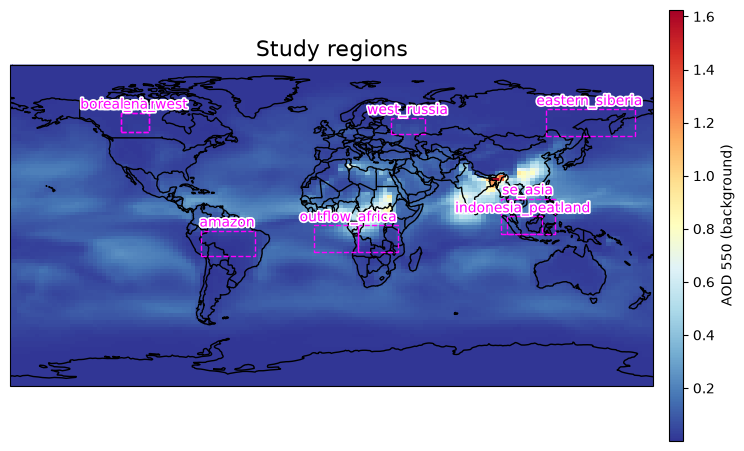

In [7]:
print('\n--- Regional map ---')
sample_field = data[sample_model]['od550aer']['od550aer'].isel(time=0)
region_boxes = {
    name: (cfg['lon_range'][0], cfg['lon_range'][1], cfg['lat_range'][0], cfg['lat_range'][1])
    for name, cfg in setup.REGIONS.items() if name != 'global'
}
fig = ct.fake_uba_map(
    lon=sample_field.lon.values,
    lat=sample_field.lat.values,
    c_array=sample_field.values,
    labels='AOD 550 (background)',
    title='Study regions',
    region_boxes=region_boxes,
    show_region_labels=True,
    region_edgecolor='magenta',
    region_linewidth=1.0,
    mycolor='RdYlBu_r',
    cbar_orientation='vertical',
    cbar_extend='neither',
    show=False,
)
if SAVE_FIGURE:
    save_path = FIGURE_DIR / 'study_regions_map.png'
    fig.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f'Saved regional map: {save_path}')
    plt.close(fig)


**Figure caption — Regional map of study areas**

Map of the AeroCom Phase III analysis domains used throughout this notebook, overlaid on a sample model `od550aer` field (first available monthly timestep from the template model grid).

**Regions and aggregation windows (2010 fire seasons):**
| Region | Surface | Lon (0–360°) | Lat | Months | Edge-weighted |
|--------|---------|--------------|-----|--------|---------------|
| `africa` | land | 15–37 | −15–0 | Jun–Sep | No |
| `amazon` | land | 287–317 | −17–−3 | Jul–Oct | No |
| `outflow_af` | ocean | 350–8 (wrap) | −15–3 | Jun–Sep | Yes |
| `boreal_na_west` | land | 242–258 | 52–63 | Jun–Aug | No |
| `indonesia_peatland` | land | 98–118 | −5–5 | Aug–mid-Nov | No |

**Data / methods:** Masks are built with `cameo_toolbox.create_region_mask` on the model lat–lon grid (land/ocean filtering via the project land-fraction file where required). Source regions (`SOURCE_REGIONS`) drive Fig. 3-style decomposition; `outflow_af` is the SE Atlantic outflow target for the meta-model only. Spatial means later use area weights ∝ cos(latitude); `edge_weighted=True` for outflow applies fractional weights on boundary cells.


## Load POLDER observations


In [8]:
polder_path = project_root / 'Data' / 'AP3_POLDER_Collocated' / 'POLDER_GRASP_coloc_3h_AP3_2010_lon0_10.0_lat0_10.0.parquet'
print(f'\nLoading POLDER observations: {polder_path}')
polder_cols = ['time', 'longitude', 'latitude', 'AOD_550', 'AAOD_550', 'AOD_440', 'AOD_870']
polder_df = pd.read_parquet(polder_path, columns=polder_cols)
polder_df['time'] = pd.to_datetime(polder_df['time'])
polder_df['month'] = polder_df['time'].dt.to_period('M')
with np.errstate(divide='ignore', invalid='ignore'):
    polder_df['SSA'] = 1.0 - polder_df['AAOD_550'] / polder_df['AOD_550']
    polder_df['AE'] = -np.log(polder_df['AOD_550'] / polder_df['AOD_870']) / np.log(550.0 / 870.0)
polder_df = polder_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['SSA', 'AE', 'AAOD_550', 'AOD_550'])
print(f'POLDER rows after filtering: {len(polder_df)}')


def polder_region_mask(df, lon_range, lat_range):
    lon_min, lon_max = lon_range
    lat_min, lat_max = lat_range
    if lon_min > lon_max:
        mask_lon = (df['longitude'] >= lon_min) | (df['longitude'] <= lon_max)
    else:
        mask_lon = (df['longitude'] >= lon_min) & (df['longitude'] <= lon_max)
    mask_lat = (df['latitude'] >= lat_min) & (df['latitude'] <= lat_max)
    return mask_lon & mask_lat


def polder_monthly_means(df, region_name):
    """Area-weighted monthly regional means from POLDER 3-hourly data."""
    cfg = setup.REGIONS[region_name]
    mask = polder_region_mask(df, cfg['lon_range'], cfg['lat_range'])
    sub = df[mask].copy()
    t0, t1 = cfg['time_slice']
    sub = sub[(sub['time'] >= t0) & (sub['time'] <= t1)]
    if sub.empty:
        return pd.DataFrame()
    sub['coslat'] = np.cos(np.deg2rad(sub['latitude']))
    rows = []
    for month, g in sub.groupby('month'):
        if len(g) < 3:
            continue
        w = g['coslat']
        rows.append({
            'month': month,
            'time': pd.Timestamp(month.start_time),
            'SSA': np.average(g['SSA'], weights=w),
            'AE': np.average(g['AE'], weights=w),
            'AAOD_550': np.average(g['AAOD_550'], weights=w),
            'AOD_550': np.average(g['AOD_550'], weights=w),
            'n': len(g),
        })
    return pd.DataFrame(rows)


polder_monthly = {region: polder_monthly_means(polder_df, region) for region in setup.REGIONS}
print('POLDER monthly means per region:')
for region, df in polder_monthly.items():
    print(f'  {region}: {len(df)} months')



Loading POLDER observations: /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/Data/AP3_POLDER_Collocated/POLDER_GRASP_coloc_3h_AP3_2010_lon0_10.0_lat0_10.0.parquet
POLDER rows after filtering: 1904702
POLDER monthly means per region:
  global: 12 months
  africa: 4 months
  amazon: 4 months
  outflow_af: 4 months
  se_asia: 1 months
  boreal_na: 3 months
  eastern_siberia: 1 months
  west_russia: 3 months
  boreal_na_west: 3 months
  indonesia_peatland: 4 months


## Load GPCP precipitation


In [9]:
gpcp_path = project_root / 'Data' / 'Prec' / 'GPCP_2010_0-360.nc'
print(f'\nLoading GPCP precipitation: {gpcp_path}')
gpcp = xr.open_dataset(gpcp_path)
gpcp_precip = gpcp['sat_gauge_precip']
print(f'GPCP dims: {gpcp_precip.dims}, shape: {gpcp_precip.shape}')


def gpcp_region_mean(precip_da, region_name):
    """Compute area-weighted regional mean of GPCP precipitation."""
    cfg = setup.REGIONS[region_name]
    lon_min, lon_max = cfg['lon_range']
    lat_min, lat_max = cfg['lat_range']
    # Select lat/lon (handle wrap-around)
    if lon_min > lon_max:
        sub = xr.concat([
            precip_da.sel(lon=slice(lon_min, 360)),
            precip_da.sel(lon=slice(0, lon_max)),
        ], dim='lon')
    else:
        sub = precip_da.sel(lon=slice(lon_min, lon_max))
    sub = sub.sel(lat=slice(lat_max, lat_min))  # GPCP lat decreasing
    # Time slice
    sub = sub.sel(time=slice(*cfg['time_slice']))
    # 2D area weights proportional to cos(latitude) on a regular lat/lon grid
    coslat = np.cos(np.deg2rad(sub.lat))
    weights = coslat * xr.ones_like(sub.isel(time=0))
    weights = weights / weights.sum()
    # Weighted spatial mean at each time step
    spatial_mean = (sub * weights).sum(dim=['lat', 'lon'])
    return spatial_mean


gpcp_region = {region: gpcp_region_mean(gpcp_precip, region) for region in setup.REGIONS}
print('GPCP regional mean precipitation (mm/day):')
for region, da in gpcp_region.items():
    mean_val = float(da.mean().values) if da.size else np.nan
    print(f'  {region}: {mean_val:.3f}')



Loading GPCP precipitation: /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/Data/Prec/GPCP_2010_0-360.nc
GPCP dims: ('time', 'lat', 'lon'), shape: (12, 360, 720)
GPCP regional mean precipitation (mm/day):
  global: 3.075
  africa: 1.105
  amazon: 1.896
  outflow_af: 0.294
  se_asia: 5.122
  boreal_na: 2.170
  eastern_siberia: 2.631
  west_russia: 1.783
  boreal_na_west: 2.409
  indonesia_peatland: 10.694


## POLDER-GRASP homogenization (Zhong et al. 2023)


In [10]:
def sample_model_aaod_at_polder(model_da, polder_sub):
    """Sample model monthly AAOD at POLDER locations/times; return weighted mean."""
    if model_da is None or polder_sub.empty:
        return np.nan
    lat_vals = model_da.lat.values
    lon_vals = model_da.lon.values
    lat_idx = np.abs(lat_vals[:, None] - polder_sub['latitude'].values[None, :]).argmin(axis=0)
    lon_idx = np.abs(lon_vals[:, None] - polder_sub['longitude'].values[None, :]).argmin(axis=0)
    times = pd.to_datetime(model_da.time.values)
    polder_times = pd.to_datetime(polder_sub['time'].values)
    month_idx = np.array([
        np.argmin(np.abs(times - pd.Timestamp(t).to_period('M').to_timestamp()))
        for t in polder_times
    ])
    vals = model_da.values[month_idx, lat_idx, lon_idx]
    weights = np.cos(np.deg2rad(polder_sub['latitude'].values))
    finite = np.isfinite(vals)
    if finite.sum() < 3:
        return np.nan
    return float(np.average(vals[finite], weights=weights[finite]))


def sample_model_ssa_at_polder(model_da, polder_sub):
    """Sample model monthly SSA at POLDER locations/times; return weighted mean.

    Same sampling scheme as ``sample_model_aaod_at_polder`` (item 2: SSA
    homogenization, mirroring the AAOD homogenization).
    """
    if model_da is None or polder_sub.empty:
        return np.nan
    lat_vals = model_da.lat.values
    lon_vals = model_da.lon.values
    lat_idx = np.abs(lat_vals[:, None] - polder_sub['latitude'].values[None, :]).argmin(axis=0)
    lon_idx = np.abs(lon_vals[:, None] - polder_sub['longitude'].values[None, :]).argmin(axis=0)
    times = pd.to_datetime(model_da.time.values)
    polder_times = pd.to_datetime(polder_sub['time'].values)
    month_idx = np.array([
        np.argmin(np.abs(times - pd.Timestamp(t).to_period('M').to_timestamp()))
        for t in polder_times
    ])
    vals = model_da.values[month_idx, lat_idx, lon_idx]
    weights = np.cos(np.deg2rad(polder_sub['latitude'].values))
    finite = np.isfinite(vals)
    if finite.sum() < 3:
        return np.nan
    return float(np.average(vals[finite], weights=weights[finite]))


def _homogenize_polder_variable(model_seasonal_dict, polder_raw, obs_col, model_var_key,
                                 sampler_fn, var_label):
    """Homogenize a regional POLDER-observed mean via model regional-vs-sampled regression.

    Generalizes the original AAOD-only homogenization (Zhong et al. 2023) so it
    can be reused for SSA (item 2). For each source region, fit::

        sampled = a * regional + b

    across models (``regional`` = model's regional/seasonal mean; ``sampled`` =
    model sampled at POLDER pixel locations/times), then invert with the raw
    POLDER-sampled mean to obtain the homogenized regional observation.

    Returns
    -------
    homogenized : dict[region] -> float
        Homogenized (or, for the outflow / skipped regions, raw sampled)
        regional observational estimate.
    details : dict[region] -> dict
        Regression detail needed for the Fig. S17-style diagnostic plot:
        ``x`` (regional model values), ``y`` (POLDER-sampled model values),
        ``models``, ``a``, ``b``, ``r2``, ``obs_sampled`` (raw POLDER mean),
        ``homogenized`` (predicted regional value), or ``{'skipped': True}``.
    """
    homogenized = {}
    details = {}
    print(f'\n--- POLDER-GRASP homogenization ({var_label}) ---')
    for region in SOURCE_REGIONS + [OUTFLOW_REGION]:
        cfg = setup.REGIONS[region]
        sub = polder_raw[polder_region_mask(polder_raw, cfg['lon_range'], cfg['lat_range'])].copy()
        t0, t1 = cfg['time_slice']
        sub = sub[(sub['time'] >= t0) & (sub['time'] <= t1)]
        if sub.empty:
            print(f'  {region}: no POLDER samples')
            details[region] = {'skipped': True}
            continue
        obs_sampled = float(np.average(sub[obs_col], weights=np.cos(np.deg2rad(sub['latitude']))))

        if region == OUTFLOW_REGION:
            # Homogenization is defined for source regions; keep sampled mean for outflow.
            homogenized[region] = obs_sampled
            details[region] = {'skipped': True, 'obs_sampled': obs_sampled}
            print(f'  {region}: using raw sampled {var_label}={obs_sampled:.5f} (no homogenization)')
            continue

        regional = model_seasonal_dict[region].get(model_var_key, {})
        sampled = {}
        for model in regional:
            da = data_derived[model].get(model_var_key)
            s = sampler_fn(da, sub)
            if np.isfinite(s) and np.isfinite(float(regional[model])):
                sampled[model] = s
        common = [m for m in regional if m in sampled]
        if len(common) < 3:
            print(f'  {region}: homogenization skipped (only {len(common)} models); '
                  f'falling back to raw sampled {var_label}={obs_sampled:.5f}')
            homogenized[region] = obs_sampled
            details[region] = {'skipped': True, 'obs_sampled': obs_sampled}
            continue

        x = np.array([float(regional[m]) for m in common])  # regional (model seasonal mean)
        y = np.array([sampled[m] for m in common])          # POLDER-sampled model value
        X = np.column_stack([x, np.ones(len(x))])
        coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        a, b = float(coeffs[0]), float(coeffs[1])
        y_pred = a * x + b
        r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2)
        # Invert: regional_obs = (sampled_obs - b) / a
        homogenized_regional = (obs_sampled - b) / a if a != 0 else np.nan
        homogenized[region] = homogenized_regional
        details[region] = {
            'skipped': False, 'models': common, 'x': x, 'y': y,
            'a': a, 'b': b, 'r2': r2, 'obs_sampled': obs_sampled,
            'homogenized': homogenized_regional,
        }
        print(f'  {region}: sampled = {a:.4f}*regional + {b:.4f}  (R^2={r2:.3f}, n={len(common)})')
        print(f'    raw sampled {var_label}={obs_sampled:.5f} -> '
              f'homogenized regional {var_label}={homogenized_regional:.5f}')
    return homogenized, details


if POLDER_HOMOGENIZE:
    aaod_obs_by_region, aaod_homog_details = _homogenize_polder_variable(
        model_seasonal, polder_df, 'AAOD_550', 'abs550aer', sample_model_aaod_at_polder, 'AAOD')
else:
    print('\n--- POLDER AAOD homogenization DISABLED; using area-weighted regional monthly means ---')
    aaod_obs_by_region = {
        region: float(polder_monthly[region]['AAOD_550'].mean())
        if not polder_monthly[region].empty else np.nan
        for region in SOURCE_REGIONS + [OUTFLOW_REGION]
    }
    aaod_homog_details = {}
    for region, val in aaod_obs_by_region.items():
        print(f'  {region}: AAOD_obs={val:.5f}')

if SSA_POLDER_HOMOGENIZE:
    ssa_obs_by_region, ssa_homog_details = _homogenize_polder_variable(
        model_seasonal, polder_df, 'SSA', 'SSA', sample_model_ssa_at_polder, 'SSA')
else:
    print('\n--- POLDER SSA homogenization DISABLED; using area-weighted regional monthly means ---')
    ssa_obs_by_region = {
        region: float(polder_monthly[region]['SSA'].mean())
        if not polder_monthly[region].empty else np.nan
        for region in SOURCE_REGIONS + [OUTFLOW_REGION]
    }
    ssa_homog_details = {}
    for region, val in ssa_obs_by_region.items():
        print(f'  {region}: SSA_obs={val:.5f}')



--- POLDER-GRASP homogenization (AAOD) ---
  africa: sampled = 1.1384*regional + -0.0016  (R^2=0.988, n=24)
    raw sampled AAOD=0.08185 -> homogenized regional AAOD=0.07330
  amazon: sampled = 1.9118*regional + -0.0058  (R^2=0.962, n=24)
    raw sampled AAOD=0.04921 -> homogenized regional AAOD=0.02875
  boreal_na_west: sampled = 1.2342*regional + 0.0001  (R^2=0.975, n=24)
    raw sampled AAOD=0.04473 -> homogenized regional AAOD=0.03614
  indonesia_peatland: sampled = 0.4587*regional + 0.0001  (R^2=0.502, n=24)
    raw sampled AAOD=0.01531 -> homogenized regional AAOD=0.03311
  outflow_af: using raw sampled AAOD=0.07639 (no homogenization)

--- POLDER-GRASP homogenization (SSA) ---
  africa: sampled = 1.1173*regional + -0.1147  (R^2=0.990, n=24)
    raw sampled SSA=0.85457 -> homogenized regional SSA=0.86754
  amazon: sampled = 1.2189*regional + -0.2197  (R^2=0.973, n=24)
    raw sampled SSA=0.90304 -> homogenized regional SSA=0.92115
  boreal_na_west: sampled = 1.0238*regional + -0

## Figure S17 style: POLDER-GRASP homogenization diagnostic (AAOD and SSA)

For each source region and variable (AAOD, SSA): one point per model showing
regional (seasonal-mean) model value (x) vs. the same model sampled at POLDER
pixel locations/times (y), the OLS fit with R^2, a horizontal dashed line at
the raw POLDER-sampled mean (y-axis quantity), and a vertical dashed line at
the resulting homogenized regional value (x-axis quantity, from inverting the
regression) -- i.e. the value that, if it were the true regional model mean,
would reproduce the observed POLDER-sampled mean.


--- Figure S17 style: POLDER-GRASP homogenization regression ---


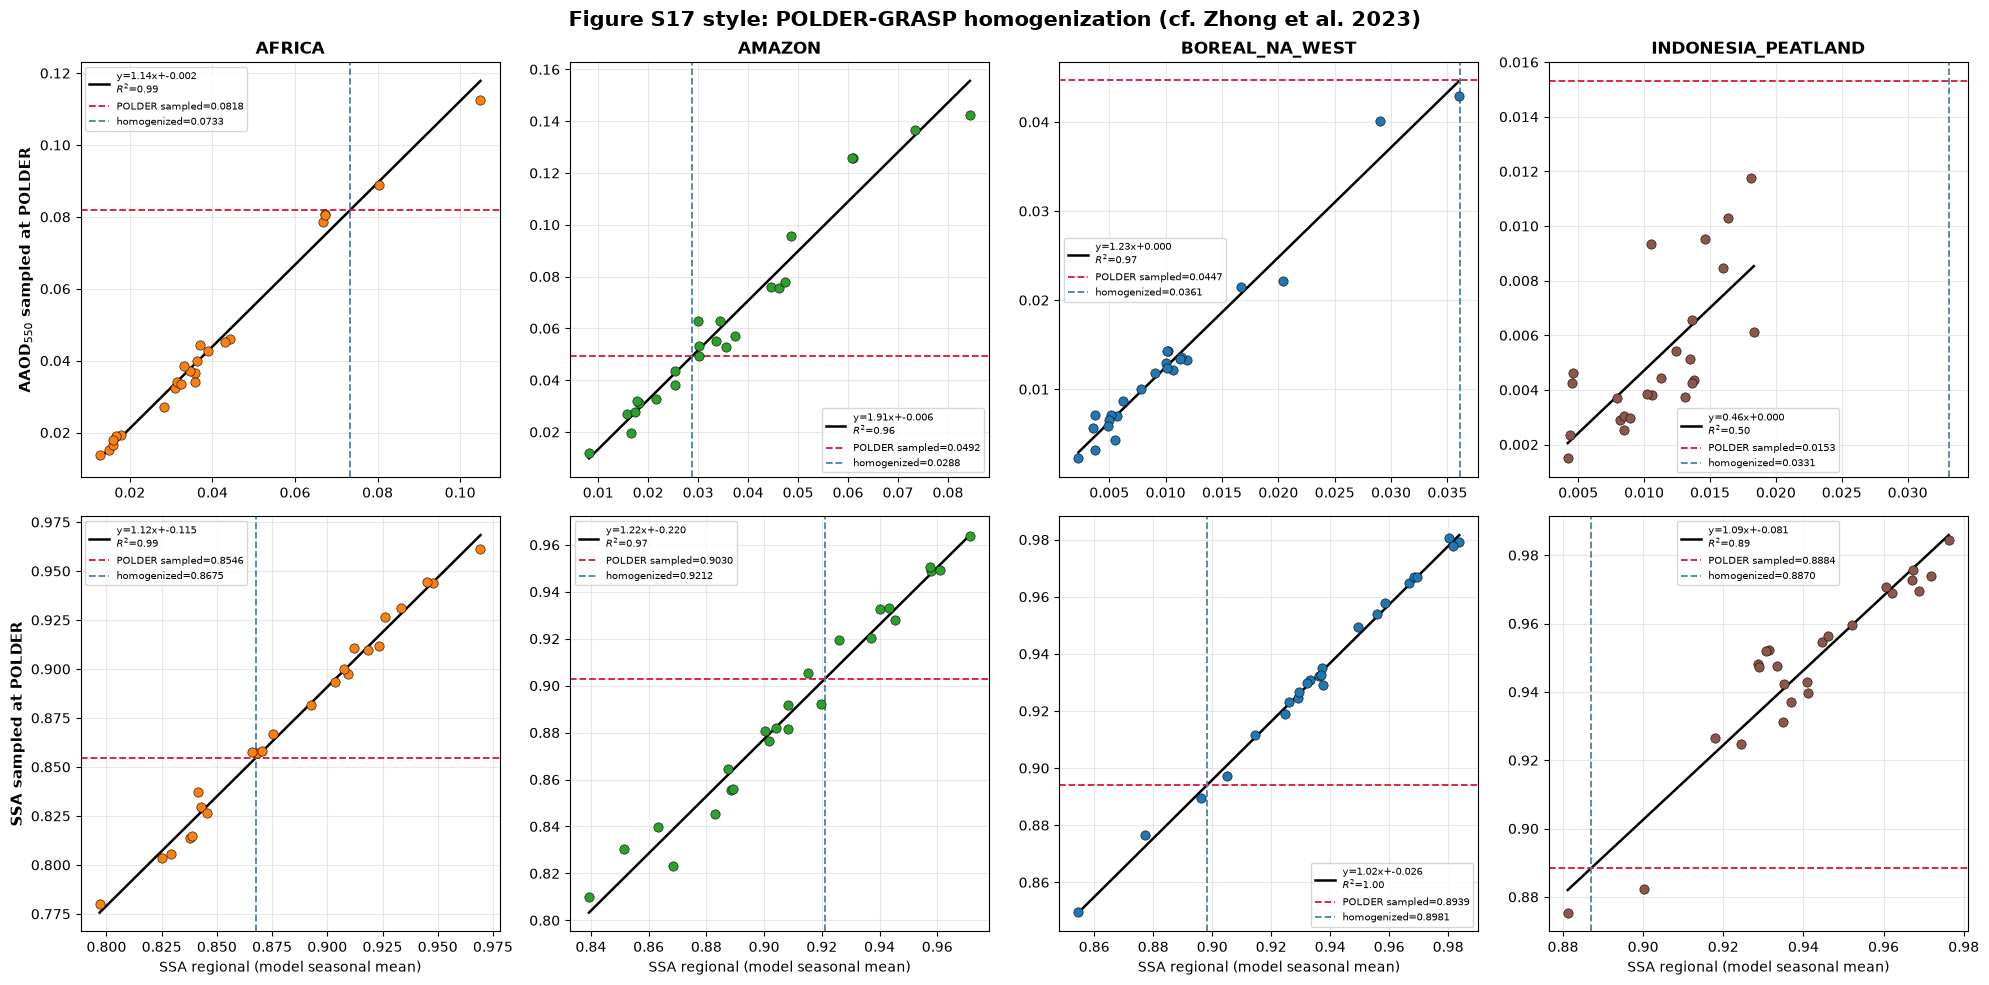

In [11]:
print('\n--- Figure S17 style: POLDER-GRASP homogenization regression ---')
_s17_panels = [
    ('AAOD', aaod_homog_details, 'AAOD$_{550}$ sampled at POLDER'),
    ('SSA', ssa_homog_details, 'SSA sampled at POLDER'),
]
_s17_any = any(not d.get('skipped', True) for _, det, _ in _s17_panels for d in det.values())
if _s17_any:
    fig, axes = plt.subplots(2, len(SOURCE_REGIONS), figsize=(5 * len(SOURCE_REGIONS), 10), squeeze=False)
    for row, (var_name, details, ylabel) in enumerate(_s17_panels):
        for col, region in enumerate(SOURCE_REGIONS):
            ax = axes[row, col]
            d = details.get(region, {})
            if d.get('skipped', True):
                ax.text(0.5, 0.5, 'no homogenization\n(insufficient data)',
                        ha='center', va='center', transform=ax.transAxes, fontsize=10, color='gray')
                ax.set_xticks([]); ax.set_yticks([])
                if col == 0:
                    ax.set_ylabel(ylabel, fontweight='bold')
                if row == 0:
                    ax.set_title(region.upper(), fontweight='bold')
                continue
            x, y = d['x'], d['y']
            a, b, r2 = d['a'], d['b'], d['r2']
            color = REGION_COLORS.get(region, 'tab:blue')
            ax.scatter(x, y, s=45, color=color, edgecolors='black', linewidths=0.4, zorder=4)
            x_line = np.linspace(x.min(), x.max(), 50)
            ax.plot(x_line, a * x_line + b, '-', color='black', linewidth=1.8,
                    label=f'y={a:.2f}x+{b:.3f}\n$R^2$={r2:.2f}')
            ax.axhline(d['obs_sampled'], color='crimson', linestyle='--', linewidth=1.3,
                       label=f'POLDER sampled={d["obs_sampled"]:.4f}')
            ax.axvline(d['homogenized'], color='steelblue', linestyle='--', linewidth=1.3,
                       label=f'homogenized={d["homogenized"]:.4f}')
            ax.legend(fontsize=7, loc='best')
            ax.grid(alpha=0.3)
            if col == 0:
                ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
            if row == len(_s17_panels) - 1:
                ax.set_xlabel(f'{var_name} regional (model seasonal mean)', fontsize=10)
            if row == 0:
                ax.set_title(region.upper(), fontweight='bold')
    plt.suptitle('Figure S17 style: POLDER-GRASP homogenization (cf. Zhong et al. 2023)',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    fig_path = FIGURE_DIR / 'figure_s17_homogenization.png'
    if SAVE_FIGURE:
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f'Saved: {fig_path}')
        plt.close(fig)
else:
    print('  Skipped: no region had a valid AAOD or SSA homogenization regression '
          '(POLDER_HOMOGENIZE / SSA_POLDER_HOMOGENIZE disabled or insufficient data).')


**Figure caption — POLDER–GRASP homogenization diagnostic (Fig. S17 style)**

Two-row panel (AAOD top, SSA bottom): one subplot per source region. Each point is one AeroCom model.

**What is plotted:**
- **x-axis:** model seasonal-mean **regional** value of AAOD₅₅₀ or SSA over the full region mask (area-weighted monthly → seasonal mean).
- **y-axis:** the same model **sampled at POLDER–GRASP clear-sky 3-hourly observation locations/times** within the region and season (collocated sampling), then seasonally averaged with cos(lat) weights.
- Solid line: OLS fit `sampled = a · regional + b`. Dashed vertical line: homogenized observation = `(POLDER_sampled − b) / a`.

**Data used:** POLDER–GRASP collocated parquet (`AAOD_550`, `AOD_550` → SSA = 1 − AAOD/AOD) for 2010; AeroCom monthly `abs550aer` / SSA derived fields after time normalization and (where needed) grid alignment. Homogenization is applied only to **source** regions when `POLDER_HOMOGENIZE` / `SSA_POLDER_HOMOGENIZE` are True; `outflow_af` keeps the raw sampled mean (SM Method 1 is source-oriented).

**Purpose:** Correct sparse satellite sampling bias so regional `AAOD_obs` / `SSA_obs` used for constrained `E_C`, `MAC_C` represent true regional means (Zhong et al. 2023 Fig. S17).


## Model regressions (source regions)
Constrained estimates from seasonal-mean observations

In [12]:
print('\n--- Model regressions ---')
if MAC_X_COL not in ('SSA', '1-SSA'):
    raise ValueError(f"MAC_X_COL must be 'SSA' or '1-SSA', got {MAC_X_COL!r}")
print(f'  MAC vs {MAC_X_COL}: INTERCEPT_0={INTERCEPT_0} '
      f"({'through origin' if INTERCEPT_0 else 'with intercept'})")

regression_rows = []
regression_excluded = []
for region in SOURCE_REGIONS:  # main regressions on source regions only
    for model in models:
        ssa = model_seasonal[region]['SSA'].get(model)
        mac = model_seasonal[region]['MAC'].get(model)
        ae = model_seasonal[region]['AE'].get(model)
        lt = model_seasonal[region]['lifetime_BC_OA'].get(model)
        precip = model_seasonal[region]['precip'].get(model)
        if not all(v is not None for v in [ssa, mac, ae, lt, precip]):
            continue
        if not np.isfinite(float(lt)):
            regression_excluded.append({'region': region, 'model': model, 'reason': 'non-finite lifetime'})
            continue
        ssa_f = float(ssa)
        regression_rows.append({
            'region': region, 'model': model,
            'SSA': ssa_f, '1-SSA': 1.0 - ssa_f, 'MAC': float(mac), 'AE': float(ae),
            'lifetime': float(lt), 'inv_lifetime': 1.0 / float(lt),
            'precip': float(precip),
        })
if regression_excluded:
    print(f'  Excluded {len(regression_excluded)} model/region points due to lifetime:')
    for item in regression_excluded:
        print(f'    {item["model"]} {item["region"]}')
reg_df = pd.DataFrame(regression_rows)
print(f'Regression data rows (seasonal means, source regions): {len(reg_df)}')

mac_ssa_results = {}
for region in SOURCE_REGIONS:
    sub = reg_df[reg_df['region'] == region].dropna(subset=['MAC', MAC_X_COL])
    if len(sub) < 3:
        print(f'{region}: skipped MAC vs {MAC_X_COL} (only {len(sub)} points)')
        continue
    x = sub[MAC_X_COL].values
    y = sub['MAC'].values
    x_label = MAC_X_COL
    if INTERCEPT_0:
        F = np.nansum(x * y) / np.nansum(x ** 2)
        b = 0.0
        residuals = y - F * x
        r2 = 1 - np.nansum(residuals ** 2) / np.nansum(y ** 2)
        print(f'{region}: MAC = {F:.4f} * {x_label}  (through origin; uncentered R^2={r2:.3f}, n={len(sub)})')
    else:
        X = np.column_stack([x, np.ones(len(x))])
        coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        F, b = float(coeffs[0]), float(coeffs[1])
        y_pred = F * x + b
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        print(f'{region}: MAC = {F:.4f} * {x_label} + {b:.4f}  (R^2={r2:.3f}, n={len(sub)})')
    mac_ssa_results[region] = {
        'F': F, 'A': F, 'b': b, 'r2': r2, 'n': len(sub),
        'x_col': MAC_X_COL, 'intercept_0': bool(INTERCEPT_0),
    }

inv_lt_results = {}
for region in SOURCE_REGIONS:
    sub = reg_df[reg_df['region'] == region].dropna(subset=['inv_lifetime', 'precip', 'AE'])
    if len(sub) < 4:
        print(f'{region}: skipped 1/tau regression (only {len(sub)} points)')
        continue
    X = np.column_stack([sub['precip'].values, sub['AE'].values])
    y = sub['inv_lifetime'].values
    X_ols = np.column_stack([np.ones(len(X)), X])
    coeffs, _, _, _ = np.linalg.lstsq(X_ols, y, rcond=None)
    y_pred = X_ols @ coeffs
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    inv_lt_results[region] = {
        'intercept': float(coeffs[0]), 'alpha': float(coeffs[1]), 'beta': float(coeffs[2]),
        'r2': r2, 'n': len(sub),
    }
    print(f'{region}: 1/tau = {coeffs[0]:.4f} + {coeffs[1]:.4f}*Pr + {coeffs[2]:.4f}*AE '
          f'(R^2={r2:.3f}, n={len(sub)})')



--- Model regressions ---
  MAC vs 1-SSA: INTERCEPT_0=True (through origin)
  Excluded 3 model/region points due to lifetime:
    CAM5_CTRL2016 africa
    CAM5_CTRL2016 amazon
    CAM5_CTRL2016 boreal_na_west
Regression data rows (seasonal means, source regions): 53
africa: MAC = 6.6508 * 1-SSA  (through origin; uncentered R^2=0.890, n=13)
amazon: MAC = 6.9343 * 1-SSA  (through origin; uncentered R^2=0.912, n=13)
boreal_na_west: MAC = 6.2575 * 1-SSA  (through origin; uncentered R^2=0.893, n=13)
indonesia_peatland: MAC = 31.8907 * 1-SSA  (through origin; uncentered R^2=0.633, n=14)
africa: 1/tau = 0.3591 + 0.0331*Pr + -0.0500*AE (R^2=0.415, n=13)
amazon: 1/tau = 0.2456 + 0.0812*Pr + -0.0722*AE (R^2=0.594, n=13)
boreal_na_west: 1/tau = 0.6942 + 0.0248*Pr + -0.0589*AE (R^2=0.043, n=13)
indonesia_peatland: 1/tau = 0.1730 + 0.0502*Pr + -0.0582*AE (R^2=0.267, n=14)


In [13]:
reg_df

,region,model,SSA,1-SSA,MAC,AE,lifetime,inv_lifetime,precip
0,africa,CAM5-ATRAS_AP3-CTRL,0.912008,0.087992,0.522675,1.726838,2.739871,0.364981,0.722989
1,africa,CAM5.3-Oslo_AP3-CTRL2016-PD,0.909556,0.090444,0.565712,1.895387,3.975657,0.251531,0.790573
2,africa,ECHAM6-SALSA_CTRL2016-PD,0.796894,0.203106,1.038843,1.630125,4.365820,0.229052,0.446908
3,africa,ECHAM6.3-HAM2.3-met2010_AP3-CTRL,0.845346,0.154654,1.027968,1.620796,3.518949,0.284176,0.377045
4,africa,ECHAM6.3-SALSA2.0-met2010_AP3-CTRL,0.841247,0.158753,1.372660,1.308416,3.598918,0.277861,0.122431
5,africa,ECMWF-IFS-CY42R1-CAMS-RA-CTRL_AP3-CTRL2016-PD,0.829290,0.170710,0.896768,1.502930,2.609481,0.383218,0.675212
6,africa,GEOS-i33p2-met2010_AP3-CTRL,0.923407,0.076593,0.545060,1.713145,2.917717,0.342734,1.122987
7,africa,GISS-ModelE2p1p1-OMA_AP3-CTRL,0.945316,0.054684,1.102061,0.430794,2.901443,0.344656,0.942361
8,africa,INCA_AP3-CTRL,0.933177,0.066823,0.788964,0.849160,2.762826,0.361948,1.121639
9,africa,MIROC-SPRINTARS_AP3-CTRL,0.969365,0.030635,0.429260,1.299072,2.501530,0.399755,3.349259


## Constrained estimates from observations


In [14]:
print('\n--- Constrained estimates from observations ---')
constrained = []
for region in SOURCE_REGIONS:
    polder_df_region = polder_monthly[region]
    if polder_df_region.empty:
        print(f'  {region}: skipped (no POLDER data)')
        continue
    if region not in mac_ssa_results or region not in inv_lt_results:
        print(f'  {region}: skipped (no model regression)')
        continue
    gpcp_ts = gpcp_region[region]
    mac_params = mac_ssa_results[region]
    lt_params = inv_lt_results[region]

    ssa_obs_mean = float(ssa_obs_by_region.get(region, polder_df_region['SSA'].mean()))
    ae_obs_mean = float(polder_df_region['AE'].mean())
    aaod_obs_mean = float(aaod_obs_by_region.get(region, polder_df_region['AAOD_550'].mean()))
    precip_obs_mean = float(gpcp_ts.mean().values) if gpcp_ts.size else np.nan

    x_col = mac_params.get('x_col', MAC_X_COL)
    x_obs = (1.0 - ssa_obs_mean) if x_col == '1-SSA' else ssa_obs_mean
    mac_c = mac_params['F'] * x_obs + mac_params.get('b', 0.0)
    inv_lt_c = (lt_params['intercept']
                + lt_params['alpha'] * precip_obs_mean
                + lt_params['beta'] * ae_obs_mean)
    tau_c = 1.0 / inv_lt_c if inv_lt_c > 0 else np.nan
    # E from AAOD/(tau*MAC) is in g m^-2 day^-1; convert to kg m^-2 s^-1 for comparison with model emissions
    e_c_g_m2_day = aaod_obs_mean / (tau_c * mac_c) if (tau_c > 0 and mac_c > 0) else np.nan
    e_c = e_c_g_m2_day / (1000.0 * 86400.0)

    constrained.append({
        'region': region,
        'SSA_obs': ssa_obs_mean, 'AE_obs': ae_obs_mean, 'AAOD_obs': aaod_obs_mean,
        'precip_obs': precip_obs_mean,
        'MAC_x_col': x_col, 'MAC_x_obs': x_obs,
        'MAC_c': mac_c, 'tau_c': tau_c,
        'E_c_g_m2_day': e_c_g_m2_day, 'E_c': e_c,
        'AAOD_homogenized': bool(POLDER_HOMOGENIZE),
        'MAC_intercept_used': not INTERCEPT_0,
        'SSA_homogenized': bool(SSA_POLDER_HOMOGENIZE),
    })
    print(f'  {region}: MAC_c={mac_c:.4f}, tau_c={tau_c:.2f} d, '
          f'E_c={e_c:.3e}, AAOD_obs={aaod_obs_mean:.5f} '
          f'(homogenized={POLDER_HOMOGENIZE})')

constrained_df = pd.DataFrame(constrained)
print(f'Constrained rows: {len(constrained_df)}')



--- Constrained estimates from observations ---
  africa: MAC_c=0.8810, tau_c=3.05 d, E_c=3.158e-10, AAOD_obs=0.07330 (homogenized=True)
  amazon: MAC_c=0.5467, tau_c=3.23 d, E_c=1.883e-10, AAOD_obs=0.02875 (homogenized=True)
  boreal_na_west: MAC_c=0.6375, tau_c=1.49 d, E_c=4.394e-10, AAOD_obs=0.03614 (homogenized=True)
  indonesia_peatland: MAC_c=3.6032, tau_c=1.52 d, E_c=6.996e-11, AAOD_obs=0.03311 (homogenized=True)
Constrained rows: 4


## Figure S3 replication: 1/lifetime vs precipitation (source regions)

Replicates Zhong et al. (2023) Fig. S3: for each source region, seasonal-mean 1/lifetime (post-aggregation-filtered, see `POST_AGG_LIFETIME_MAX_DAYS`/`MIN_DAYS`) is regressed against seasonal-mean precipitation only (single predictor, for visual consistency with the paper). The actual constrained lifetime used elsewhere in this notebook also includes AE (see `inv_lt_results` above).



--- Figure S3 replication: 1/lifetime vs precipitation ---


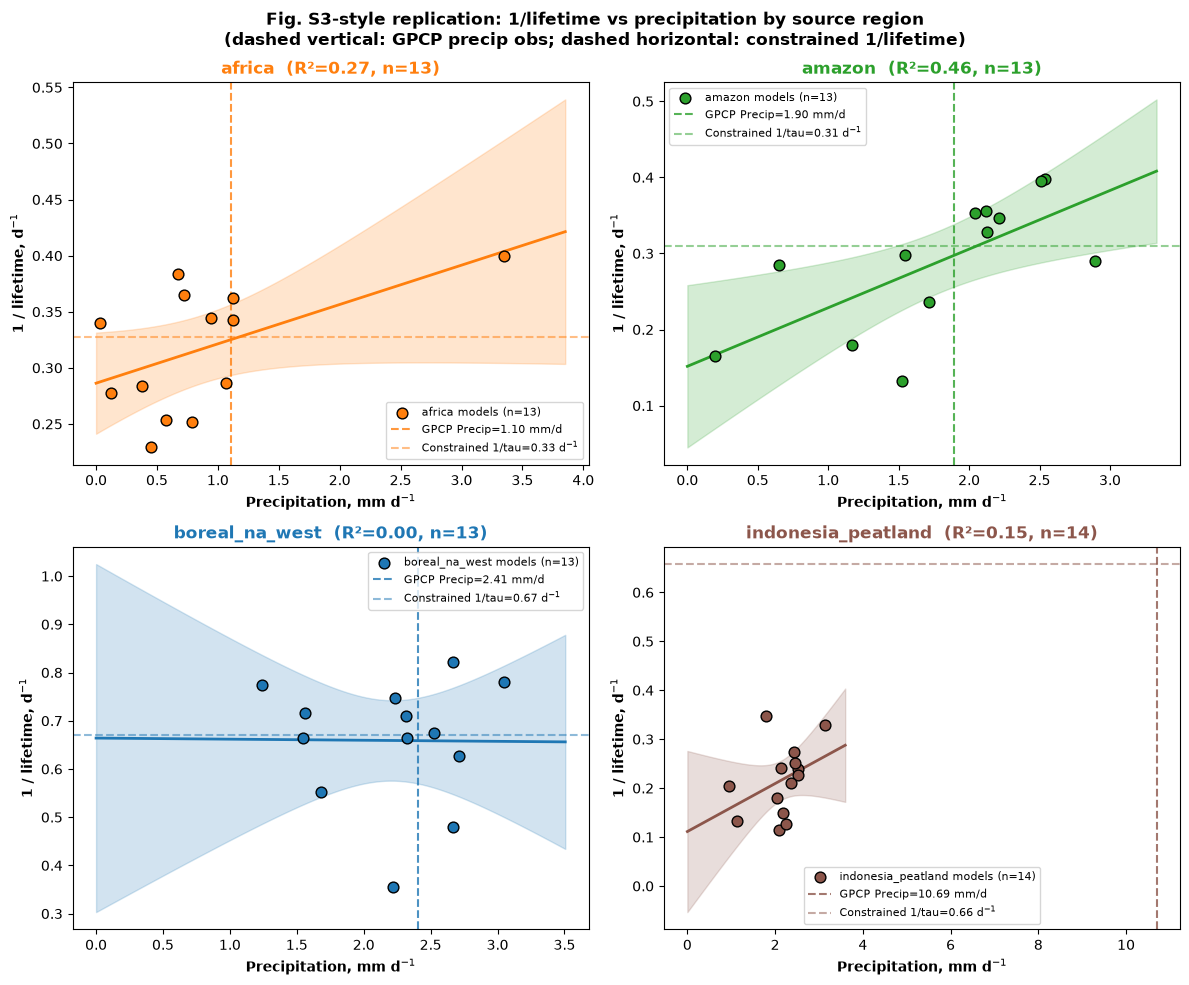

In [15]:
print('\n--- Figure S3 replication: 1/lifetime vs precipitation ---')

fig_s3_regions = SOURCE_REGIONS  # africa, amazon, west_russia, boreal_na_west
ncols = 2
nrows = int(np.ceil(len(fig_s3_regions) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows), squeeze=False)

for idx, region in enumerate(fig_s3_regions):
    ax = axes[idx // ncols][idx % ncols]
    color = REGION_COLORS.get(region, '#333333')
    sub = reg_df[reg_df['region'] == region].dropna(subset=['inv_lifetime', 'precip'])
    if len(sub) < 3:
        ax.set_title(f'{region}: insufficient data (n={len(sub)})')
        ax.axis('off')
        continue

    x = sub['precip'].values
    y = sub['inv_lifetime'].values

    # Simple OLS: 1/tau = m * Precip + b (precip-only, matches paper's Fig. S3 visualization;
    # the actual constrained regression used elsewhere also includes AE).
    X = np.column_stack([x, np.ones(len(x))])
    coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    m, b = float(coeffs[0]), float(coeffs[1])
    y_pred = m * x + b
    resid = y - y_pred
    dof = max(len(x) - 2, 1)
    mse = np.sum(resid ** 2) / dof
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - np.sum(resid ** 2) / ss_tot if ss_tot > 0 else np.nan

    x_line = np.linspace(0, max(x.max() * 1.15, 0.1), 100)
    y_line = m * x_line + b
    x_mean = x.mean()
    Sxx = np.sum((x - x_mean) ** 2)
    se_line = np.sqrt(mse * (1.0 / len(x) + (x_line - x_mean) ** 2 / max(Sxx, 1e-12)))
    tval = stats.t.ppf(0.975, dof)
    ci = tval * se_line

    ax.scatter(x, y, color=color, edgecolor='k', s=60, zorder=3, label=f'{region} models (n={len(sub)})')
    ax.plot(x_line, y_line, color=color, lw=2)
    ax.fill_between(x_line, y_line - ci, y_line + ci, color=color, alpha=0.2)

    # GPCP observed precipitation (vertical) and constrained 1/lifetime (horizontal)
    gpcp_ts = gpcp_region.get(region)
    gpcp_val = float(gpcp_ts.mean().values) if gpcp_ts is not None and gpcp_ts.size else np.nan
    csub = constrained_df[constrained_df['region'] == region]
    tau_c_mean = float(csub['tau_c'].mean()) if not csub.empty else np.nan
    inv_tau_c = 1.0 / tau_c_mean if tau_c_mean and tau_c_mean > 0 else np.nan

    if np.isfinite(gpcp_val):
        ax.axvline(gpcp_val, color=color, linestyle='--', alpha=0.8,
                    label=f'GPCP Precip={gpcp_val:.2f} mm/d')
    if np.isfinite(inv_tau_c):
        ax.axhline(inv_tau_c, color=color, linestyle='--', alpha=0.5,
                    label=f'Constrained 1/tau={inv_tau_c:.2f} d$^{{-1}}$')

    ax.set_xlabel('Precipitation, mm d$^{-1}$', fontweight='bold')
    ax.set_ylabel('1 / lifetime, d$^{-1}$', fontweight='bold')
    ax.set_title(f'{region}  (R\u00b2={r2:.2f}, n={len(sub)})', fontweight='bold', color=color)
    ax.legend(fontsize=8, loc='best')

for j in range(len(fig_s3_regions), nrows * ncols):
    axes[j // ncols][j % ncols].axis('off')

fig.suptitle('Fig. S3-style replication: 1/lifetime vs precipitation by source region\n'
             '(dashed vertical: GPCP precip obs; dashed horizontal: constrained 1/lifetime)',
             fontweight='bold')
plt.tight_layout()
if SAVE_FIGURE:
    fig_path = FIGURE_DIR / 'figureS3_lifetime_precip.png'
    fig.savefig(fig_path, dpi=200, bbox_inches='tight')
    print(f'Saved: {fig_path}')
plt.show()


**Figure caption — 1/lifetime vs precipitation (Fig. S3 style)**

One panel per source region. Each marker is one model’s seasonal-mean pair:

- **x:** GPCP precipitation (mm d⁻¹), area-weighted over the region and fire-season months.
- **y:** `1 / lifetime_BC_OA`, where lifetime = column burden(BC+OA) / emission(BC+OA) after regional aggregation (`DERIVED_VAR_AFTER_AGG`), with values outside `[POST_AGG_LIFETIME_MIN_DAYS, POST_AGG_LIFETIME_MAX_DAYS]` (default 0.3–15 d) set to NaN and excluded.
- Line: single-predictor OLS of `1/τ` on precipitation (visual Fig. S3 replication). Horizontal dashed line: constrained `1/τ_C` from the full precip+AE regression evaluated at observed precip/AE.

**Aggregation:** Model monthly fields → regional spatial mean (cos-lat / optional edge weights) → seasonal mean over the region `time_slice`. GPCP is aggregated with the same masks/seasons.

**Note:** The operational constrained lifetime elsewhere uses **precipitation and Ångström exponent** jointly; this figure shows precip-only for paper visual consistency.


## Source-region error decomposition (Fig. 3 style)


In [16]:
print('\n--- Error decomposition (source regions only) ---')
print(f'  Regions: {SOURCE_REGIONS}')
print(f'  Outflow ({OUTFLOW_REGION}) is handled separately via the meta-model.')

decomp_rows = []
for region in SOURCE_REGIONS:
    csub = constrained_df[constrained_df['region'] == region]
    if csub.empty:
        print(f'  {region}: skipped (no constrained estimate)')
        continue
    mac_c = float(csub['MAC_c'].mean())
    tau_c = float(csub['tau_c'].mean())
    aaod_c = float(csub['AAOD_obs'].mean())
    e_c = float(csub['E_c'].mean())

    for model in sorted(models):
        mac_model = model_seasonal[region]['MAC'].get(model)
        lt_model = model_seasonal[region]['lifetime_BC_OA'].get(model)
        emi_model = model_seasonal[region].get('emi_BC_OA', {}).get(model)
        aaod_model = None
        if (model_seasonal[region].get('load_BC_OA', {}).get(model) is not None
                and model_seasonal[region].get('MAC', {}).get(model) is not None):
            aaod_model = (float(model_seasonal[region]['MAC'][model])
                          * float(model_seasonal[region]['load_BC_OA'][model]) * 1000.0)

        def _isnan(v):
            if v is None:
                return True
            try:
                return not np.isfinite(float(v))
            except Exception:
                return True

        # If post-agg lifetime was filtered as unphysical (e.g. CAM5_CTRL2016 ~60-235 d),
        # still include the model in the error decomposition: use constrained tau so
        # dtau=0 and put the residual into the cross term. Do NOT feed raw lifetime
        # into dAAOD_tau (that would dominate with a bogus box-budget lifetime).
        lifetime_filtered = False
        raw_lt = None
        if _isnan(lt_model):
            raw_map = globals().get('lifetime_BC_OA_raw') or {}
            raw_lt = (raw_map.get(region) or {}).get(model)
            # Fallback: recompute box-budget lifetime from aggregated load/emi
            if raw_lt is None or not np.isfinite(float(raw_lt)):
                _load = model_seasonal[region].get('load_BC_OA', {}).get(model)
                if _load is not None and emi_model is not None:
                    try:
                        _emi = float(emi_model)
                        if _emi > 0:
                            raw_lt = float(_load) / (_emi * 86400.0)
                    except Exception:
                        raw_lt = None
            if raw_lt is not None and np.isfinite(float(raw_lt)) and not _isnan(tau_c):
                lt_model = float(tau_c)
                lifetime_filtered = True
            elif not _isnan(tau_c) and not _isnan(mac_model) and not _isnan(emi_model):
                # Even without a recoverable raw lifetime, keep the model using tau_c
                # so MAC/E error components are still shown (tau contribution = 0).
                lt_model = float(tau_c)
                lifetime_filtered = True

        # For lifetime-filtered models, prefer column abs550aer for total AAOD error
        # (MAC*load still used for models with physical lifetimes).
        if lifetime_filtered:
            abs550 = model_seasonal[region].get('abs550aer', {}).get(model)
            if abs550 is not None and np.isfinite(float(abs550)):
                aaod_model = float(abs550)

        
        if any(_isnan(v) for v in [mac_model, lt_model, emi_model, mac_c, tau_c, aaod_c, e_c]):
            
            continue

        mac_model = float(mac_model)
        lt_model = float(lt_model)
        emi_model = float(emi_model)
        emi_model_g = emi_model * 1000.0 * 86400.0
        e_c_g = e_c * 1000.0 * 86400.0
        aaod_model = float(aaod_model) if aaod_model is not None else emi_model_g * lt_model * mac_model

        dMAC = mac_model - mac_c
        dtau = lt_model - tau_c
        dE_g = emi_model_g - e_c_g
        dAAOD_E = dE_g * tau_c * mac_c
        dAAOD_tau = e_c_g * dtau * mac_c
        dAAOD_MAC = e_c_g * tau_c * dMAC
        dAAOD_total = aaod_model - aaod_c
        cross = dAAOD_total - (dAAOD_E + dAAOD_tau + dAAOD_MAC)

        denom = abs(dAAOD_E) + abs(dAAOD_tau) + abs(dAAOD_MAC) + abs(cross)
        if denom > 0:
            pct_E = abs(dAAOD_E) / denom * 100
            pct_tau = abs(dAAOD_tau) / denom * 100
            pct_MAC = abs(dAAOD_MAC) / denom * 100
            pct_cross = abs(cross) / denom * 100
        else:
            pct_E = pct_tau = pct_MAC = pct_cross = np.nan

        decomp_rows.append({
            'region': region, 'model': model,
            'MAC_model': mac_model, 'MAC_c': mac_c,
            'tau_model': lt_model, 'tau_c': tau_c,
            'E_model': emi_model, 'E_c': e_c,
            'AAOD_model': aaod_model, 'AAOD_c': aaod_c,
            'dAAOD_E': dAAOD_E, 'dAAOD_tau': dAAOD_tau,
            'dAAOD_MAC': dAAOD_MAC, 'dAAOD_cross': cross,
            'dAAOD_total': dAAOD_total,
            'pct_E': pct_E, 'pct_tau': pct_tau,
            'pct_MAC': pct_MAC, 'pct_cross': pct_cross,
            'lifetime_filtered': lifetime_filtered,
            'lifetime_raw': float(raw_lt) if raw_lt is not None and np.isfinite(float(raw_lt)) else np.nan,
        })
        

decomp_df = pd.DataFrame(decomp_rows)
print(f'Decomposition rows: {len(decomp_df)}')
_cam_n = int((decomp_df['model'] == 'CAM5_CTRL2016').sum()) if len(decomp_df) else 0
print(f'  CAM5_CTRL2016 decomp rows: {_cam_n}')
if _cam_n:
    print(decomp_df[decomp_df['model'] == 'CAM5_CTRL2016'][
        ['region', 'lifetime_filtered', 'pct_E', 'pct_tau', 'pct_MAC', 'pct_cross']
    ].to_string(index=False))
mean_decomp = decomp_df.groupby('region')[['pct_E', 'pct_tau', 'pct_MAC', 'pct_cross']].mean()
print(mean_decomp)

print('\nError decomposition vs Zhong et al. (2023) paper targets:')
for region in mean_decomp.index:
    if region not in PAPER_DECOMP:
        continue
    print(f'\n{region}:')
    for var, pap in PAPER_DECOMP[region].items():
        cur = mean_decomp.loc[region, var]
        print(f'  {var}: current={cur:.1f}%, paper≈{pap:.1f}%, diff={cur - pap:+.1f}%')



--- Error decomposition (source regions only) ---
  Regions: ['africa', 'amazon', 'boreal_na_west', 'indonesia_peatland']
  Outflow (outflow_af) is handled separately via the meta-model.
Decomposition rows: 76
  CAM5_CTRL2016 decomp rows: 4
            region  lifetime_filtered     pct_E   pct_tau   pct_MAC  pct_cross
            africa               True 46.076107  0.000000 38.052217  15.871675
            amazon               True 16.836857  0.000000 49.021623  34.141520
    boreal_na_west               True 28.676172  0.000000 37.839700  33.484127
indonesia_peatland              False  7.788409 39.458765  9.515108  43.237718
                        pct_E    pct_tau    pct_MAC  pct_cross
region                                                        
africa              39.554500  15.424588  30.708506  14.312406
amazon              23.919323  21.293990  41.089894  13.696794
boreal_na_west      45.591550  12.900128  23.425069  18.083252
indonesia_peatland  14.253167  43.227392  13.429

## Outflow meta-model prediction (Supplementary Text 2)

Zhong et al. (2022, *Nat. Commun.*) Eq. 6 for African outflow AOD:

$$
\mathrm{AOD}_o = (\alpha E_s\tau_s + \beta)\,(\gamma\,\mathrm{MEC}_s + \theta)
= A\,E_s\tau_s\mathrm{MEC}_s + B\,E_s\tau_s + C\,\mathrm{MEC}_s + D
$$

Sci. Adv. 2023 SM Text 2 / Fig. S7 replace MEC→MAC for AAOD:

$$
\mathrm{AAOD}_o = A\,E_s\tau_s\mathrm{MAC}_s + B\,E_s\tau_s + C\,\mathrm{MAC}_s + D
$$

**Predictors (African source):** emission $E_s$ (BC+OA), lifetime $\tau_s$, MAC$_s$.
**Target:** model AAOD in `outflow_af`.
**Units:** $E$ converted to g m$^{-2}$ day$^{-1}$ so $E\tau\mathrm{MAC}$ matches source AAOD scaling (same convention as the error decomposition).

**Lifetime rule:** use **physical post-aggregation box-budget** $\tau$ only (finite after `POST_AGG_LIFETIME_*`). Models with masked/NaN source $\tau$ (e.g. CAM5_CTRL2016, EC-Earth3, GFDL-AM4, TM5-met2010) are **excluded** from the outflow meta-fit — do **not** use regression $\hat{\tau}$ or unphysical 40–130 d raw lifetimes.

**Outflow region (Fig. S7 / Nature-aligned):** `lon=(350, 8)`, `lat=(-15, 3)` — same box as [`AOD_error_attribution.ipynb`](AOD_error_attribution.ipynb) and `cameo_toolbox._REGION_DEFINITIONS`. Model aggregates already used that box; the notebook `REGIONS` entry must match so **POLDER sampling** uses it too.

**POLDER vs MFC vs Zhong Fig. S7:**
- Sampled outflow AAOD with the aligned box ≈ **0.070** (was **0.076** with the old wider `(350, 15)×(-15, 0)` box) — matches the paper’s ~0.07 dashed line.
- Outflow AAOD_obs stays **raw sampled** (no homogenization; SM Method 1 is for source regions).
- MFC ≈ **0.057** still sits below POLDER because Eq. 6 coefficients are learned from models whose mean Default outflow AAOD ≈ 0.029; constrained $(E_C,\tau_C,\mathrm{MAC}_C)$ cannot fully undo that mapping. EC (≈0.061) is typically closer. See diagnostics below / `figure3_outflow_mfc_diagnostics.csv`.

**Predictions (Nature Fig. 5 style):**
- **Default** — model outflow AAOD
- **EC** — meta-model with emission scaled so source AAOD matches POLDER
- **MFC** — meta-model with constrained African $E_C,\tau_C,\mathrm{MAC}_C$


In [17]:
# ---------------------------------------------------------------------------
# African outflow meta-model (Zhong Nat. Commun. 2022 Eq. 6 → AAOD / MAC)
# Sci. Adv. 2023 Supplementary Text 2 / Fig. S7
# ---------------------------------------------------------------------------
print('\n--- Outflow meta-model (prediction target) ---')
print('  Nature Eq. 6 / Sci. Adv. SM Text 2:')
print('  AAOD_o = A*(E_s*tau_s*MAC_s) + B*(E_s*tau_s) + C*MAC_s + D')
print('  Predictors: African source E, tau, MAC; target: outflow_af AAOD')
print('  Lifetime: physical box-budget tau only (exclude models with filtered/NaN tau)')
print('  Cases: Default (model) / EC (emission-corrected) / MFC (E_C,tau_C,MAC_C)')

# # --- Previous outflow meta-model (kept for reference) ---
# print('\n--- Outflow meta-model (prediction target) ---')
# print('  AAOD_out = a*(E*tau*MAC) + b*(E*tau) + c*MAC + d   [src = africa]')
# print('  Outflow lifetime from load/emission is NOT used for the main decomposition.')
#
# meta_rows = []
# for model in models:
#     aaod_out = model_seasonal[OUTFLOW_REGION].get('abs550aer', {}).get(model)
#     e_src = model_seasonal[OUTFLOW_SOURCE].get('emi_BC_OA', {}).get(model)
#     tau_src = model_seasonal[OUTFLOW_SOURCE].get('lifetime_BC_OA', {}).get(model)
#     mac_src = model_seasonal[OUTFLOW_SOURCE].get('MAC', {}).get(model)
#     if not all(v is not None and np.isfinite(float(v)) for v in [aaod_out, e_src, tau_src, mac_src]):
#         continue
#     e_src, tau_src, mac_src = float(e_src), float(tau_src), float(mac_src)
#     meta_rows.append({
#         'model': model,
#         'AAOD_out': float(aaod_out),
#         'E': e_src, 'tau': tau_src, 'MAC': mac_src,
#         'X1': e_src * tau_src * mac_src,
#         'X2': e_src * tau_src,
#         'X3': mac_src,
#     })
# meta_df = pd.DataFrame(meta_rows)
#
# outflow_meta_params = None
# outflow_pred_df = pd.DataFrame()
# if len(meta_df) < 4:
#     print(f'  Insufficient models for outflow meta-model (n={len(meta_df)})')
# else:
#     X = meta_df[['X1', 'X2', 'X3']].values
#     y = meta_df['AAOD_out'].values
#     X_ols = np.column_stack([X, np.ones(len(X))])
#     coeffs, _, _, _ = np.linalg.lstsq(X_ols, y, rcond=None)
#     a, b, c, d = [float(v) for v in coeffs]
#     y_pred = X_ols @ coeffs
#     r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2)
#     rmse = float(np.sqrt(np.mean((y - y_pred) ** 2)))
#     nmb = float(np.sum(y_pred - y) / np.sum(y) * 100) if np.sum(y) != 0 else np.nan
#     slope, intercept, _, _, _ = stats.linregress(y, y_pred)
#     outflow_meta_params = {
#         'a': a, 'b': b, 'c': c, 'd': d,
#         'r2': r2, 'rmse': rmse, 'nmb': nmb, 'slope': slope, 'n': len(meta_df),
#     }
#     print(f'  Fit: AAOD = {a:.4e}*X1 + {b:.4e}*X2 + {c:.4e}*X3 + {d:.4e}')
#     print(f'  Diagnostics: R^2={r2:.3f}, RMSE={rmse:.5f}, NMB={nmb:.1f}%, '
#           f'slope(pred vs model)={slope:.3f}, n={len(meta_df)}')
#
#     csrc = constrained_df[constrained_df['region'] == OUTFLOW_SOURCE]
#     if not csrc.empty:
#         e_c = float(csrc['E_c'].mean())
#         tau_c = float(csrc['tau_c'].mean())
#         mac_c = float(csrc['MAC_c'].mean())
#         aaod_out_c = a * (e_c * tau_c * mac_c) + b * (e_c * tau_c) + c * mac_c + d
#         ...
# # --- End previous version ---


def _finite(v):
    if v is None:
        return False
    try:
        return np.isfinite(float(v))
    except Exception:
        return False


def _source_tau_days(model):
    """Physical box-budget source lifetime for the outflow meta-model.

    Only accept post-agg filtered load/emi lifetime (finite after
    POST_AGG_LIFETIME_*). Do not fall back to regression tau-hat or raw
    unphysical 40–130 d lifetimes — those models are excluded from the fit.
    """
    tau = model_seasonal[OUTFLOW_SOURCE].get('lifetime_BC_OA', {}).get(model)
    if _finite(tau):
        return float(tau), 'box_budget'
    return None, None


def _es_tau_mac_terms(e_kg_m2_s, tau_days, mac):
    """Build Nature Eq. 6 predictors with AAOD unit convention.

    E [kg m^-2 s^-1] -> g m^-2 day^-1; then
      X1 = (E_g * tau) * MAC ,  X2 = E_g * tau ,  X3 = MAC
    matching AAOD ≈ E_g * tau * MAC used in the source-region decomposition.
    """
    e_g = float(e_kg_m2_s) * 1000.0 * 86400.0
    e_tau = e_g * float(tau_days)
    mac = float(mac)
    return e_tau * mac, e_tau, mac


meta_rows = []
skipped_no_box_tau = []
tau_source_counts = {'box_budget': 0, 'regression': 0}
for model in models:
    aaod_out = model_seasonal[OUTFLOW_REGION].get('abs550aer', {}).get(model)
    e_src = model_seasonal[OUTFLOW_SOURCE].get('emi_BC_OA', {}).get(model)
    mac_src = model_seasonal[OUTFLOW_SOURCE].get('MAC', {}).get(model)
    tau_src, tau_origin = _source_tau_days(model)
    if not all(_finite(v) for v in [aaod_out, e_src, mac_src]):
        continue
    if tau_src is None:
        skipped_no_box_tau.append(model)
        continue
    e_src, mac_src = float(e_src), float(mac_src)
    x1, x2, x3 = _es_tau_mac_terms(e_src, tau_src, mac_src)
    tau_source_counts[tau_origin] = tau_source_counts.get(tau_origin, 0) + 1
    meta_rows.append({
        'model': model,
        'AAOD_out': float(aaod_out),
        'E': e_src, 'tau': tau_src, 'MAC': mac_src,
        'tau_origin': tau_origin,
        'E_tau_MAC': x1, 'E_tau': x2,
    })
meta_df = pd.DataFrame(meta_rows)

outflow_meta_params = None
outflow_pred_df = pd.DataFrame()
if len(meta_df) < 4:
    print(f'  Insufficient models for outflow meta-model (n={len(meta_df)})')
else:
    X = np.column_stack([
        meta_df['E_tau_MAC'].values,
        meta_df['E_tau'].values,
        meta_df['MAC'].values,
        np.ones(len(meta_df)),
    ])
    y = meta_df['AAOD_out'].values
    coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    A, B, C, D = [float(v) for v in coeffs]
    y_pred = X @ coeffs
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    rmse = float(np.sqrt(np.mean((y - y_pred) ** 2)))
    nmb = float(100.0 * np.mean(y_pred - y) / np.mean(y)) if np.mean(y) != 0 else np.nan
    slope, intercept, _, _, _ = stats.linregress(y, y_pred)
    outflow_meta_params = {
        'a': A, 'b': B, 'c': C, 'd': D,  # aliases for plot equation strings
        'A': A, 'B': B, 'C': C, 'D': D,
        'r2': r2, 'rmse': rmse, 'nmb': nmb, 'slope': slope, 'n': len(meta_df),
        'tau_box_budget_n': tau_source_counts.get('box_budget', 0),
        'tau_regression_n': tau_source_counts.get('regression', 0),
    }
    print(f'  Fit: AAOD_o = {A:.4e}*(E*tau*MAC) + {B:.4e}*(E*tau) + {C:.4e}*MAC + {D:.4e}')
    print(f'  Diagnostics: R^2={r2:.3f}, RMSE={rmse:.5f}, NMB={nmb:.1f}%, '
          f'slope(pred vs model)={slope:.3f}, n={len(meta_df)}')
    print(f'  Source tau: physical box_budget only '
          f'(n={tau_source_counts.get("box_budget", 0)})')
    if skipped_no_box_tau:
        print(f'  Excluded (no finite box-budget tau): {skipped_no_box_tau}')

    csrc = constrained_df[constrained_df['region'] == OUTFLOW_SOURCE]
    aaod_out_obs = float(aaod_obs_by_region.get(
        OUTFLOW_REGION,
        polder_monthly[OUTFLOW_REGION]['AAOD_550'].mean()
        if not polder_monthly[OUTFLOW_REGION].empty else np.nan,
    ))
    aaod_src_obs = float(aaod_obs_by_region.get(
        OUTFLOW_SOURCE,
        polder_monthly[OUTFLOW_SOURCE]['AAOD_550'].mean()
        if not polder_monthly[OUTFLOW_SOURCE].empty else np.nan,
    ))

    pred_rows = []
    aaod_mfc = np.nan
    if not csrc.empty:
        e_c = float(csrc['E_c'].mean())
        tau_c = float(csrc['tau_c'].mean())
        mac_c = float(csrc['MAC_c'].mean())
        x1_c, x2_c, x3_c = _es_tau_mac_terms(e_c, tau_c, mac_c)
        aaod_mfc = A * x1_c + B * x2_c + C * x3_c + D
        print(f'  MFC prediction AAOD_outflow_C = {aaod_mfc:.5f}')
        print(f'    using africa E_C={e_c:.3e} kg m^-2 s^-1, tau_C={tau_c:.2f} d, MAC_C={mac_c:.4f}')
    print(f'  POLDER outflow AAOD_obs = {aaod_out_obs:.5f}')

    for _, row in meta_df.iterrows():
        # EC: scale source emission so source AAOD matches POLDER (Nature Fig. 5)
        aaod_src_model = model_seasonal[OUTFLOW_SOURCE].get('abs550aer', {}).get(row['model'])
        if (aaod_src_model is not None and _finite(aaod_src_model)
                and _finite(aaod_src_obs) and float(aaod_src_model) != 0):
            e_ec = row['E'] * (aaod_src_obs / float(aaod_src_model))
        else:
            e_ec = row['E']
        x1_ec, x2_ec, x3_ec = _es_tau_mac_terms(e_ec, row['tau'], row['MAC'])
        aaod_ec = A * x1_ec + B * x2_ec + C * x3_ec + D
        aaod_meta = (A * row['E_tau_MAC'] + B * row['E_tau']
                     + C * row['MAC'] + D)
        pred_rows.append({
            'model': row['model'],
            'tau_origin': row['tau_origin'],
            'AAOD_default': row['AAOD_out'],
            'AAOD_model': row['AAOD_out'],  # alias for older plot code
            'AAOD_meta_fit': float(aaod_meta),
            'AAOD_EC': float(aaod_ec),
            'AAOD_MFC': float(aaod_mfc),
            'AAOD_constrained': float(aaod_mfc),  # alias
            'AAOD_obs': aaod_out_obs,
        })
    outflow_pred_df = pd.DataFrame(pred_rows).sort_values('model').reset_index(drop=True)
    print('\n  Outflow prediction summary (Default / EC / MFC / POLDER):')
    cols = [c for c in ['AAOD_default', 'AAOD_EC', 'AAOD_MFC', 'AAOD_obs'] if c in outflow_pred_df]
    print(outflow_pred_df[cols].describe())



--- Outflow meta-model (prediction target) ---
  Nature Eq. 6 / Sci. Adv. SM Text 2:
  AAOD_o = A*(E_s*tau_s*MAC_s) + B*(E_s*tau_s) + C*MAC_s + D
  Predictors: African source E, tau, MAC; target: outflow_af AAOD
  Lifetime: physical box-budget tau only (exclude models with filtered/NaN tau)
  Cases: Default (model) / EC (emission-corrected) / MFC (E_C,tau_C,MAC_C)
  Fit: AAOD_o = 7.8996e-01*(E*tau*MAC) + 6.5144e-02*(E*tau) + -3.2101e-03*MAC + -3.8460e-03
  Diagnostics: R^2=0.872, RMSE=0.00752, NMB=-0.0%, slope(pred vs model)=0.872, n=18
  Source tau: physical box_budget only (n=18)
  Excluded (no finite box-budget tau): ['CAM5_CTRL2016']
  MFC prediction AAOD_outflow_C = 0.05665
    using africa E_C=3.158e-10 kg m^-2 s^-1, tau_C=3.05 d, MAC_C=0.8810
  POLDER outflow AAOD_obs = 0.07639

  Outflow prediction summary (Default / EC / MFC / POLDER):
       AAOD_default    AAOD_EC   AAOD_MFC   AAOD_obs
count     18.000000  18.000000  18.000000  18.000000
mean       0.028710   0.060798   0.0

## Figure 3 style plots (source regions)

MAC–x regression uses `MAC_X_COL` (`'SSA'` or `'1-SSA'`) and `INTERCEPT_0` from cell 1.
Theory-motivated option: `MAC_X_COL='1-SSA'` with `INTERCEPT_0=True` → `MAC = A * (1-SSA)`.





--- Figure 3 plots (source regions) ---


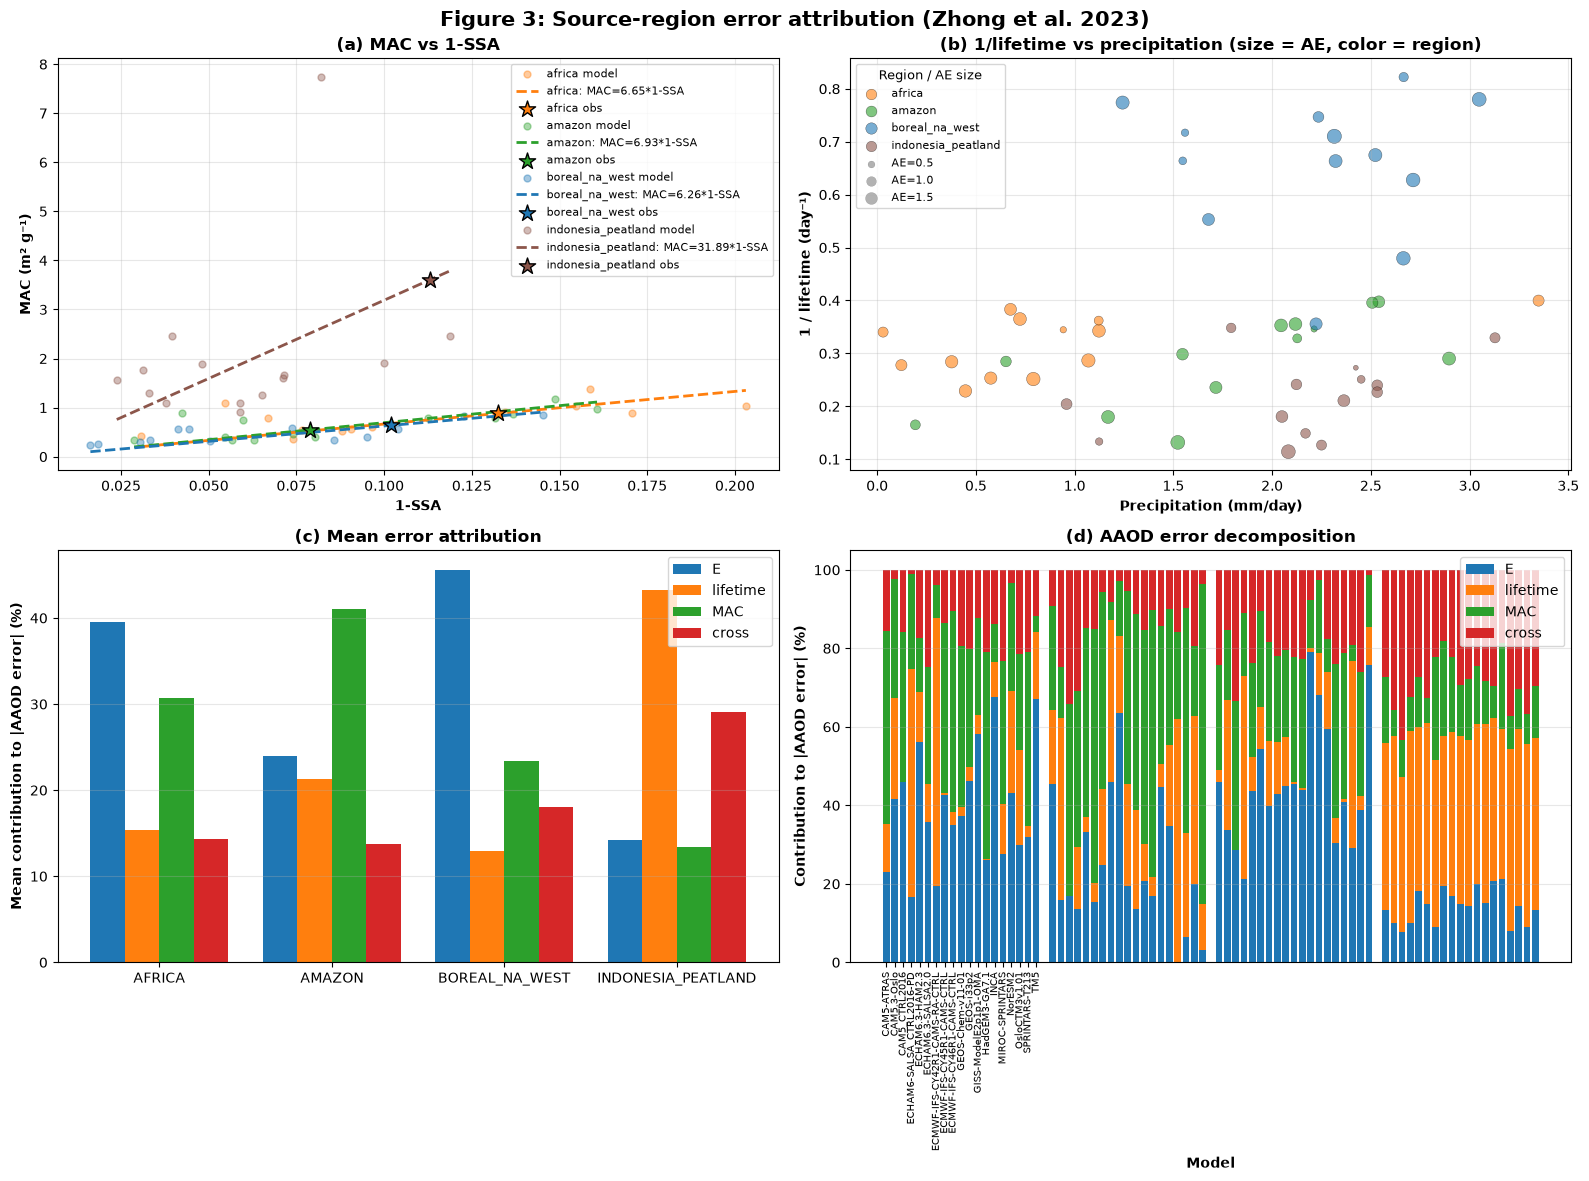

In [18]:
# change AE to size of points in scatter plots of the lifetime vs precip (Fig. S3 style) and color by region
print('\n--- Figure 3 plots (source regions) ---')
# Models are numbered in alphabetical order for the error attribution plots.
colors = REGION_COLORS  # shared per-region palette (see cell 1 config)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) MAC vs MAC_X_COL (SSA or 1-SSA)
ax = axes[0, 0]
for region in SOURCE_REGIONS:
    if region not in mac_ssa_results:
        continue
    x_col = mac_ssa_results[region].get('x_col', MAC_X_COL)
    sub = reg_df[reg_df['region'] == region].dropna(subset=['MAC', x_col])
    if sub.empty:
        continue
    ax.scatter(sub[x_col], sub['MAC'], s=25, alpha=0.4, color=colors[region], label=f'{region} model')
    F = mac_ssa_results[region]['F']
    b = mac_ssa_results[region].get('b', 0.0)
    x_line = np.linspace(sub[x_col].min(), sub[x_col].max(), 100)
    ax.plot(x_line, F * x_line + b, '--', color=colors[region], linewidth=2,
            label=f'{region}: MAC={F:.2f}*{x_col}' + (f'+{b:.2f}' if abs(b) > 1e-12 else ''))
    csub = constrained_df[constrained_df['region'] == region]
    if not csub.empty:
        x_obs = float(csub['MAC_x_obs'].mean()) if 'MAC_x_obs' in csub else float(csub['SSA_obs'].mean())
        ax.scatter(x_obs, csub['MAC_c'].mean(), s=150, marker='*',
                   color=colors[region], edgecolors='black', zorder=5, label=f'{region} obs')
ax.set_xlabel(MAC_X_COL, fontweight='bold')
ax.set_ylabel('MAC (m² g⁻¹)', fontweight='bold')
ax.set_title(f'(a) MAC vs {MAC_X_COL}', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# (b) 1/lifetime vs precip
ax = axes[0, 1]
scs = []
for region in SOURCE_REGIONS:
    sub = reg_df[reg_df['region'] == region].dropna(subset=['inv_lifetime', 'precip', 'AE'])
    if sub.empty:
        continue
    # Scale AE for marker size (e.g., s=30 × AE, or tune as desired)
    sizes = 50 * sub['AE']
    sc = ax.scatter(sub['precip'], sub['inv_lifetime'], s=sizes, alpha=0.6,
                    color=colors[region], label=region, edgecolors='black', linewidth=0.3)
    scs.append(sc)

# Add a legend to indicate the marker size (AE)
# Choose representative AE values for the legend
for legend_AE in [0.5, 1.0, 1.5]:
    ax.scatter([], [], s=50 * legend_AE, color='gray', alpha=0.6, edgecolors='black', linewidth=0.1,
               label=f'AE={legend_AE:.1f}')
# Now combine size legend with color legend; region handles from ax.collections, size handles from above
handles, labels = ax.get_legend_handles_labels()
# Remove duplicate region names, keep order
from collections import OrderedDict
reg_seen = set()
new_handles = []
new_labels = []
for h, l in zip(handles, labels):
    if l.startswith("AE="):
        new_handles.append(h)
        new_labels.append(l)
    elif l not in reg_seen:
        reg_seen.add(l)
        new_handles.append(h)
        new_labels.append(l)
ax.set_xlabel('Precipitation (mm/day)', fontweight='bold')
ax.set_ylabel('1 / lifetime (day⁻¹)', fontweight='bold')
ax.set_title('(b) 1/lifetime vs precipitation (size = AE, color = region)', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(new_handles, new_labels, fontsize=8, title="Region / AE size", title_fontsize=9)

# (c) Mean percentage contributions
ax = axes[1, 0]
plot_regions = [r for r in SOURCE_REGIONS if not decomp_df[decomp_df['region'] == r].empty]
x = np.arange(len(plot_regions))
width = 0.2
for i, (col, label, color) in enumerate([
    ('pct_E', 'E', '#1f77b4'),
    ('pct_tau', 'lifetime', '#ff7f0e'),
    ('pct_MAC', 'MAC', '#2ca02c'),
    ('pct_cross', 'cross', '#d62728'),
]):
    vals = [decomp_df[decomp_df['region'] == r][col].mean() for r in plot_regions]
    ax.bar(x + (i - 1.5) * width, vals, width, label=label, color=color)
ax.set_xticks(x)
ax.set_xticklabels([r.upper() for r in plot_regions])
ax.set_ylabel('Mean contribution to |AAOD error| (%)', fontweight='bold')
ax.set_title('(c) Mean error attribution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# (d) Per-model stacked percentages (models in alphabetical order, short names on axis)
ax = axes[1, 1]
# Use first source region that has data for shared model order / tick labels
_ref_region = next((r for r in plot_regions
                    if not decomp_df[decomp_df['region'] == r].empty), None)
_ref_models = (
    decomp_df[decomp_df['region'] == _ref_region].sort_values('model')['model'].tolist()
    if _ref_region else []
)
for idx, region in enumerate(plot_regions):
    sub = decomp_df[decomp_df['region'] == region].sort_values('model', ascending=True)
    if sub.empty:
        continue
    n = len(sub)
    xpos = np.arange(n) + idx * (n + 1)
    ax.bar(xpos, sub['pct_E'], label='E' if idx == 0 else '', color='#1f77b4')
    ax.bar(xpos, sub['pct_tau'], bottom=sub['pct_E'], label='lifetime' if idx == 0 else '', color='#ff7f0e')
    ax.bar(xpos, sub['pct_MAC'], bottom=sub['pct_E'] + sub['pct_tau'],
           label='MAC' if idx == 0 else '', color='#2ca02c')
    ax.bar(xpos, sub['pct_cross'], bottom=sub['pct_E'] + sub['pct_tau'] + sub['pct_MAC'],
           label='cross' if idx == 0 else '', color='#d62728')
ax.set_ylabel('Contribution to |AAOD error| (%)', fontweight='bold')
ax.set_xlabel('Model', fontweight='bold')
ax.set_title('(d) AAOD error decomposition', fontweight='bold')
if _ref_models:
    # Label first region's bar positions with short names
    ax.set_xticks(np.arange(len(_ref_models)))
    ax.set_xticklabels([short_model_name(m) for m in _ref_models],
                       rotation=90, fontsize=7, ha='center')
else:
    ax.set_xticks([])
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Figure 3: Source-region error attribution (Zhong et al. 2023)', fontsize=15, fontweight='bold')
plt.tight_layout()
fig_path = FIGURE_DIR / 'figure3_error_attribution.png'
if SAVE_FIGURE:
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {fig_path}')
    plt.close(fig)


# # Per-region signed error bars (Fig. 3 detail); shared alphabetical model list
# plot_regions = SOURCE_REGIONS
# fig, axes = plt.subplots(1, len(plot_regions) + 1, figsize=(7 * (len(plot_regions) + 1), 7))
# common_model_list = sorted(decomp_df['model'].unique().tolist())
# for idx, region in enumerate(plot_regions):
#     ax = axes[idx]
#     sub = decomp_df[decomp_df['region'] == region].copy()
#     if sub.empty:
#         ax.set_visible(False)
#         continue
#     # Align all regions to the same alphabetical model order
#     sub = sub.set_index('model').reindex(common_model_list).reset_index()

#     model_aod = aggregate_region(data_derived, 'abs550aer', region, return_time_series=False)
#     obs_aod_mean = float(aaod_obs_by_region.get(region, np.nan))
#     sub['AAOD_error'] = sub['model'].map(
#         lambda m: float(model_aod[m]) - obs_aod_mean if m in model_aod else np.nan
#     )
#     x = np.arange(len(sub))
#     pos_bottom = np.zeros(len(sub))
#     neg_bottom = np.zeros(len(sub))
#     pct_E_mean = sub['pct_E'].mean()
#     pct_tau_mean = sub['pct_tau'].mean()
#     pct_MAC_mean = sub['pct_MAC'].mean()
#     pct_cross_mean = sub['pct_cross'].mean()
#     components = [
#         ('dAAOD_E', f'E ({pct_E_mean:.1f}%)', '#90da4b'),
#         ('dAAOD_tau', f'tau ({pct_tau_mean:.1f}%)', '#f1abed'),
#         ('dAAOD_MAC', f'MAC ({pct_MAC_mean:.1f}%)', '#f4b238'),
#         ('dAAOD_cross', f'cross ({pct_cross_mean:.1f}%)', '#ebe27f'),
#     ]
#     for col, label, color in components:
#         vals = sub[col].to_numpy(dtype=float)
#         bottoms = np.where(vals >= 0, pos_bottom, neg_bottom)
#         ax.bar(x, vals, bottom=bottoms, color=color, width=0.8)
#         pos_bottom = np.where(vals >= 0, pos_bottom + vals, pos_bottom)
#         neg_bottom = np.where(vals < 0, neg_bottom + vals, neg_bottom)
#     ax.scatter(x, sub['AAOD_error'], color='black', s=45, zorder=5)
#     ax.axhline(0, color='black', linewidth=1)
#     ax.set_xticks(x)
#     ax.set_xticklabels([short_model_name(m) for m in sub['model']],
#                        rotation=90, fontsize=8, ha='center')
#     ax.set_ylabel('AAOD error contribution', fontsize=14, fontweight='bold')
#     ax.set_xlabel('Model ', fontsize=14, fontweight='bold')
#     ax.text(0.02, 0.98, region.upper(), transform=ax.transAxes, va='top', ha='left',
#             fontsize=18, fontweight='bold')
#     ax.legend(handles=[
#         Patch(facecolor='#90da4b', label=f'E ({pct_E_mean:.1f}%)'),
#         Patch(facecolor='#f1abed', label=f'tau ({pct_tau_mean:.1f}%)'),
#         Patch(facecolor='#f4b238', label=f'MAC ({pct_MAC_mean:.1f}%)'),
#         Patch(facecolor='#ebe27f', label=f'cross ({pct_cross_mean:.1f}%)'),
#         Line2D([0], [0], marker='o', color='black', linestyle='None', label='mean AAOD error'),
#     ], loc='upper right', fontsize=11)

# ax_legend = axes[-1]
# ax_legend.axis('off')
# legend_lines = ['SHARED MODEL LIST :']
# for i, model in enumerate(common_model_list or [], start=1):
#     legend_lines.append(f'  {i:>2d}. {short_model_name(model)}')
#     legend_lines.append(f'      ({model})')
# ax_legend.text(0.02, 0.98, '\n'.join(legend_lines), transform=ax_legend.transAxes,
#                va='top', ha='left', fontsize=9, family='monospace')
# plt.tight_layout()
# fig_path = FIGURE_DIR / 'figure3_error_attribution_by_region.png'
# if SAVE_FIGURE:
#     plt.savefig(fig_path, dpi=300, bbox_inches='tight')
#     print(f'Saved: {fig_path}')
#     plt.close(fig)


**Figure caption — Source-region error attribution (Fig. 3 style)**

Four-panel summary for `SOURCE_REGIONS` (africa, amazon, boreal_na_west, indonesia_peatland), Zhong et al. 2023 Sci. Adv. style.

**(a) MAC vs `MAC_X_COL`** (`'SSA'` or `'1-SSA'` from cell 1). Points: seasonal-mean model MAC (= AAOD / load_BC_OA) vs SSA or (1−SSA). Fit uses `INTERCEPT_0` (through-origin if True). Constrained `MAC_C` is the fit evaluated at homogenized `SSA_obs` (or 1−SSA_obs).

**(b) 1/lifetime vs precipitation**, markers sized by AE and colored by region (same post-aggregation lifetime filter as Fig. S3).

**(c) Mean absolute percentage contributions** of E, τ, MAC, and cross terms to regional AAOD error (ensemble mean of `|dAAOD_i| / Σ|dAAOD_j|`).

**(d) Per-model stacked AAOD error decomposition** vs POLDER. For each model/region:
`dAAOD = AAOD_model − AAOD_obs ≈ dE·τ_C·MAC_C + E_C·dτ·MAC_C + E_C·τ_C·dMAC + cross`,
with `E_C = AAOD_obs / (τ_C·MAC_C)` (consistent units). Models whose box-budget lifetime was NaN-filtered still appear with `lifetime_filtered=True`, using `τ_C` and `dτ = 0` (so `pct_tau ≈ 0`) while retaining E/MAC/cross.

**Data aggregation:** AeroCom Phase III monthly NetCDF → derived MAC/SSA/AE/lifetime → regional seasonal means; POLDER/GPCP seasonal means as above; models numbered alphabetically on the x-axis of (d).


## rBC vs modeled SSA (cf. Fig. S6, Zhong et al. 2023) + Brown constraint

**Modeled:** `rBC = loadbc / (loadbc + loadoa)` vs seasonal-mean SSA per model/region.

**Brown et al. (2021) in-situ line** (Fig. 1a / Sup. Table 9; overlaid as in Zhong Fig. S6):

$$\mathrm{SSA}_{550} = 0.969 - 0.779 \times \mathrm{BC{:}TC}$$

Zhong applies this to ambient `rBC ≈ BC/(BC+OA)`. Constrained estimates:

- **Constrained ambient rBC** from POLDER SSA: `rBC_C = (0.969 - SSA_obs) / 0.779`
- **Brown-predicted SSA** at the ensemble-mean modeled rBC: `SSA_C_Brown = 0.969 - 0.779 * mean(rBC_model)`

Stars on the figure mark `(rBC_C, SSA_obs)` per source region. Results are merged into `constrained_df`.



--- rBC vs modeled SSA + Brown et al. (2021) constraint ---
  rBC/SSA rows: 88 (regions: ['africa', 'amazon', 'boreal_na_west', 'indonesia_peatland'])
  Brown et al. (2021): SSA = 0.969 + (-0.779)*rBC  (r^2=0.68; Fig. 1a / Sup. Table 9)
  africa: SSA_obs=0.8675 -> rBC_C=0.1302 | rBC_model=0.0669 -> SSA_C_Brown=0.9169
  amazon: SSA_obs=0.9212 -> rBC_C=0.0614 | rBC_model=0.0525 -> SSA_C_Brown=0.9281
  boreal_na_west: SSA_obs=0.8981 -> rBC_C=0.0910 | rBC_model=0.0326 -> SSA_C_Brown=0.9436
  indonesia_peatland: SSA_obs=0.8870 -> rBC_C=0.1052 | rBC_model=0.0754 -> SSA_C_Brown=0.9103
  Merged Brown rBC/SSA constraints into constrained_df (4 rows)
  africa model fit: SSA = -1.043*rBC + 0.955  (R^2=0.225, p=0.0257, n=22)
  amazon model fit: SSA = -0.958*rBC + 0.960  (R^2=0.282, p=0.0111, n=22)
  boreal_na_west model fit: SSA = -1.592*rBC + 0.987  (R^2=0.423, p=0.00105, n=22)
  indonesia_peatland model fit: SSA = -0.297*rBC + 0.962  (R^2=0.122, p=0.112, n=22)


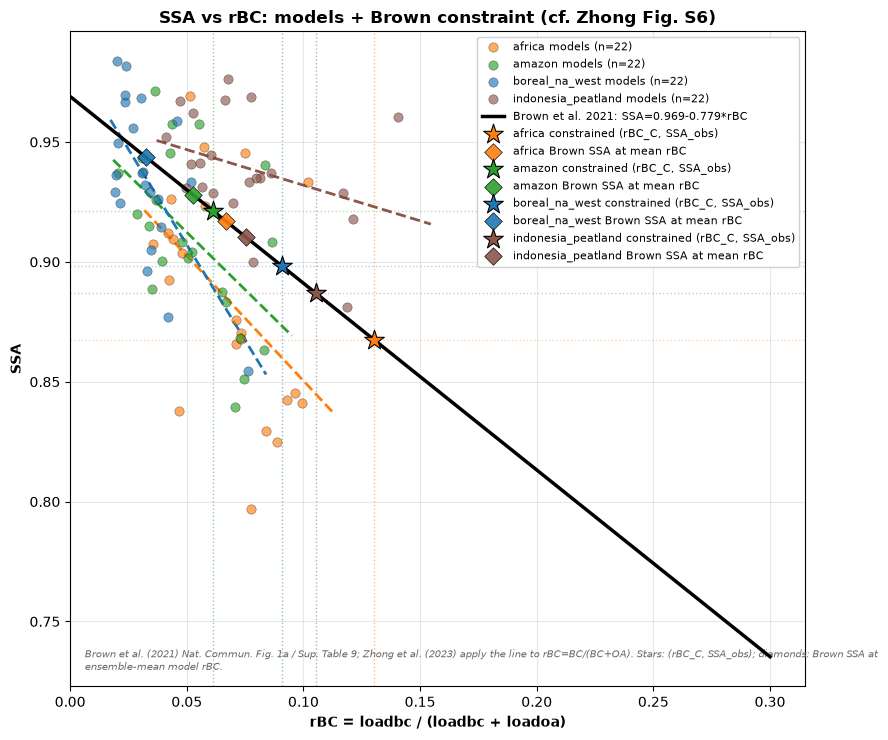

Saved: /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/tables/figure3_constrained_rbc_ssa.csv


In [24]:
print('\n--- rBC vs modeled SSA + Brown et al. (2021) constraint ---')
# loadbc/loadoa are raw NetCDF variables (VARIABLES list, cell 3) but are not
# part of `variables_pre_aggregated` (cell 7 derived-vars cell), so they were
# never aggregated into `model_seasonal`. Aggregate them here directly with
# the same `aggregate_region` helper used to build `model_seasonal` (cell 9).
loadbc_by_region = {region: setup.aggregate_region(data_derived, 'loadbc', region, masks) for region in SOURCE_REGIONS}
loadoa_by_region = {region: setup.aggregate_region(data_derived, 'loadoa', region, masks) for region in SOURCE_REGIONS}

rbc_rows = []
for region in SOURCE_REGIONS:
    loadbc = loadbc_by_region[region]
    loadoa = loadoa_by_region[region]
    ssa = model_seasonal[region].get('SSA', {})
    for model in set(loadbc) & set(loadoa) & set(ssa):
        try:
            bc = float(loadbc[model])
            oa = float(loadoa[model])
            s = float(ssa[model])
        except (TypeError, ValueError):
            continue
        if not (np.isfinite(bc) and np.isfinite(oa) and np.isfinite(s)):
            continue
        denom = bc + oa
        if denom <= 0:
            continue
        rbc_rows.append({'region': region, 'model': model, 'rBC': bc / denom, 'SSA': s})
rbc_df = pd.DataFrame(rbc_rows, columns=['region', 'model', 'rBC', 'SSA'])
print(f'  rBC/SSA rows: {len(rbc_df)} (regions: {sorted(rbc_df["region"].unique()) if not rbc_df.empty else []})')
print(f'  Brown et al. (2021): SSA = {BROWN_SSA_INTERCEPT} + ({BROWN_SSA_SLOPE})*rBC  '
      f'(r^2={BROWN_SSA_R2}; Fig. 1a / Sup. Table 9)')

# --- Constrained rBC / SSA from Brown inversion + POLDER SSA_obs ---
def brown_ssa_from_rbc(rbc):
    """Brown et al. predicted SSA_550 given rBC (≈ BC:TC in Zhong usage)."""
    return BROWN_SSA_INTERCEPT + BROWN_SSA_SLOPE * np.asarray(rbc, dtype=float)


def brown_rbc_from_ssa(ssa):
    """Invert Brown line: constrained ambient rBC from observed SSA."""
    return (BROWN_SSA_INTERCEPT - np.asarray(ssa, dtype=float)) / (-BROWN_SSA_SLOPE)


constrained_rbc_rows = []
for region in SOURCE_REGIONS:
    ssa_obs = float(ssa_obs_by_region.get(region, np.nan))
    sub = rbc_df[rbc_df['region'] == region]
    rbc_model_mean = float(sub['rBC'].mean()) if not sub.empty else np.nan
    ssa_model_mean = float(sub['SSA'].mean()) if not sub.empty else np.nan
    rbc_c = brown_rbc_from_ssa(ssa_obs) if np.isfinite(ssa_obs) else np.nan
    ssa_c_brown = brown_ssa_from_rbc(rbc_model_mean) if np.isfinite(rbc_model_mean) else np.nan
    constrained_rbc_rows.append({
        'region': region,
        'SSA_obs': ssa_obs,
        'rBC_model_mean': rbc_model_mean,
        'SSA_model_mean': ssa_model_mean,
        'rBC_C': rbc_c,                 # constrained ambient rBC from SSA_obs
        'SSA_C_Brown': ssa_c_brown,     # Brown SSA at ensemble-mean model rBC
        'delta_rBC': (rbc_c - rbc_model_mean) if np.isfinite(rbc_c) and np.isfinite(rbc_model_mean) else np.nan,
        'delta_SSA': (ssa_obs - ssa_c_brown) if np.isfinite(ssa_obs) and np.isfinite(ssa_c_brown) else np.nan,
    })
    print(f'  {region}: SSA_obs={ssa_obs:.4f} -> rBC_C={rbc_c:.4f} | '
          f'rBC_model={rbc_model_mean:.4f} -> SSA_C_Brown={ssa_c_brown:.4f}')

constrained_rbc_df = pd.DataFrame(constrained_rbc_rows)

# Merge Brown constraints into the main constrained_df (from cell 23)
if 'constrained_df' in globals() and not constrained_df.empty:
    drop_cols = [c for c in ('rBC_C', 'SSA_C_Brown', 'rBC_model_mean', 'SSA_model_mean',
                             'delta_rBC', 'delta_SSA') if c in constrained_df.columns]
    constrained_df.drop(columns=drop_cols, inplace=True, errors='ignore')
    constrained_df = constrained_df.merge(
        constrained_rbc_df[['region', 'rBC_C', 'SSA_C_Brown', 'rBC_model_mean',
                            'SSA_model_mean', 'delta_rBC', 'delta_SSA']],
        on='region', how='left',
    )
    print(f'  Merged Brown rBC/SSA constraints into constrained_df ({len(constrained_df)} rows)')
else:
    print('  Warning: constrained_df not available; Brown constraints kept in constrained_rbc_df only')

# --- Figure (Zhong Fig. S6 style) ---
fig, ax = plt.subplots(figsize=(9, 7.5))
rbc_ssa_results = {}
for region in SOURCE_REGIONS:
    sub = rbc_df[rbc_df['region'] == region]
    if sub.empty:
        continue
    color = REGION_COLORS.get(region, 'tab:blue')
    ax.scatter(sub['rBC'], sub['SSA'], s=45, alpha=0.65, color=color, edgecolors='black',
               linewidths=0.3, label=f'{region} models (n={len(sub)})', zorder=3)
    if len(sub) >= 3:
        slope, intercept, r, p, se = linregress(sub['rBC'], sub['SSA'])
        rbc_ssa_results[region] = {'slope': slope, 'intercept': intercept, 'r2': r ** 2, 'p': p, 'n': len(sub)}
        x_line = np.linspace(max(0.0, sub['rBC'].min() * 0.9), min(0.35, sub['rBC'].max() * 1.1), 50)
        ax.plot(x_line, slope * x_line + intercept, '--', color=color, linewidth=2, zorder=2)
        print(f'  {region} model fit: SSA = {slope:.3f}*rBC + {intercept:.3f}  '
              f'(R^2={r ** 2:.3f}, p={p:.3g}, n={len(sub)})')
    else:
        print(f'  {region}: too few points ({len(sub)}) for regression')

# Brown observational reference line
x_brown = np.linspace(0.0, 0.30, 100)
ax.plot(x_brown, brown_ssa_from_rbc(x_brown), 'k-', linewidth=2.5, zorder=4,
        label=f'Brown et al. 2021: SSA={BROWN_SSA_INTERCEPT}{BROWN_SSA_SLOPE:+.3f}*rBC')

# Constrained (rBC_C, SSA_obs) stars + Brown SSA at model-mean rBC
for _, row in constrained_rbc_df.iterrows():
    region = row['region']
    color = REGION_COLORS.get(region, 'tab:blue')
    if np.isfinite(row['rBC_C']) and np.isfinite(row['SSA_obs']):
        ax.scatter([row['rBC_C']], [row['SSA_obs']], s=220, marker='*', color=color,
                   edgecolors='black', linewidths=0.8, zorder=6,
                   label=f'{region} constrained (rBC_C, SSA_obs)')
        ax.axvline(row['rBC_C'], color=color, linestyle=':', linewidth=1.0, alpha=0.5, zorder=1)
        ax.axhline(row['SSA_obs'], color=color, linestyle=':', linewidth=1.0, alpha=0.35, zorder=1)
    if np.isfinite(row['rBC_model_mean']) and np.isfinite(row['SSA_C_Brown']):
        ax.scatter([row['rBC_model_mean']], [row['SSA_C_Brown']], s=80, marker='D',
                   color=color, edgecolors='black', linewidths=0.5, zorder=5, alpha=0.9,
                   label=f'{region} Brown SSA at mean rBC')

ax.set_xlabel('rBC = loadbc / (loadbc + loadoa)', fontweight='bold')
ax.set_ylabel('SSA', fontweight='bold')
ax.set_title('SSA vs rBC: models + Brown constraint (cf. Zhong Fig. S6)', fontweight='bold')
ax.set_xlim(left=0)
ax.grid(alpha=0.3)
# Deduplicate legend labels
handles, labels = ax.get_legend_handles_labels()
seen = set()
uniq = []
for h, lab in zip(handles, labels):
    if lab not in seen:
        seen.add(lab)
        uniq.append((h, lab))
ax.legend(*zip(*uniq), fontsize=8, loc='best', framealpha=0.92)
ax.text(
    0.02, 0.02,
    'Brown et al. (2021) Nat. Commun. Fig. 1a / Sup. Table 9; '
    'Zhong et al. (2023) apply the line to rBC=BC/(BC+OA). '
    'Stars: (rBC_C, SSA_obs); diamonds: Brown SSA at ensemble-mean model rBC.',
    transform=ax.transAxes, fontsize=7.5, va='bottom', ha='left',
    style='italic', color='dimgray', wrap=True,
)
plt.tight_layout()
fig_path = FIGURE_DIR / 'rbc_vs_ssa.png'
if SAVE_FIGURE:
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {fig_path}')
    plt.close(fig)
else:
    plt.show()

# Persist constrained rBC/SSA table
rbc_csv = TABLE_DIR / 'figure3_constrained_rbc_ssa.csv'
constrained_rbc_df.to_csv(rbc_csv, index=False)
print(f'Saved: {rbc_csv}')


**Figure caption — Modeled SSA vs rBC with Brown et al. (2021) constraint (cf. Fig. S6)**

Scatter of seasonal-mean **SSA** vs **rBC = loadbc / (loadbc + loadoa)** for each model and source region (colors by region). Solid/colored lines: per-region OLS of SSA on rBC from AeroCom. Thick reference line: Brown et al. (2021) *in situ* relation  
`SSA = 0.969 − 0.779 · rBC`.

**Horizontal dashed lines:** homogenized (or raw) regional `SSA_obs`. **Vertical markers / derived `rBC_C`:** invert the Brown line at `SSA_obs` to obtain a constrained ambient rBC used downstream in `constrained_df`.

**Aggregation:** `loadbc` and `loadoa` are aggregated here with the same regional masks and seasonal `time_slice` as other variables (they are not in the pre-aggregation derived list). SSA is the seasonal regional mean from model_seasonal.


## Figure 2 style: modeled MAC vs SSA or (1−SSA)

Uses `MAC_X_COL` / `INTERCEPT_0` from cell 1 (same regression as Fig. 3 panel a). Set `MAC_X_COL='1-SSA'` and `INTERCEPT_0=True` for the theory-motivated through-origin fit `MAC = A*(1−SSA)`.

Reusable `plot_mac_vs_ssa(plot_regions, ...)`: one panel per region, model
scatter + OLS fit (from `mac_ssa_results`), a vertical dashed line at the
regional (homogenized) SSA_obs, a horizontal dashed line at the constrained
MAC_c, and their intersection (star marker). Called once with the paper's
two regions (`amazon`, `africa`) and once with all `SOURCE_REGIONS`.


--- Fig. 2 style MAC vs 1-SSA: paper regions (amazon, africa) ---

--- Fig. 2 style MAC vs 1-SSA: all source regions (extended) ---


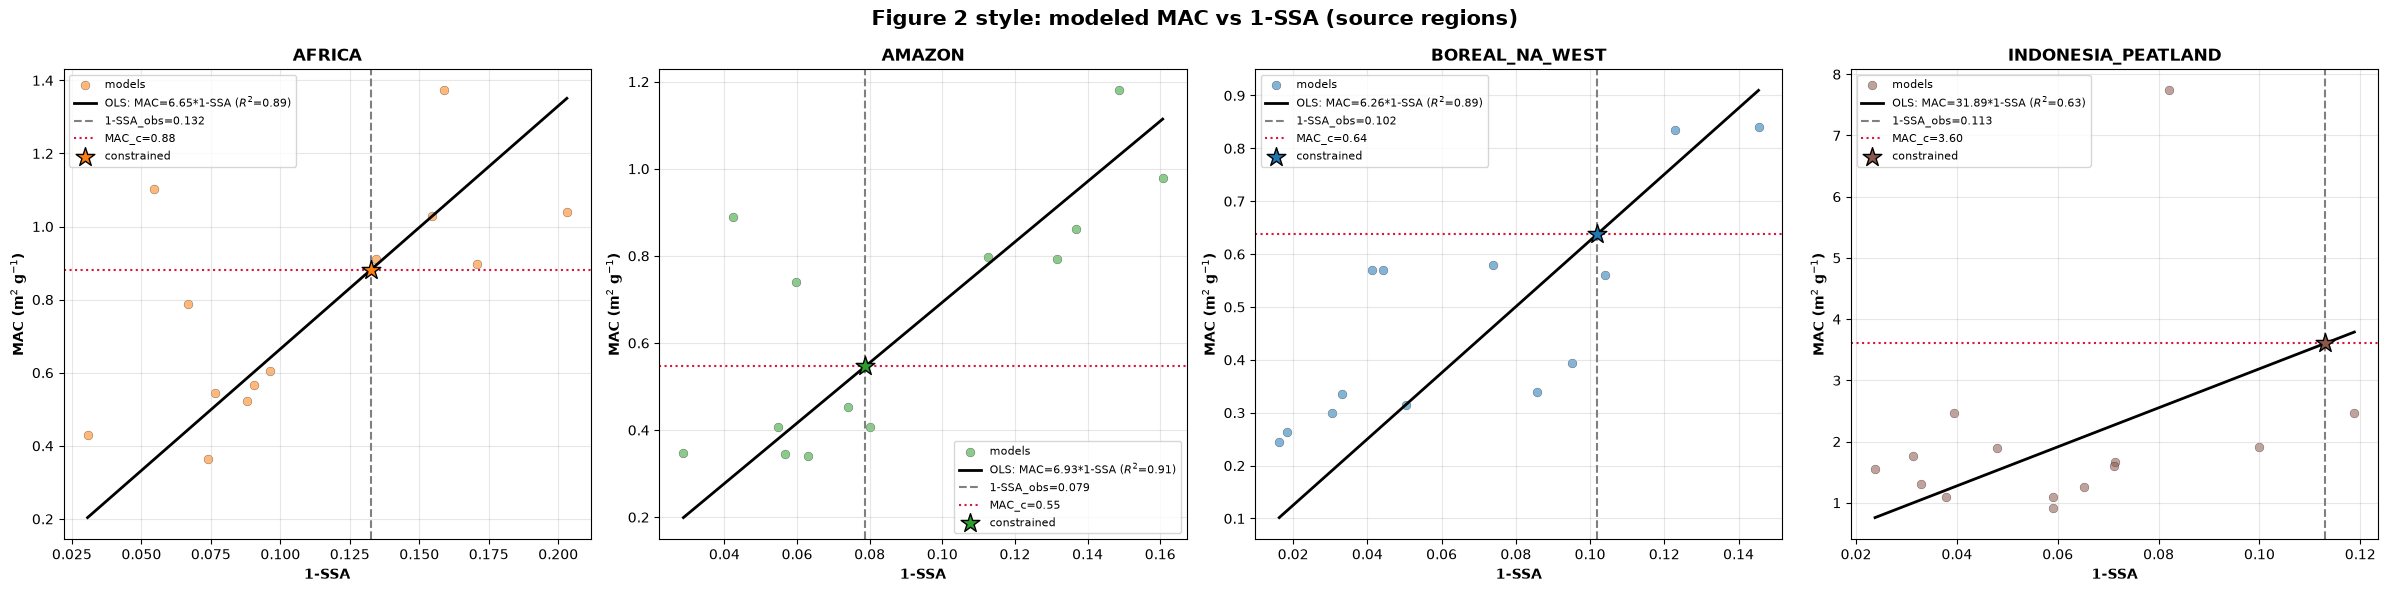

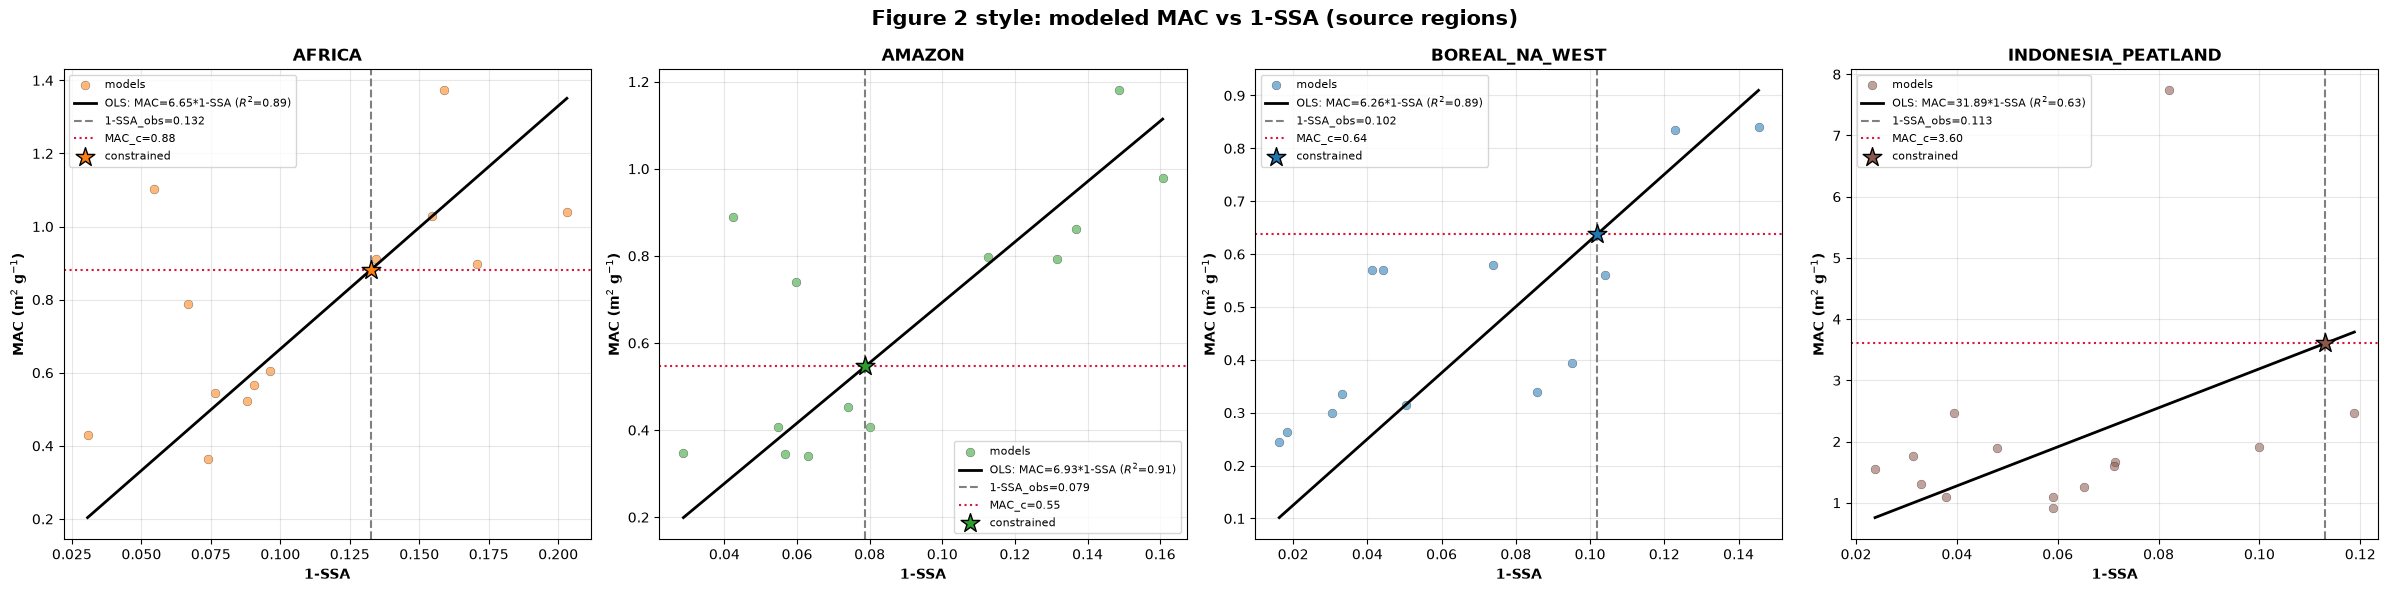

In [25]:
def plot_mac_vs_ssa(plot_regions, title_suffix=''):
    """Fig. 2 style panel(s): MAC vs MAC_X_COL per model, one subplot per region.

    Parameters
    ----------
    plot_regions : list[str]
        Region keys (must exist in ``REGIONS``/``mac_ssa_results``).
    title_suffix : str
        Appended to the figure title (e.g. to distinguish paper-region vs.
        extended-region calls).
    """
    n = len(plot_regions)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6), squeeze=False)
    axes = axes[0]
    for ax, region in zip(axes, plot_regions):
        x_col = mac_ssa_results.get(region, {}).get('x_col', MAC_X_COL)
        sub = reg_df[reg_df['region'] == region].dropna(subset=['MAC', x_col])
        color = REGION_COLORS.get(region, 'tab:blue')
        if sub.empty or region not in mac_ssa_results:
            ax.text(0.5, 0.5, 'no regression\n(insufficient data)', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='gray')
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_title(region.upper(), fontweight='bold')
            continue
        ax.scatter(sub[x_col], sub['MAC'], s=40, alpha=0.55, color=color,
                   edgecolors='black', linewidths=0.3, label='models')
        F = mac_ssa_results[region]['F']
        b = mac_ssa_results[region].get('b', 0.0)
        r2 = mac_ssa_results[region]['r2']
        x_line = np.linspace(sub[x_col].min(), sub[x_col].max(), 100)
        fit_label = (
            f'OLS: MAC={F:.2f}*{x_col}'
            + (f'+{b:.2f}' if abs(b) > 1e-12 else '')
            + f' ($R^2$={r2:.2f})'
        )
        ax.plot(x_line, F * x_line + b, '-', color='black', linewidth=2, label=fit_label)
        csub = constrained_df[constrained_df['region'] == region]
        if not csub.empty:
            x_obs = float(csub['MAC_x_obs'].mean()) if 'MAC_x_obs' in csub else float(csub['SSA_obs'].mean())
            mac_c = float(csub['MAC_c'].mean())
            ax.axvline(x_obs, color='gray', linestyle='--', linewidth=1.5,
                       label=f'{x_col}_obs={x_obs:.3f}')
            ax.axhline(mac_c, color='crimson', linestyle=':', linewidth=1.5,
                       label=f'MAC_c={mac_c:.2f}')
            ax.scatter([x_obs], [mac_c], marker='*', s=200, color=color,
                       edgecolors='black', zorder=6, label='constrained')
        ax.set_xlabel(x_col, fontweight='bold')
        ax.set_ylabel('MAC (m$^2$ g$^{-1}$)', fontweight='bold')
        ax.set_title(region.upper(), fontweight='bold')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    fig.suptitle(
        f'Figure 2 style: modeled MAC vs {MAC_X_COL}{title_suffix}',
        fontsize=15, fontweight='bold',
    )
    plt.tight_layout()
    return fig


print(f'\n--- Fig. 2 style MAC vs {MAC_X_COL}: paper regions (amazon, africa) ---') 
fig_2_paper = plot_mac_vs_ssa(SOURCE_REGIONS, ' (source regions)')
if SAVE_FIGURE:
    fig_2_paper.savefig(FIGURE_DIR / 'fig2_mac_vs_ssa_paper.png', dpi=300, bbox_inches='tight')
    print('Saved: fig2_mac_vs_ssa_paper.png')
    plt.close(fig_2_paper)

print(f'\n--- Fig. 2 style MAC vs {MAC_X_COL}: all source regions (extended) ---')
fig_2_all = plot_mac_vs_ssa(SOURCE_REGIONS, ' (source regions)')
if SAVE_FIGURE:
    fig_2_all.savefig(FIGURE_DIR / 'fig2_mac_vs_ssa_all_regions.png', dpi=300, bbox_inches='tight')
    print('Saved: fig2_mac_vs_ssa_all_regions.png')
    plt.close(fig_2_all)


**Figure caption — Modeled MAC vs SSA or (1−SSA) (Fig. 2 style)**

One subplot per region. Points: seasonal-mean **MAC** vs **`MAC_X_COL`** (`SSA` or `1−SSA`). Regression matches cell-1 settings (`INTERCEPT_0`). Vertical dashed line: observed x (from homogenized SSA); horizontal dashed line: constrained `MAC_C`.

Two figure variants are produced: paper-focused regions (amazon, africa) and all `SOURCE_REGIONS`.

**Data:** Same regional seasonal means as Fig. 3 panel (a). MAC = seasonal AAOD / seasonal BC+OA column burden after grid alignment where required (e.g. SPRINTARS).


## Outflow prediction plot: model vs meta-fit vs constrained vs POLDER



--- Outflow prediction plot (panel B: model + meta-fit points) ---
  Outflow meta-model coefficients (Nature Eq. 6 / AAOD):
    A (E*tau*MAC) = 7.8996e-01
    B (E*tau)     = 6.5144e-02
    C (MAC)       = -3.2101e-03
    D (const)     = -3.8460e-03
  Diagnostics: R²=0.872, NMB=-0.0%, RMSE=0.00752, n=18
  tau: physical box_budget only (n=18)


/tmp/ipykernel_3631161/204166854.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


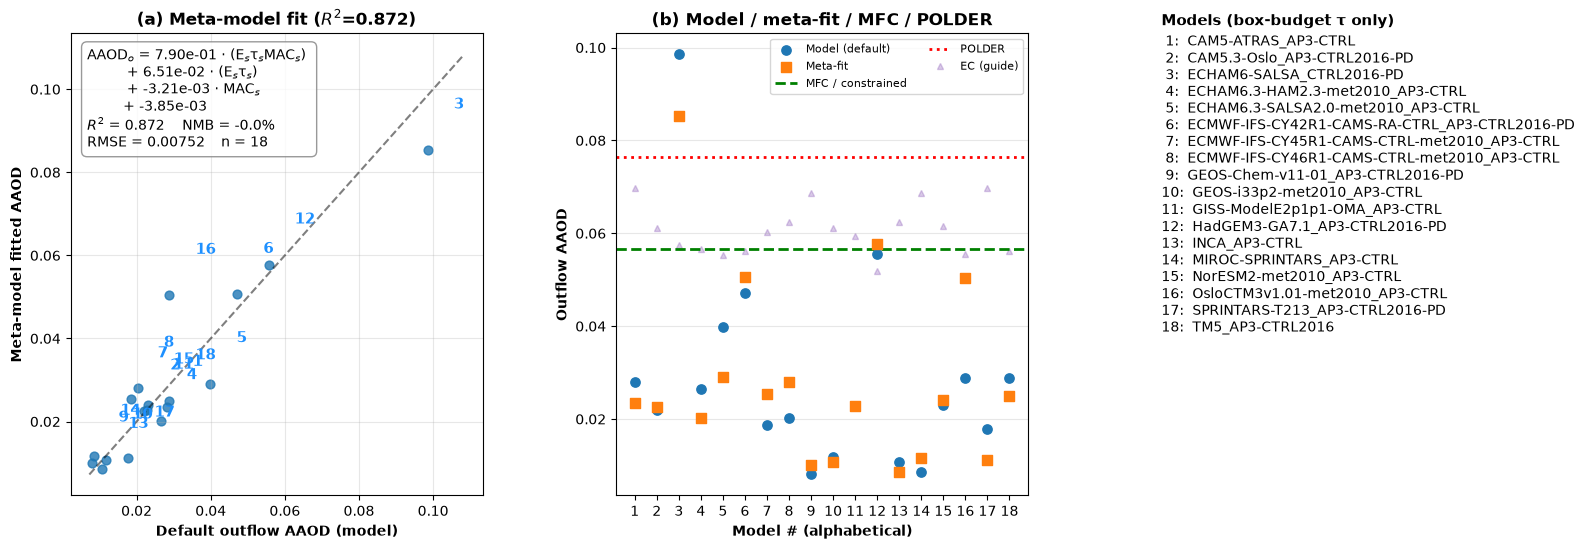

In [21]:
print('\n--- Outflow prediction plot (panel B: model + meta-fit points) ---')

if outflow_pred_df.empty:
    print('  No outflow predictions to plot.')
else:
    sub = outflow_pred_df.sort_values('model', ascending=True).reset_index(drop=True)
    model_numbers = {row['model']: idx + 1 for idx, row in sub.iterrows()}
    sub['model_num'] = [model_numbers[row['model']] for _, row in sub.iterrows()]

    # Prefer Nature-style column names; fall back to legacy aliases
    col_default = 'AAOD_default' if 'AAOD_default' in sub.columns else 'AAOD_model'
    col_mfc = 'AAOD_MFC' if 'AAOD_MFC' in sub.columns else 'AAOD_constrained'
    has_ec = 'AAOD_EC' in sub.columns

    fig = plt.figure(figsize=(17, 6))
    gs = fig.add_gridspec(1, 3, width_ratios=[2, 2, 1.1], wspace=0.38)
    axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]

    if outflow_meta_params and all(k in outflow_meta_params for k in ['a', 'b', 'c', 'd']):
        a = outflow_meta_params['a']
        b = outflow_meta_params['b']
        c = outflow_meta_params['c']
        d = outflow_meta_params['d']
        eqn_str = (
            r"AAOD$_o$ = "
            f"{a:.2e} $\\cdot$ (E$_s$τ$_s$MAC$_s$) " "\n"
            f"         + {b:.2e} $\\cdot$ (E$_s$τ$_s$)" "\n"
            f"         + {c:.2e} $\\cdot$ MAC$_s$" "\n"
            f"         + {d:.2e}"
        )
    else:
        eqn_str = (
            r"AAOD$_o$ = A(E$_s$τ$_s$MAC$_s$) + B(E$_s$τ$_s$)" "\n"
            r"         + C·MAC$_s$ + D"
        )

    nmb = outflow_meta_params['nmb'] if outflow_meta_params and 'nmb' in outflow_meta_params else np.nan
    rmse = outflow_meta_params['rmse'] if outflow_meta_params and 'rmse' in outflow_meta_params else np.nan
    r2 = outflow_meta_params['r2'] if outflow_meta_params and 'r2' in outflow_meta_params else np.nan
    n_fit = outflow_meta_params['n'] if outflow_meta_params and 'n' in outflow_meta_params else len(sub)

    # (a) Meta-model fit vs Default outflow AAOD
    ax = axes[0]
    ax.scatter(sub[col_default], sub['AAOD_meta_fit'], s=40, alpha=0.8)
    lims = [
        min(sub[col_default].min(), sub['AAOD_meta_fit'].min()) * 0.9,
        max(sub[col_default].max(), sub['AAOD_meta_fit'].max()) * 1.1,
    ]
    ax.plot(lims, lims, 'k--', alpha=0.5)
    ax.set_xlabel('Default outflow AAOD (model)', fontweight='bold')
    ax.set_ylabel('Meta-model fitted AAOD', fontweight='bold')
    label_x_offset = 0.07 * (lims[1] - lims[0])
    label_y_offset = 0.09 * (lims[1] - lims[0])
    for _, row in sub.iterrows():
        ax.text(
            row[col_default] + label_x_offset,
            row['AAOD_meta_fit'] + label_y_offset,
            f"{int(row['model_num'])}",
            fontsize=11, color='dodgerblue', fontweight='bold',
            ha='left', va='bottom', clip_on=True,
        )
    textstr = (f"{eqn_str}\n"
               + f"$R^2$ = {r2:.3f}    NMB = {nmb:.1f}%\n"
               + f"RMSE = {rmse:.5f}    n = {n_fit}")
    ax.text(
        0.04, 0.97, textstr, transform=ax.transAxes, fontsize=10,
        va='top', ha='left',
        bbox=dict(boxstyle="round,pad=0.4", fc="w", ec="gray", alpha=0.8),
    )
    ax.set_title(f'(a) Meta-model fit ($R^2$={r2:.3f})', fontweight='bold')
    ax.grid(True, alpha=0.3)

    # # --- Previous panel (b): Default / EC / MFC bars (Nature Fig. 5 / Fig. S7B style) ---
    # ax2 = axes[1]
    # x = np.arange(len(sub))
    # width = 0.25 if has_ec else 0.35
    # if has_ec:
    #     ax2.bar(x - width, sub[col_default], width=width, color='#2ca02c',
    #             label='Default', alpha=0.9)
    #     ax2.bar(x, sub['AAOD_EC'], width=width, color='#ff7f0e',
    #             label='EC', alpha=0.9)
    #     ax2.bar(x + width, sub[col_mfc], width=width, color='#1f77b4',
    #             label='MFC', alpha=0.9)
    #     ax2.axhline(sub[col_default].median(), color='#2ca02c', linestyle='--',
    #                 linewidth=1.2, alpha=0.7)
    #     ax2.axhline(sub['AAOD_EC'].median(), color='#ff7f0e', linestyle='--',
    #                 linewidth=1.2, alpha=0.7)
    # else:
    #     ax2.scatter(x, sub[col_default], s=40, label='Default / model')
    #     ax2.scatter(x, sub['AAOD_meta_fit'], s=40, marker='s', label='Meta-fit')
    #     ax2.axhline(sub[col_mfc].iloc[0], color='green', linestyle='--', linewidth=2,
    #                 label='MFC / constrained')
    # ax2.axhline(sub['AAOD_obs'].iloc[0], color='red', linestyle=':', linewidth=2,
    #             label='POLDER')
    # ax2.set_xticks(x)
    # ax2.set_xticklabels([str(n) for n in sub['model_num']], rotation=0, fontsize=10, ha='center')
    # ax2.set_xlabel('Model # (alphabetical)', fontweight='bold')
    # ax2.set_ylabel('Outflow AAOD', fontweight='bold')
    # ax2.set_title('(b) Default / EC / MFC / POLDER', fontweight='bold')
    # ax2.legend(fontsize=8, ncol=2, loc='best')
    # ax2.grid(True, alpha=0.3, axis='y')

    # (b) Model vs meta-fit points (preferred clarity; MFC + POLDER as reference lines)
    ax2 = axes[1]
    x = np.arange(len(sub))
    ax2.scatter(x, sub[col_default], s=45, color='#1f77b4', label='Model (default)', zorder=3)
    ax2.scatter(x, sub['AAOD_meta_fit'], s=45, marker='s', color='#ff7f0e',
                label='Meta-fit', zorder=3)
    ax2.axhline(sub[col_mfc].iloc[0], color='green', linestyle='--', linewidth=2,
                label='MFC / constrained', zorder=2)
    ax2.axhline(sub['AAOD_obs'].iloc[0], color='red', linestyle=':', linewidth=2,
                label='POLDER', zorder=2)
    if has_ec:
        # Keep EC available as a light guide without replacing the point style
        ax2.plot(x, sub['AAOD_EC'], color='#9467bd', linestyle='none', marker='^',
                 markersize=5, alpha=0.35, label='EC (guide)', zorder=1)
    ax2.set_xticks(x)
    ax2.set_xticklabels([str(n) for n in sub['model_num']], rotation=0, fontsize=10, ha='center')
    ax2.set_xlabel('Model # (alphabetical)', fontweight='bold')
    ax2.set_ylabel('Outflow AAOD', fontweight='bold')
    ax2.set_title('(b) Model / meta-fit / MFC / POLDER', fontweight='bold')
    ax2.legend(fontsize=8, ncol=2, loc='best')
    ax2.grid(True, alpha=0.3, axis='y')

    # (c) model number legend
    ax_legend = axes[2]
    ax_legend.axis('off')
    legend_lines = []
    for _, row in sub.iterrows():
        legend_lines.append(f"{int(row['model_num']):2d}:  {row['model']}")
    ax_legend.text(0, 1, "\n".join(legend_lines), va='top', ha='left', fontsize=10)
    ax_legend.set_title('Models (box-budget τ only)', loc='left', fontsize=11, fontweight='bold')

    plt.tight_layout()
    fig_path = FIGURE_DIR / 'figure3_outflow_meta_prediction.png'
    if SAVE_FIGURE:
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f'Saved: {fig_path}')
        plt.close(fig)

    if outflow_meta_params:
        print(
            f"  Outflow meta-model coefficients (Nature Eq. 6 / AAOD):"
            f"\n    A (E*tau*MAC) = {outflow_meta_params['a']:.4e}"
            f"\n    B (E*tau)     = {outflow_meta_params['b']:.4e}"
            f"\n    C (MAC)       = {outflow_meta_params['c']:.4e}"
            f"\n    D (const)     = {outflow_meta_params['d']:.4e}"
            f"\n  Diagnostics: R²={r2:.3f}, NMB={nmb:.1f}%, RMSE={rmse:.5f}, n={n_fit}"
            f"\n  tau: physical box_budget only "
            f"(n={outflow_meta_params.get('tau_box_budget_n', outflow_meta_params.get('n', '?'))})"
        )


**Figure caption — African outflow meta-model (Sci. Adv. SM Text 2 / Fig. S7 style)**

Zhong *Nat. Commun.* 2022 Eq. 6 adapted to AAOD (MEC → MAC), fit on AeroCom models with **physical box-budget African τ only** (models with filtered/NaN τ—e.g. CAM5_CTRL2016, EC-Earth3, GFDL-AM4, TM5-met2010—are excluded):

`AAOD_o = A·(E_s τ_s MAC_s) + B·(E_s τ_s) + C·MAC_s + D`

with source predictors from **africa** and target = seasonal-mean model `abs550aer` in **`outflow_af`**. Emission *E* is converted to g m⁻² day⁻¹ so `E·τ·MAC` matches the AAOD unit convention used in the source decomposition.

**(a)** Meta-fit vs Default model outflow AAOD (1:1 line, R²/NMB/RMSE).  
**(b)** Per-model Default (circles) and meta-fit (squares); dashed **MFC** = prediction using constrained African `(E_C, τ_C, MAC_C)`; dotted **POLDER** = raw **sampled** clear-sky seasonal AAOD in the outflow box (no homogenization); faint triangles = emission-corrected (EC) guide.  
**(c)** Alphabetical model legend.

**Aggregation:** Outflow box `lon=(350,8)`, `lat=(-15,3)`, Jun–Sep 2010, ocean, edge-weighted spatial means for models; POLDER cos(lat)-weighted mean of 3-hourly clear-sky samples in the same box/season. Africa constrained values use homogenized source AAOD/SSA and precip+AE lifetime regression.


### Outflow meta-fit R² vs Zhong Fig. S7 — sensitivity checklist

Paper Fig. S7A reports **R² ≈ 0.97** (n ≈ 17 AeroCom models; Sci. Adv. 2023 SM).

**Notebook default (updated):** outflow meta-fit uses **physical `box_budget` τ only** (expect **n≈18, R²≈0.87**). Models without finite filtered source τ are excluded.

Sensitivity suite (`notebooks/outflow_meta_r2_sensitivity.py`; `figure3_outflow_sensitivity_summary.csv`):

1. **Exclude τ̂ models** — `box_budget` only: **n=18, R²=0.872** ← now the notebook default.
2. **Paper-like ensemble** — exact Fig. S7B list unknown. Best-effort:
   - drop checklist extras ∩ `box_budget`: **n=12, R²=0.967** (matches paper ≈0.97)
   - closest n≈17: `box_budget` minus OsloCTM3 → **n=17, R²=0.943**
3. Full n=22 with regression τ̂ gave R²≈0.66 (sensitivity contrast only).
4. **Units** — E in kg m⁻² s⁻¹ vs g m⁻² d⁻¹: **ΔR² ≈ 0**.
5–6. Target regional-mean / total E — skipped (not in saved CSVs).
7. **Do not confuse** Nature 2022 AOD/MEC Fig. 5 with Sci. Adv. 2023 AAOD/MAC Fig. S7.

**Recommendation:** keep physical `box_budget` τ for Fig. S7; optionally report a paper-like subset (n=12 or n=17 − OsloCTM3) for closer R² match.

**POLDER / MFC (Fig. S7B):** keep aligned outflow bbox; report MFC next to POLDER and state the residual gap is from AeroCom outflow underestimation embedded in Eq. 6 — do not homogenize outflow obs or reinject unphysical τ to force agreement. Prefer showing EC alongside MFC.


### Outflow R² sensitivity — results table

Script: `notebooks/outflow_meta_r2_sensitivity.py`  
Artifacts: `figure3_outflow_sensitivity_summary.csv`, `figure3_outflow_sensitivity_loo.csv`, `figure3_outflow_sensitivity_summary.png`

| Experiment | n | R² | RMSE | NMB (%) | Interpretation |
|---|---:|---:|---:|---:|---|
| Baseline (all) | 22 | 0.659 | 0.01113 | ~0 | Notebook default; 4 τ̂ models dilute fit |
| Box-budget τ only | 18 | 0.872 | 0.00752 | ~0 | Main R² gain vs paper gap |
| Paper-like (drop extras) | 16 | 0.744 | 0.01028 | ~0 | Extras drop alone insufficient if τ̂ kept |
| Paper-like ∩ box-budget | 12 | **0.967** | 0.00422 | ~0 | Matches Zhong Fig. S7A ≈0.97 |
| n≈17 box-budget − OsloCTM3 | 17 | 0.943 | 0.00513 | ~0 | Closest n to paper |
| LOO − OsloCTM3 (full) | 21 | 0.738 | 0.00998 | ~0 | Best single-model LOO gain |
| LOO − ECHAM6-SALSA (full) | 21 | 0.636 | 0.00717 | ~0 | High-leverage; removing hurts R² |
| E units kg m⁻² s⁻¹ | 22 | 0.659 | 0.01113 | ~0 | R² unchanged vs g m⁻² d⁻¹ |
| Raw unphysical τ (4 models) | 22 | 0.857 | 0.00720 | ~0 | Diagnostic only; τ̂+tiny E was worse in-sample |
| Target regional-mean / total E | — | — | — | — | Skipped (data not in saved CSVs) |


### Outflow POLDER vs MFC diagnostics (Fig. S7B)

After aligning `outflow_af` to `lon=(350, 8)`, `lat=(-15, 3)`:

| Quantity | Value | Note |
|----------|------:|------|
| POLDER sampled AAOD (new box) | **≈0.0697** | Was 0.0764 with `(350,15)×(-15,0)` |
| MFC (box-budget n=18) | **≈0.0566** | Gap vs obs ≈ −0.013 |
| Mean Default | ≈0.0287 | Models underestimate outflow |
| Mean EC | ≈0.0608 | Closer to POLDER than MFC |
| Paper-like ∩ box-budget MFC | ≈0.0626 | Gap ≈ −0.007 |

Artifacts: `figure3_outflow_mfc_diagnostics.csv`, `figure3_outflow_bbox_polder_note.txt`, `figure3_outflow_africa_constraint_crosscheck.md`.

**Africa constraints (notebook):** homogenized AAOD_obs≈0.0733, MAC_c≈0.881 (`MAC_X_COL='1-SSA'`), τ_c≈3.05 d, E_c≈3.16×10⁻¹⁰ kg m⁻² s⁻¹. Sci. Adv. publishes these mainly in figures; MAC_c rescales (keeping E·τ·MAC=AAOD_obs) do **not** close the MFC gap — see diagnostic MAC_c rows.


In [ ]:
# MFC / POLDER diagnostics (Zhong Fig. S7B gap)
import runpy
_mfc_ns = runpy.run_path(str(project_root / 'notebooks' / 'outflow_mfc_diagnostics.py'))
_mfc_df = _mfc_ns['main']()
display_cols = [
    'ensemble', 'n', 'R2', 'POLDER_obs', 'MFC', 'MFC_minus_obs',
    'mean_Default', 'mean_EC', 'MFC_over_Africa_AAOD',
    'term_A_X1', 'term_B_X2', 'term_C_X3', 'term_D',
]
print('\n--- Outflow MFC diagnostics ---')
print(_mfc_df[display_cols].to_string(index=False))
print('\nSee also: notebooks/figure3_outflow_africa_constraint_crosscheck.md')


Wrote /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/tables/figure3_outflow_mfc_diagnostics.csv
                ensemble  n      R2  POLDER_obs     MFC  MFC_minus_obs  mean_Default  mean_EC  MFC_over_Africa_AAOD  term_A_X1  term_B_X2  term_C_X3   term_D
          box_budget_n18 18 0.87157     0.06969 0.05665       -0.01304       0.02871  0.06080               0.77285    0.05790    0.00542   -0.00283 -0.00385
    paperlike_box_budget 12 0.96723     0.06969 0.06262       -0.00707       0.03020  0.06672               0.85428    0.06310    0.00466    0.00089 -0.00603
box_budget_drop_OsloCTM3 17 0.94347     0.06969 0.05864       -0.01105       0.02870  0.05643               0.79996    0.07863   -0.01508   -0.00979  0.00488
   box_budget_MAC_c=0.88 18 0.87157     0.06969 0.05666       -0.01303       0.02871      NaN               0.77298    0.05790    0.00543   -0.00282 -0.00385
   box_budget_MAC_c=1.20 18 0.87157     0.06969 0.05418       -0.01550       0.02871      NaN       

In [ ]:
# Re-run outflow meta-model R² sensitivity suite from saved figure3_*.csv
# (does not recompute regional means / full notebook pipeline).
import runpy
_sens = runpy.run_path(str(project_root / 'notebooks' / 'outflow_meta_r2_sensitivity.py'))


### Outflow prediction plots — paper-like ∩ box-budget ensemble

Refit Zhong Eq. 6 / Fig. S7 using only models with physical box-budget $\tau$ **and** excluding the checklist extras (HadGEM, GEOS-Chem, NorESM2, OsloCTM3, CAMS-CY45/46). Remakes panels (a)–(c) like the main outflow figure; saves `figure3_outflow_meta_prediction_paperlike.png` (does not overwrite the full n=18 figure).



--- Outflow plots: paper-like ∩ box_budget ---
  Fit: n=12, R²=0.967, RMSE=0.00422, NMB=-0.0%
  Models: ['CAM5-ATRAS_AP3-CTRL', 'CAM5.3-Oslo_AP3-CTRL2016-PD', 'ECHAM6-SALSA_CTRL2016-PD', 'ECHAM6.3-HAM2.3-met2010_AP3-CTRL', 'ECHAM6.3-SALSA2.0-met2010_AP3-CTRL', 'ECMWF-IFS-CY42R1-CAMS-RA-CTRL_AP3-CTRL2016-PD', 'GEOS-i33p2-met2010_AP3-CTRL', 'GISS-ModelE2p1p1-OMA_AP3-CTRL', 'INCA_AP3-CTRL', 'MIROC-SPRINTARS_AP3-CTRL', 'SPRINTARS-T213_AP3-CTRL2016-PD', 'TM5_AP3-CTRL2016']
  MFC=0.06262  POLDER=0.07639  gap=-0.01377
  (SAVE_FIGURE=False; would save figure3_outflow_meta_prediction_paperlike.png)


/tmp/ipykernel_3631161/3766975270.py:176: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


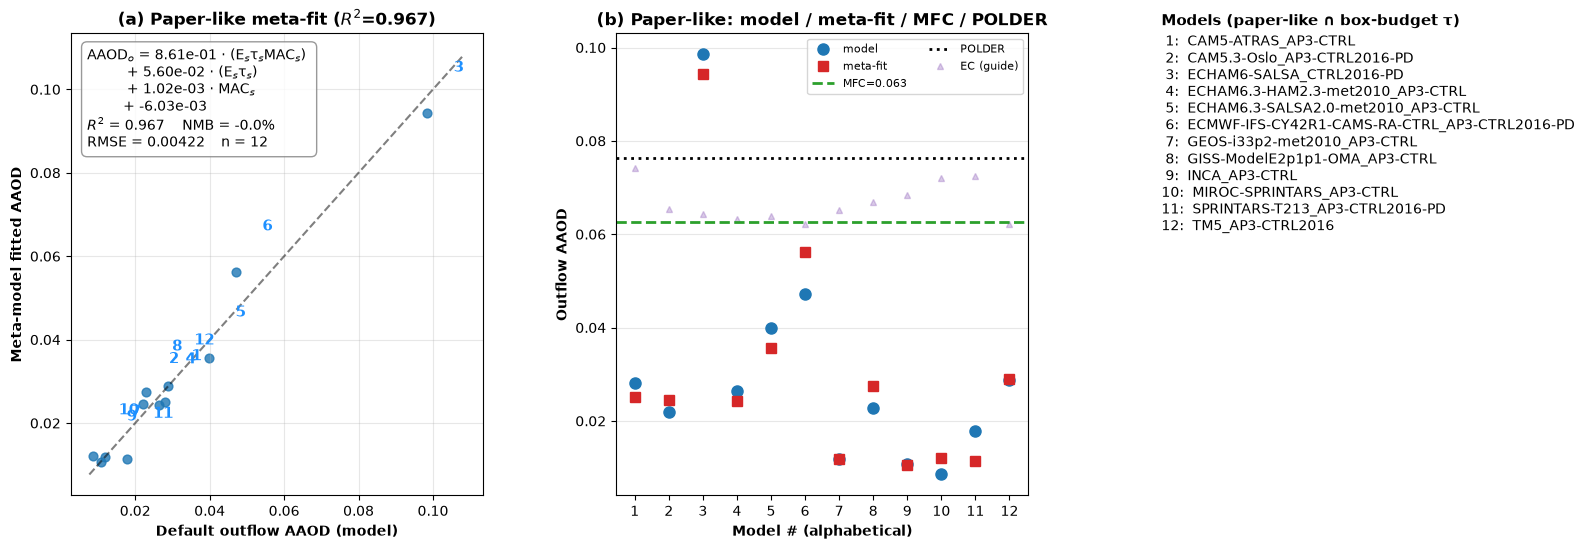

Saved: /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/tables/figure3_outflow_meta_predictions_paperlike.csv


In [26]:
# Remake outflow Default / meta-fit / MFC plots on paper-like ∩ box-budget ensemble
print('\n--- Outflow plots: paper-like ∩ box_budget ---')

PAPERLIKE_DROP = [
    'HadGEM3-GA7.1_AP3-CTRL2016-PD',
    'GEOS-Chem-v11-01_AP3-CTRL2016-PD',
    'NorESM2-met2010_AP3-CTRL',
    'OsloCTM3v1.01-met2010_AP3-CTRL',
    'ECMWF-IFS-CY45R1-CAMS-CTRL-met2010_AP3-CTRL',
    'ECMWF-IFS-CY46R1-CAMS-CTRL-met2010_AP3-CTRL',
]

# Prefer live meta_df from the outflow cell; else rebuild from model_seasonal
if 'meta_df' in globals() and not meta_df.empty and 'tau_origin' in meta_df.columns:
    _pl_src = meta_df.copy()
else:
    _pl_rows = []
    for model in models:
        aaod_out = model_seasonal[OUTFLOW_REGION].get('abs550aer', {}).get(model)
        e_src = model_seasonal[OUTFLOW_SOURCE].get('emi_BC_OA', {}).get(model)
        mac_src = model_seasonal[OUTFLOW_SOURCE].get('MAC', {}).get(model)
        tau_src = model_seasonal[OUTFLOW_SOURCE].get('lifetime_BC_OA', {}).get(model)
        if not all(_finite(v) for v in [aaod_out, e_src, mac_src, tau_src]):
            continue
        e_src, mac_src, tau_src = float(e_src), float(mac_src), float(tau_src)
        x1, x2, x3 = _es_tau_mac_terms(e_src, tau_src, mac_src)
        _pl_rows.append({
            'model': model, 'AAOD_out': float(aaod_out),
            'E': e_src, 'tau': tau_src, 'MAC': mac_src,
            'tau_origin': 'box_budget',
            'E_tau_MAC': x1, 'E_tau': x2,
        })
    _pl_src = pd.DataFrame(_pl_rows)

_pl_meta = _pl_src[
    (_pl_src['tau_origin'] == 'box_budget')
    & (~_pl_src['model'].isin(PAPERLIKE_DROP))
].copy().sort_values('model').reset_index(drop=True)

if len(_pl_meta) < 4:
    print(f'  Insufficient paper-like models (n={len(_pl_meta)}); skip plot.')
else:
    X = np.column_stack([
        _pl_meta['E_tau_MAC'].values,
        _pl_meta['E_tau'].values,
        _pl_meta['MAC'].values,
        np.ones(len(_pl_meta)),
    ])
    y = _pl_meta['AAOD_out'].values
    coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    A, B, C, D = [float(v) for v in coeffs]
    y_pred = X @ coeffs
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    rmse = float(np.sqrt(np.mean((y - y_pred) ** 2)))
    nmb = float(100.0 * np.mean(y_pred - y) / np.mean(y)) if np.mean(y) != 0 else np.nan
    print(f'  Fit: n={len(_pl_meta)}, R²={r2:.3f}, RMSE={rmse:.5f}, NMB={nmb:.1f}%')
    print(f'  Models: {_pl_meta["model"].tolist()}')

    csrc = constrained_df[constrained_df['region'] == OUTFLOW_SOURCE]
    aaod_out_obs = float(aaod_obs_by_region.get(
        OUTFLOW_REGION,
        polder_monthly[OUTFLOW_REGION]['AAOD_550'].mean()
        if not polder_monthly[OUTFLOW_REGION].empty else np.nan,
    ))
    aaod_src_obs = float(aaod_obs_by_region.get(
        OUTFLOW_SOURCE,
        polder_monthly[OUTFLOW_SOURCE]['AAOD_550'].mean()
        if not polder_monthly[OUTFLOW_SOURCE].empty else np.nan,
    ))
    aaod_mfc = np.nan
    if not csrc.empty:
        e_c = float(csrc['E_c'].mean())
        tau_c = float(csrc['tau_c'].mean())
        mac_c = float(csrc['MAC_c'].mean())
        x1_c, x2_c, x3_c = _es_tau_mac_terms(e_c, tau_c, mac_c)
        aaod_mfc = A * x1_c + B * x2_c + C * x3_c + D
        print(f'  MFC={aaod_mfc:.5f}  POLDER={aaod_out_obs:.5f}  gap={aaod_mfc - aaod_out_obs:.5f}')

    pred_rows = []
    for _, row in _pl_meta.iterrows():
        aaod_src_model = model_seasonal[OUTFLOW_SOURCE].get('abs550aer', {}).get(row['model'])
        if (aaod_src_model is not None and _finite(aaod_src_model)
                and _finite(aaod_src_obs) and float(aaod_src_model) != 0):
            e_ec = row['E'] * (aaod_src_obs / float(aaod_src_model))
        else:
            e_ec = row['E']
        x1_ec, x2_ec, x3_ec = _es_tau_mac_terms(e_ec, row['tau'], row['MAC'])
        aaod_ec = A * x1_ec + B * x2_ec + C * x3_ec + D
        aaod_meta = A * row['E_tau_MAC'] + B * row['E_tau'] + C * row['MAC'] + D
        pred_rows.append({
            'model': row['model'],
            'AAOD_default': row['AAOD_out'],
            'AAOD_model': row['AAOD_out'],
            'AAOD_meta_fit': float(aaod_meta),
            'AAOD_EC': float(aaod_ec),
            'AAOD_MFC': float(aaod_mfc),
            'AAOD_constrained': float(aaod_mfc),
            'AAOD_obs': aaod_out_obs,
        })
    outflow_pred_df_paperlike = pd.DataFrame(pred_rows).sort_values('model').reset_index(drop=True)
    outflow_meta_params_paperlike = {
        'a': A, 'b': B, 'c': C, 'd': D, 'A': A, 'B': B, 'C': C, 'D': D,
        'r2': r2, 'rmse': rmse, 'nmb': nmb, 'n': len(_pl_meta),
    }

    sub = outflow_pred_df_paperlike.copy()
    sub['model_num'] = np.arange(1, len(sub) + 1)
    col_default = 'AAOD_default'
    has_ec = 'AAOD_EC' in sub.columns

    eqn_str = (
        r"AAOD$_o$ = "
        f"{A:.2e} $\\cdot$ (E$_s$τ$_s$MAC$_s$) " "\n"
        f"         + {B:.2e} $\\cdot$ (E$_s$τ$_s$)" "\n"
        f"         + {C:.2e} $\\cdot$ MAC$_s$" "\n"
        f"         + {D:.2e}"
    )

    fig = plt.figure(figsize=(17, 6))
    gs = fig.add_gridspec(1, 3, width_ratios=[2, 2, 1.1], wspace=0.38)
    axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]

    ax = axes[0]
    ax.scatter(sub[col_default], sub['AAOD_meta_fit'], s=40, alpha=0.8)
    lims = [
        min(sub[col_default].min(), sub['AAOD_meta_fit'].min()) * 0.9,
        max(sub[col_default].max(), sub['AAOD_meta_fit'].max()) * 1.1,
    ]
    ax.plot(lims, lims, 'k--', alpha=0.5)
    ax.set_xlabel('Default outflow AAOD (model)', fontweight='bold')
    ax.set_ylabel('Meta-model fitted AAOD', fontweight='bold')
    label_x_offset = 0.07 * (lims[1] - lims[0])
    label_y_offset = 0.09 * (lims[1] - lims[0])
    for _, row in sub.iterrows():
        ax.text(
            row[col_default] + label_x_offset,
            row['AAOD_meta_fit'] + label_y_offset,
            f"{int(row['model_num'])}",
            fontsize=11, color='dodgerblue', fontweight='bold',
            ha='left', va='bottom', clip_on=True,
        )
    ax.text(
        0.04, 0.97,
        f"{eqn_str}\n$R^2$ = {r2:.3f}    NMB = {nmb:.1f}%\nRMSE = {rmse:.5f}    n = {len(sub)}",
        transform=ax.transAxes, fontsize=10, va='top', ha='left',
        bbox=dict(boxstyle="round,pad=0.4", fc="w", ec="gray", alpha=0.8),
    )
    ax.set_title(f'(a) Paper-like meta-fit ($R^2$={r2:.3f})', fontweight='bold')
    ax.grid(True, alpha=0.3)

    ax2 = axes[1]
    x = np.arange(len(sub))
    ax2.plot(x, sub[col_default], 'o', ms=8, color='C0', label='model', zorder=3)
    ax2.plot(x, sub['AAOD_meta_fit'], 's', ms=7, color='#d62728', label='meta-fit', zorder=3)
    ax2.axhline(aaod_mfc, color='#2ca02c', linestyle='--', linewidth=2, label=f'MFC={aaod_mfc:.3f}', zorder=2)
    ax2.axhline(aaod_out_obs, color='k', linestyle=':', linewidth=2, label='POLDER', zorder=2)
    if has_ec:
        ax2.plot(x, sub['AAOD_EC'], color='#9467bd', linestyle='none', marker='^',
                 markersize=5, alpha=0.35, label='EC (guide)', zorder=1)
    ax2.set_xticks(x)
    ax2.set_xticklabels([str(n) for n in sub['model_num']], rotation=0, fontsize=10, ha='center')
    ax2.set_xlabel('Model # (alphabetical)', fontweight='bold')
    ax2.set_ylabel('Outflow AAOD', fontweight='bold')
    ax2.set_title('(b) Paper-like: model / meta-fit / MFC / POLDER', fontweight='bold')
    ax2.legend(fontsize=8, ncol=2, loc='best')
    ax2.grid(True, alpha=0.3, axis='y')

    ax_legend = axes[2]
    ax_legend.axis('off')
    legend_lines = [f"{int(row['model_num']):2d}:  {row['model']}" for _, row in sub.iterrows()]
    ax_legend.text(0, 1, "\n".join(legend_lines), va='top', ha='left', fontsize=10)
    ax_legend.set_title('Models (paper-like ∩ box-budget τ)', loc='left', fontsize=11, fontweight='bold')

    plt.tight_layout()
    fig_path = FIGURE_DIR / 'figure3_outflow_meta_prediction_paperlike.png'
    if SAVE_FIGURE:
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f'Saved: {fig_path}')
    else:
        print(f'  (SAVE_FIGURE=False; would save {fig_path.name})')
        plt.show()

    out_csv = TABLE_DIR / 'figure3_outflow_meta_predictions_paperlike.csv'
    outflow_pred_df_paperlike.to_csv(out_csv, index=False)
    print(f'Saved: {out_csv}')


**Figure caption — Outflow meta-model, paper-like ∩ box-budget ensemble**

Same Eq. 6 / panel layout as the main outflow figure, but the OLS fit is restricted to models that (i) have finite post-aggregation box-budget African lifetime and (ii) are not in the checklist extras (HadGEM, GEOS-Chem, NorESM2, OsloCTM3v1.01, CAMS-CY45/46). Typical n≈12, R²≈0.97 (closer to Zhong Fig. S7A).

MFC and POLDER use the same constrained Africa inputs and outflow sampled AAOD as the full box-budget figure; only the meta-model coefficients `(A,B,C,D)` change. Outputs: `figure3_outflow_meta_prediction_paperlike.png` and `figure3_outflow_meta_predictions_paperlike.csv`.


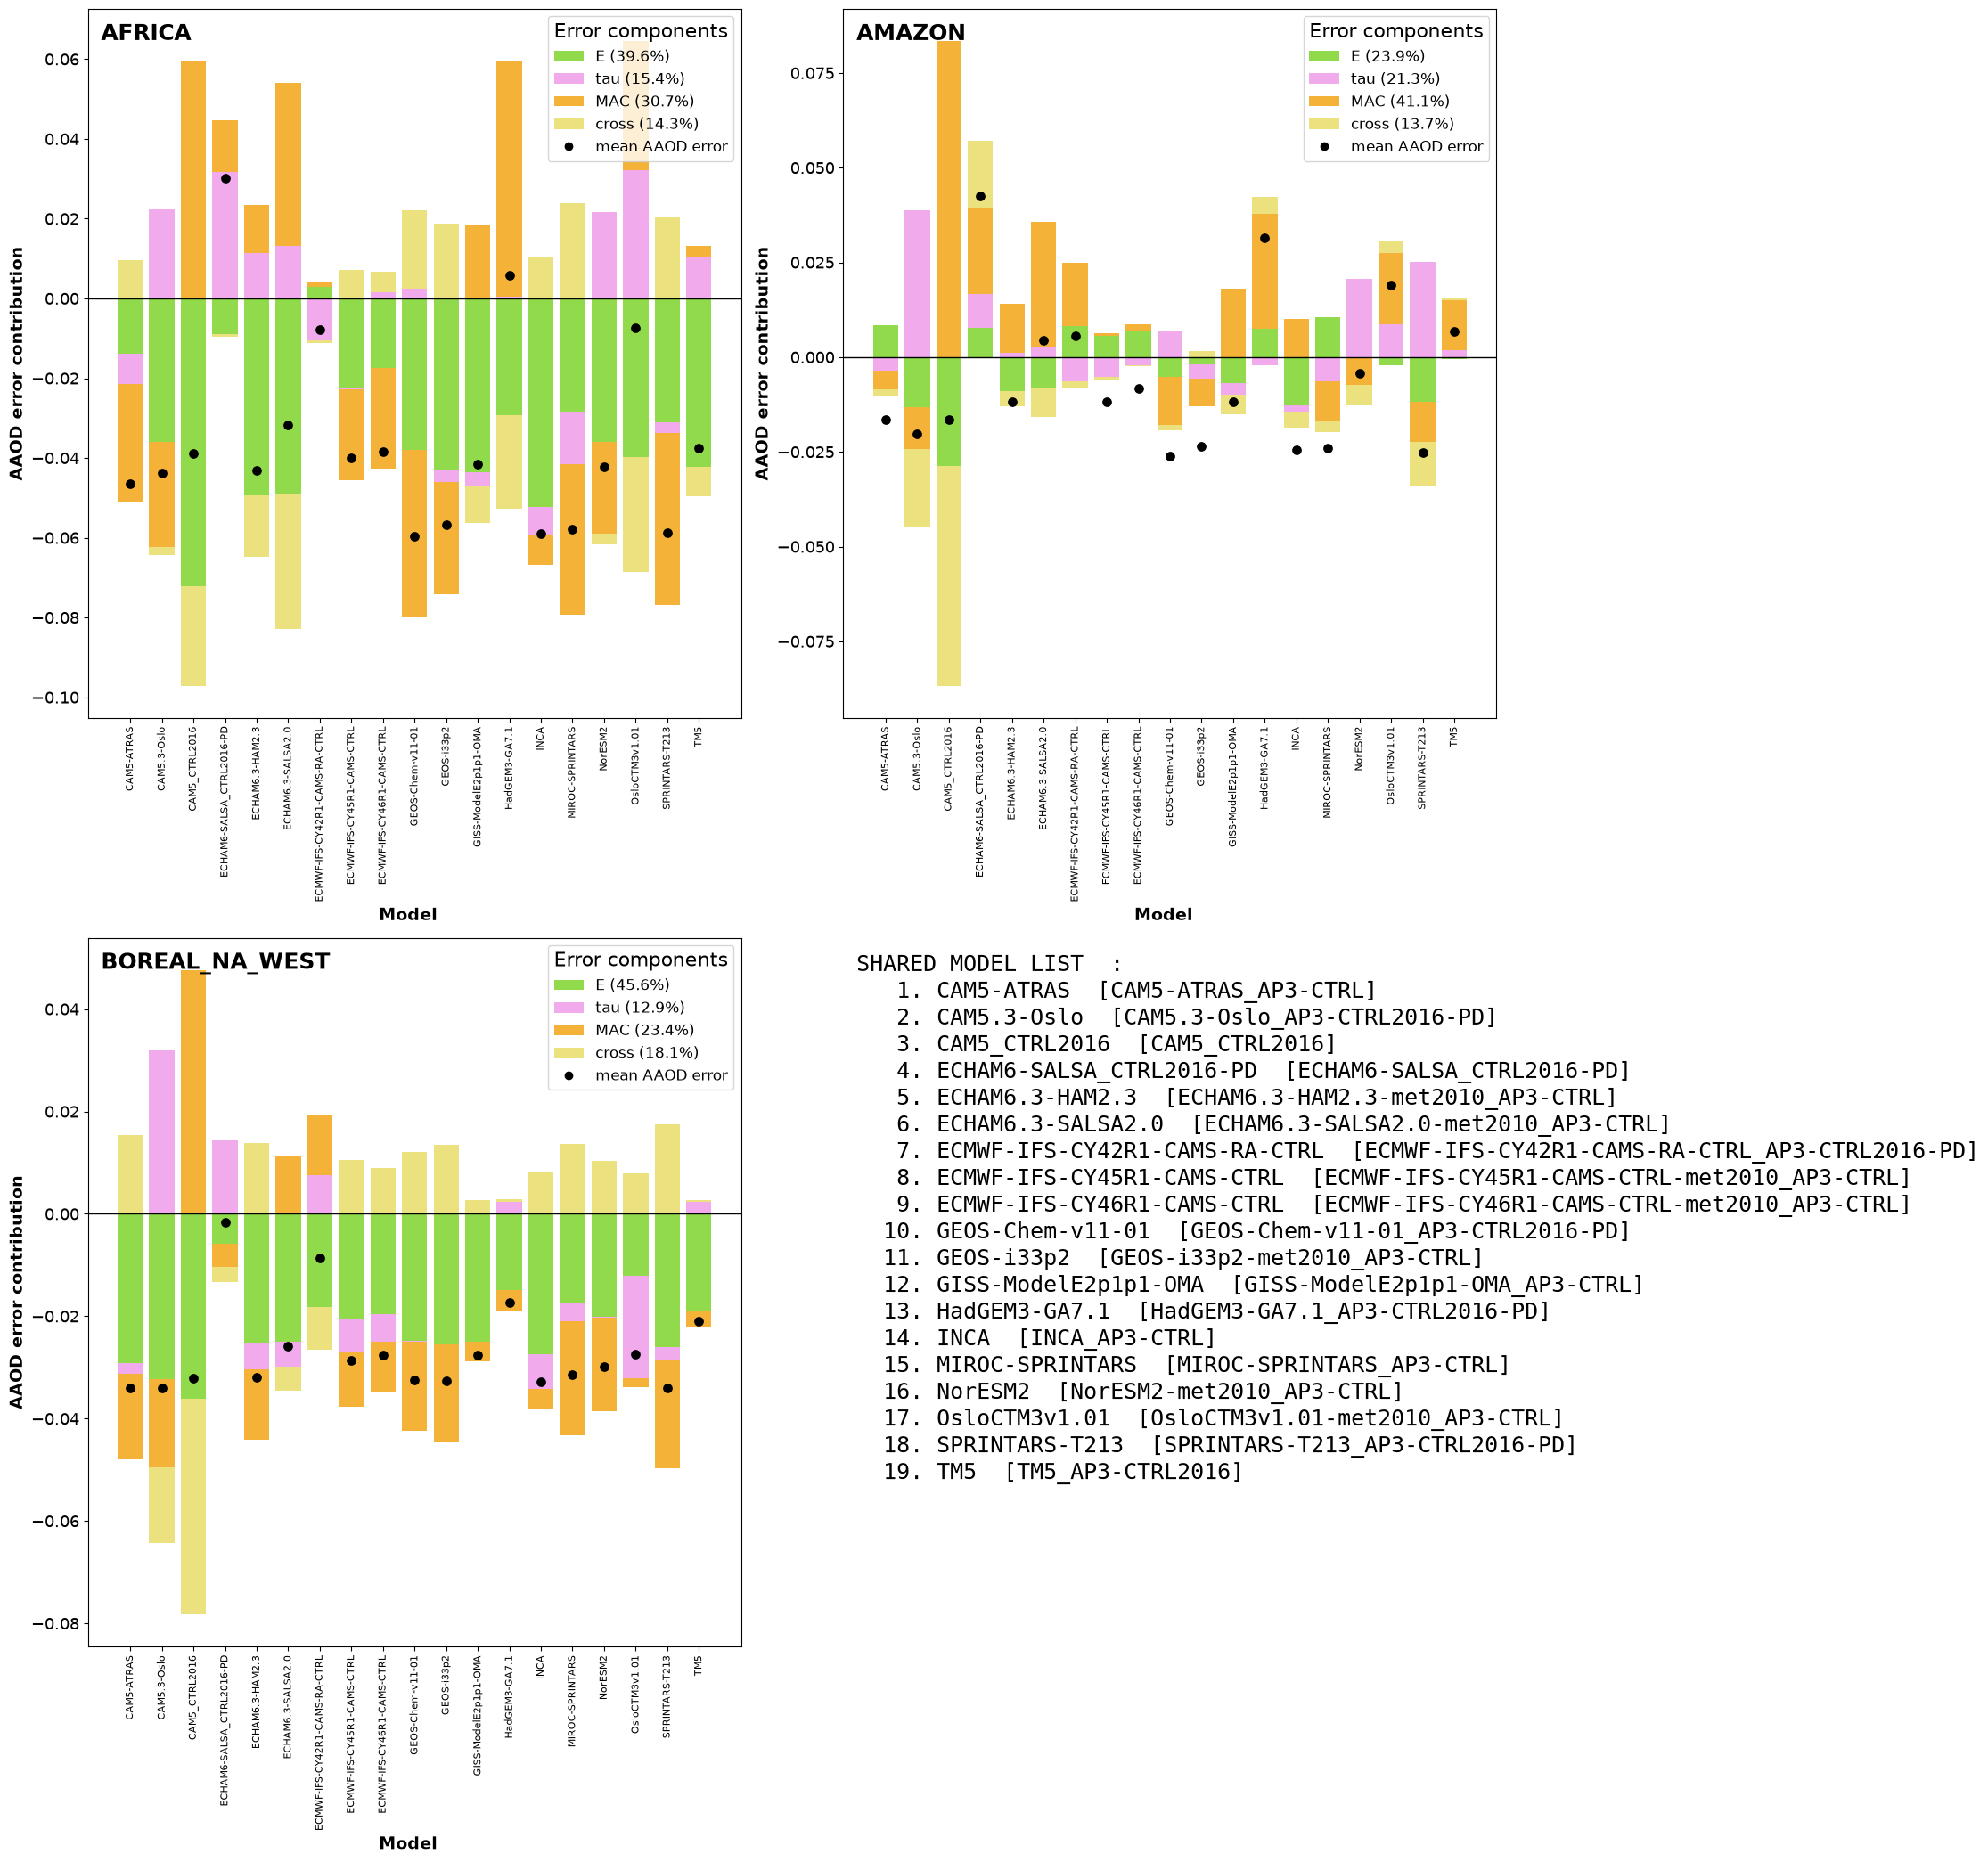

In [27]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plot_regions = ['africa', 'amazon', 'boreal_na_west']

fig, axes = plt.subplots(2, 2, figsize=(22, 7 * len(plot_regions)))

axes_flat = axes.flatten()
common_model_list = sorted(decomp_df['model'].unique().tolist())

for idx, region in enumerate(plot_regions):
    ax = axes_flat[idx]
    sub = decomp_df[decomp_df['region'] == region].copy()
    if sub.empty:
        ax.set_visible(False)
        continue

    # Align all regions to the same alphabetical model order
    sub = sub.set_index('model').reindex(common_model_list).reset_index()

    # Seasonal mean AOD error per model relative to POLDER
    model_aod = setup.aggregate_region(data_derived, 'abs550aer', region, masks, return_time_series=False)
    obs_aod_mean = polder_monthly[region]['AAOD_550'].mean() if not polder_monthly[region].empty else np.nan
    sub['AAOD_error'] = sub['model'].map(
        lambda m: float(model_aod[m]) - obs_aod_mean if (m in model_aod and pd.notna(obs_aod_mean)) else np.nan
    )

    x = np.arange(len(sub))

    # Signed stacking
    pos_bottom = np.zeros(len(sub))
    neg_bottom = np.zeros(len(sub))

    pct_E_mean = sub['pct_E'].mean()
    pct_tau_mean = sub['pct_tau'].mean()
    pct_MAC_mean = sub['pct_MAC'].mean()
    pct_cross_mean = sub['pct_cross'].mean()

    components = [
        ('dAAOD_E', f"E ({pct_E_mean:.1f}%)", "#90da4b"),
        ('dAAOD_tau', f"tau ({pct_tau_mean:.1f}%)", "#f1abed"),
        ('dAAOD_MAC', f"MAC ({pct_MAC_mean:.1f}%)", "#f4b238"),
        ('dAAOD_cross', f"cross ({pct_cross_mean:.1f}%)", "#ebe27f"),
    ]

    for col, label, color in components:
        vals = sub[col].to_numpy(dtype=float)
        bottoms = np.where(vals >= 0, pos_bottom, neg_bottom)
        ax.bar(x, vals, bottom=bottoms, color=color, width=0.8)

        pos_bottom = np.where(vals >= 0, pos_bottom + vals, pos_bottom)
        neg_bottom = np.where(vals < 0, neg_bottom + vals, neg_bottom)

    ax.scatter(x, sub['AAOD_error'], color='black', s=45, zorder=5)

    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels([short_model_name(m) for m in sub['model']],
                       rotation=90, fontsize=8, ha='center')
    ax.tick_params(axis='y', labelsize=13)
    ax.set_ylabel('AAOD error contribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model  ', fontsize=14, fontweight='bold')
    ax.text(
        0.02, 0.98, region.upper(),
        transform=ax.transAxes, va='top', ha='left',
        fontsize=18, fontweight='bold'
    )

    legend_handles = [
        Patch(facecolor='#90da4b', label=f'E ({pct_E_mean:.1f}%)'),
        Patch(facecolor='#f1abed', label=f'tau ({pct_tau_mean:.1f}%)'),
        Patch(facecolor='#f4b238', label=f'MAC ({pct_MAC_mean:.1f}%)'),
        Patch(facecolor='#ebe27f', label=f'cross ({pct_cross_mean:.1f}%)'),
        Line2D([0], [0], marker='o', color='black', linestyle='None', label='mean AAOD error'),
    ]
    ax.legend(
        handles=legend_handles, loc='upper right',
        fontsize=12, title='Error components', title_fontsize=16,
        frameon=True
    )

# Model-name panel in row 2, col 2 (shared list shown once)
ax_legend = axes_flat[3]
ax_legend.axis('off')

legend_lines = ['SHARED MODEL LIST  :']
for i, model in enumerate(common_model_list or [], start=1):
    legend_lines.append(f'  {i:>2d}. {short_model_name(model)}  [{model}]')

ax_legend.text(
    0.02, 0.98, '\n'.join(legend_lines).strip(),
    transform=ax_legend.transAxes, va='top', ha='left',
    fontsize=18, family='monospace'
)

plt.tight_layout()
fig_path = FIGURE_DIR / 'figure3_error_attribution_by_region_3panel.png'
if SAVE_FIGURE:
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {fig_path}')
    plt.close()


**Figure caption — Per-region AAOD error decomposition (extended multi-panel)**

For selected source regions (africa, amazon, boreal_na_west), stacked bars of signed `dAAOD_E`, `dAAOD_tau`, `dAAOD_MAC`, and `dAAOD_cross` for each model (common alphabetical order across panels), with markers for total model−POLDER AAOD error.

**Methods:** Same Zhong-style decomposition as Fig. 3 panel (d): differences relative to constrained `(E_C, τ_C, MAC_C)` and homogenized (or configured) regional `AAOD_obs`. Lifetime-filtered models use `τ_C` with `dτ = 0`.

**Aggregation:** Seasonal regional means of model AAOD (`abs550aer`) minus seasonal POLDER AAOD; component terms from `decomp_df` built earlier in the notebook.


## OMI HCHO columns vs AOD/SSA (Fig. 4 style)

Daily area-weighted regional OMI HCHO (formaldehyde) column, quality-filtered
(`data_quality_flag == 0`), collocated with daily POLDER AOD/SSA for Amazon and
Southern Africa (cf. Zhong et al. 2023 Fig. 4C/D: AOD-HCHO and SSA-HCHO
correlations support the paper's SOA-formation narrative).

**Data-availability caveat (checked directly against files on disk):**
`Data/OMI_HCHO/` only contains daily files for **2010 Jan-Apr (and 2008 Jan)**;
none of the region `time_slice` windows used here (all Jun-Oct, the 2010
biomass-burning seasons) are covered. The code below is fully general and will
produce the Fig. 4-style scatter automatically once matching-season OMI HCHO
files are added, but with the data currently present it can only report zero
collocated days -- this is reported explicitly rather than silently producing
an empty or misleading plot.

In [ ]:
# def polder_daily_means(df, region_name):
#     """Area-weighted daily regional means from POLDER 3-hourly data.

#     Parallels ``polder_monthly_means`` but aggregates to daily resolution,
#     needed to collocate with daily OMI HCHO columns (item 7 / Fig. 4 style).
#     """
#     cfg = REGIONS[region_name]
#     mask = polder_region_mask(df, cfg['lon_range'], cfg['lat_range'])
#     sub = df[mask].copy()
#     t0, t1 = cfg['time_slice']
#     sub = sub[(sub['time'] >= t0) & (sub['time'] <= t1)]
#     if sub.empty:
#         return pd.DataFrame()
#     sub['date'] = sub['time'].dt.floor('D')
#     sub['coslat'] = np.cos(np.deg2rad(sub['latitude']))
#     rows = []
#     for date, g in sub.groupby('date'):
#         if len(g) < 3:
#             continue
#         w = g['coslat']
#         rows.append({
#             'date': date,
#             'SSA': np.average(g['SSA'], weights=w),
#             'AOD_550': np.average(g['AOD_550'], weights=w),
#             'AAOD_550': np.average(g['AAOD_550'], weights=w),
#             'n': len(g),
#         })
#     return pd.DataFrame(rows)


# def load_omi_hcho_daily_region(region_name, years=(2008, 2010)):
#     """Load daily OMI HCHO column_amount, quality-filtered, area-weighted regional mean.

#     OMI-Aura L3 OMHCHOd files: root group has 1-D ``longitude``
#     (-180..180 convention) / ``latitude`` coords; actual data variables live in
#     HDF5 sub-groups ``key_science_data`` (``column_amount``) and
#     ``qa_statistics`` (``data_quality_flag``, 0=good).
#     """
#     cfg = REGIONS[region_name]
#     lon_min, lon_max = cfg['lon_range']
#     lat_min, lat_max = cfg['lat_range']
#     t0, t1 = pd.Timestamp(cfg['time_slice'][0]), pd.Timestamp(cfg['time_slice'][1])
#     # Region lon bounds are in 0-360 convention; OMI files use -180..180.
#     lon_min_180 = lon_min - 360 if lon_min > 180 else lon_min
#     lon_max_180 = lon_max - 360 if lon_max > 180 else lon_max

#     rows = []
#     for year in years:
#         year_dir = project_root / 'Data' / 'OMI_HCHO' / str(year)
#         if not year_dir.exists():
#             continue
#         for fpath in sorted(year_dir.glob('OMI-Aura_L3-OMHCHOd_*.nc')):
#             try:
#                 datestr = fpath.name.split('_')[2]  # 'YYYYmMMDD'
#                 date = pd.Timestamp(f'{datestr[0:4]}-{datestr[5:7]}-{datestr[7:9]}')
#             except Exception:
#                 continue
#             if not (t0 <= date <= t1):
#                 continue
#             try:
#                 ds_root = xr.open_dataset(fpath)
#                 lon = ds_root['longitude'].values
#                 lat = ds_root['latitude'].values
#                 ds_ksd = xr.open_dataset(fpath, group='key_science_data')
#                 ds_qa = xr.open_dataset(fpath, group='qa_statistics')
#                 col = ds_ksd['column_amount'].values
#                 qa = ds_qa['data_quality_flag'].values
#                 ds_root.close(); ds_ksd.close(); ds_qa.close()
#             except Exception as e:
#                 print(f'  Failed to read {fpath.name}: {e}')
#                 continue
#             if lon_min_180 > lon_max_180:
#                 lon_mask = (lon >= lon_min_180) | (lon <= lon_max_180)
#             else:
#                 lon_mask = (lon >= lon_min_180) & (lon <= lon_max_180)
#             lat_mask = (lat >= lat_min) & (lat <= lat_max)
#             sub = col[np.ix_(lat_mask, lon_mask)]
#             qa_sub = qa[np.ix_(lat_mask, lon_mask)]
#             good = (qa_sub == 0) & np.isfinite(sub) & (sub > -1e29)
#             if good.sum() < 5:
#                 continue
#             latg = lat[lat_mask]
#             weights = np.repeat(np.cos(np.deg2rad(latg))[:, None], lon_mask.sum(), axis=1)
#             hcho_mean = float(np.average(sub[good], weights=weights[good]))
#             rows.append({'date': date, 'HCHO': hcho_mean, 'n_pixels': int(good.sum())})
#     return pd.DataFrame(rows)


# print('\n--- Fig. 4 style: AOD/SSA vs OMI HCHO ---')

# # Report actual on-disk OMI HCHO date coverage vs the region time windows needed.
# _omi_dates = []
# for _year_dir in sorted((project_root / 'Data' / 'OMI_HCHO').glob('*')):
#     if _year_dir.is_dir():
#         for _f in _year_dir.glob('OMI-Aura_L3-OMHCHOd_*.nc'):
#             _ds = _f.name.split('_')[2]
#             _omi_dates.append(pd.Timestamp(f'{_ds[0:4]}-{_ds[5:7]}-{_ds[7:9]}'))
# if _omi_dates:
#     print(f'  OMI HCHO files on disk: {len(_omi_dates)}, '
#           f'covering {min(_omi_dates).date()} to {max(_omi_dates).date()}')
# else:
#     print('  No OMI HCHO files found on disk.')

# hcho_regions = [r for r in ['amazon', 'africa'] if r in REGIONS]
# fig, axes = plt.subplots(1, len(hcho_regions), figsize=(7 * len(hcho_regions), 6), squeeze=False)
# axes = axes[0]
# for ax, region in zip(axes, hcho_regions):
#     daily = polder_daily_means(polder_df, region)
#     hcho = load_omi_hcho_daily_region(region)
#     t0, t1 = REGIONS[region]['time_slice']
#     if daily.empty or hcho.empty:
#         ax.text(
#             0.5, 0.5,
#             f'No collocated data.\nRegion time window: {t0} to {t1}\n'
#             f'POLDER daily points: {len(daily)}, OMI HCHO daily points: {len(hcho)}\n'
#             '(OMI HCHO files on disk do not cover this season -- see markdown note above)',
#             ha='center', va='center', transform=ax.transAxes, fontsize=9, color='gray', wrap=True,
#         )
#         ax.set_xticks([]); ax.set_yticks([])
#         ax.set_title(region.upper(), fontweight='bold')
#         print(f'  {region}: insufficient data (POLDER daily={len(daily)}, HCHO daily={len(hcho)})')
#         continue
#     merged = pd.merge(daily, hcho, on='date', how='inner')
#     print(f'  {region}: {len(merged)} collocated days')
#     if len(merged) < 5:
#         ax.text(0.5, 0.5, f'Only {len(merged)} collocated day(s); too few for correlation.',
#                 ha='center', va='center', transform=ax.transAxes, fontsize=9, color='gray')
#         ax.set_xticks([]); ax.set_yticks([])
#         ax.set_title(region.upper(), fontweight='bold')
#         continue
#     sc = ax.scatter(merged['HCHO'], merged['AOD_550'], c=merged['SSA'], cmap='viridis',
#                     s=45, edgecolors='k', linewidths=0.3)
#     r_aod, p_aod = stats.pearsonr(merged['HCHO'], merged['AOD_550'])
#     r_ssa, p_ssa = stats.pearsonr(merged['HCHO'], merged['SSA'])
#     ax.set_xlabel('OMI HCHO column (molec cm$^{-2}$)', fontweight='bold')
#     ax.set_ylabel('POLDER AOD$_{550}$', fontweight='bold')
#     ax.set_title(f'{region.upper()}: r(AOD,HCHO)={r_aod:.2f} (p={p_aod:.3f}), '
#                  f'r(SSA,HCHO)={r_ssa:.2f} (p={p_ssa:.3f})', fontsize=10, fontweight='bold')
#     ax.grid(alpha=0.3)
#     plt.colorbar(sc, ax=ax, label='SSA')
# plt.suptitle('Figure 4 style: daily AOD vs OMI HCHO colored by SSA', fontsize=14, fontweight='bold')
# plt.tight_layout()
# fig_path = FIGURE_DIR / 'fig4_aod_hcho_ssa.png'
# if SAVE_FIGURE:
#     plt.savefig(fig_path, dpi=300, bbox_inches='tight')
#     print(f'Saved: {fig_path}')
    
#     plt.close(fig)


**Figure caption — Daily AOD vs OMI HCHO colored by SSA (Fig. 4 style)** *(currently inactive)*

This cell’s plotting code is commented out. When enabled, it would show daily area-weighted regional **POLDER AOD** vs quality-filtered **OMI HCHO** columns (`data_quality_flag == 0`), colored by daily SSA, for Amazon and Africa fire seasons—illustrating links between fire/biogenic chemistry and aerosol optical depth (Zhong et al. Fig. 4 style).

**Intended aggregation:** POLDER 3-hourly → daily regional cos(lat) means; OMI L3 daily columns → same regional masks; collocation by calendar day within each region’s season.


## Sensitivity analysis (cell-1 knobs)

One-at-a-time sweep of key configuration flags against the **cached** seasonal means (`model_seasonal` / POLDER / GPCP). Does not reload NetCDFs.

Metrics per config × region:
- MAC–x regression **R²** and n models
- Mean absolute model AAOD error vs POLDER (`|AAOD_model − AAOD_obs|`)
- Constrained `MAC_c` from the swept MAC–x fit

Baseline = current cell-1 settings (`MAC_X_COL`, `INTERCEPT_0`, homogenization flags, lifetime max, Amazon SOA).



--- Sensitivity analysis (cell-1 knobs vs R² / AAOD error) ---

Sensitivity summary (mean over SOURCE_REGIONS):
                     config  mean_mac_r2  mean_AAOD_MAE  mean_mac_n  delta_mac_r2  delta_AAOD_MAE
                   baseline       0.8312         0.0250     13.2500        0.0000          0.0000
              MAC_X_COL=SSA       0.7801         0.0250     13.2500       -0.0511          0.0000
          INTERCEPT_0=False       0.4064         0.0250     13.2500       -0.4248          0.0000
    POLDER_HOMOGENIZE=False       0.8312         0.0216     13.2500        0.0000         -0.0033
SSA_POLDER_HOMOGENIZE=False       0.8312         0.0250     13.2500        0.0000          0.0000
          LIFETIME_MAX=10.0       0.8312         0.0250     13.2500        0.0000          0.0000
          LIFETIME_MAX=15.0       0.8312         0.0250     13.2500        0.0000          0.0000
          LIFETIME_MAX=30.0       0.8312         0.0250     13.2500        0.0000          0.0000
     

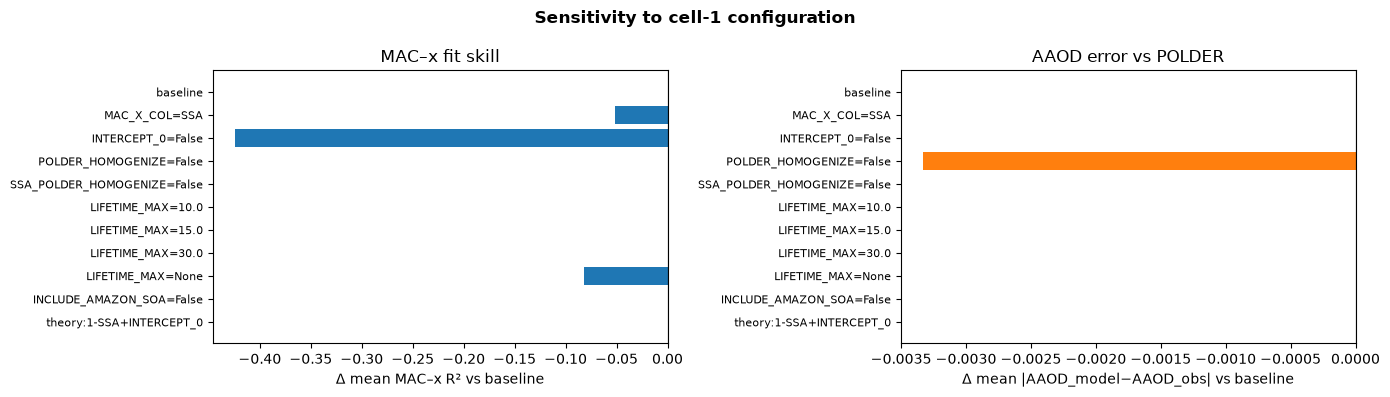

Saved: /scistor/guest/gbb083/AeroCom/tables/figure3_sensitivity_summary.csv


In [ ]:
print('\n--- Sensitivity analysis (cell-1 knobs vs R² / AAOD error) ---')

# Ensure homogenization detail dicts exist even if homogenization was skipped.
aaod_homog_details = globals().get('aaod_homog_details', {})
ssa_homog_details = globals().get('ssa_homog_details', {})

def _obs_mean(region, use_aaod_homog, use_ssa_homog):
    """Pick homogenized or raw POLDER means from cached homogenization details."""
    if use_aaod_homog and region in aaod_homog_details and not aaod_homog_details[region].get('skipped', False):
        aaod = float(aaod_homog_details[region]['homogenized'])
    elif region in aaod_homog_details:
        aaod = float(aaod_homog_details[region].get('obs_sampled', aaod_obs_by_region.get(region, np.nan)))
    else:
        aaod = float(aaod_obs_by_region.get(region, np.nan))
    if not use_aaod_homog and not polder_monthly[region].empty:
        aaod = float(polder_monthly[region]['AAOD_550'].mean())

    if use_ssa_homog and region in ssa_homog_details and not ssa_homog_details[region].get('skipped', False):
        ssa = float(ssa_homog_details[region]['homogenized'])
    elif region in ssa_homog_details:
        ssa = float(ssa_homog_details[region].get('obs_sampled', ssa_obs_by_region.get(region, np.nan)))
    else:
        ssa = float(ssa_obs_by_region.get(region, np.nan))
    if not use_ssa_homog and not polder_monthly[region].empty:
        ssa = float(polder_monthly[region]['SSA'].mean())
    return aaod, ssa


def _raw_lifetime(region, model):
    """Recompute unfiltered load/emi lifetime from cached seasonal aggregates."""
    load = model_seasonal[region].get('load_BC_OA', {}).get(model)
    emi = model_seasonal[region].get('emi_BC_OA', {}).get(model)
    if load is None or emi is None:
        return np.nan
    try:
        return float(load) / (float(emi) * 3600 * 24)
    except Exception:
        return np.nan


def _fit_mac_x(sub, x_col, intercept_0):
    sub = sub.dropna(subset=['MAC', x_col])
    if len(sub) < 3:
        return None
    x = sub[x_col].values
    y = sub['MAC'].values
    if intercept_0:
        F = np.nansum(x * y) / np.nansum(x ** 2)
        b = 0.0
        residuals = y - F * x
        r2 = 1 - np.nansum(residuals ** 2) / np.nansum(y ** 2)
    else:
        X = np.column_stack([x, np.ones(len(x))])
        coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        F, b = float(coeffs[0]), float(coeffs[1])
        y_pred = F * x + b
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return {'F': F, 'b': b, 'r2': float(r2), 'n': len(sub)}


def _build_reg_rows(lifetime_max, lifetime_min, amazon_soa):
    """Build regression rows with optional lifetime filter and Amazon SOA toggle."""
    rows = []
    f = AMAZON_SOA_FRACTION
    for region in SOURCE_REGIONS:
        for model in models:
            ssa = model_seasonal[region]['SSA'].get(model)
            mac = model_seasonal[region]['MAC'].get(model)
            ae = model_seasonal[region]['AE'].get(model)
            precip = model_seasonal[region]['precip'].get(model)
            if not all(v is not None for v in [ssa, mac, ae, precip]):
                continue
            # Lifetime: recompute from load/emi; for amazon optionally undo/redo SOA
            lt = _raw_lifetime(region, model)
            if region == 'amazon' and not amazon_soa:
                # Approximate undoing SOA: emi_BC_OA_no_soa = emibc + emioa (POA only)
                emibc = model_seasonal[region].get('emibc', {}).get(model)
                emioa = model_seasonal[region].get('emioa', {}).get(model)
                load = model_seasonal[region].get('load_BC_OA', {}).get(model)
                if emibc is not None and emioa is not None and load is not None:
                    try:
                        emi_no_soa = float(emibc) + float(emioa)
                        lt = float(load) / (emi_no_soa * 3600 * 24)
                    except Exception:
                        pass
            if not np.isfinite(lt):
                continue
            if lifetime_max is not None and lt > lifetime_max:
                continue
            if lifetime_min is not None and lt < lifetime_min:
                continue
            ssa_f = float(ssa)
            rows.append({
                'region': region, 'model': model,
                'SSA': ssa_f, '1-SSA': 1.0 - ssa_f, 'MAC': float(mac),
                'AE': float(ae), 'precip': float(precip),
                'lifetime': lt, 'inv_lifetime': 1.0 / lt,
            })
    return pd.DataFrame(rows)


def _mean_aaod_abs_error(region, aaod_obs):
    """Mean |AAOD_model - AAOD_obs| over models with abs550aer seasonal mean."""
    aaod_models = model_seasonal[region].get('abs550aer', {})
    errs = []
    for m, v in aaod_models.items():
        if v is None or not np.isfinite(float(v)) or not np.isfinite(aaod_obs):
            continue
        errs.append(abs(float(v) - aaod_obs))
    return float(np.mean(errs)) if errs else np.nan, len(errs)


# Baseline config (current cell-1 values)
baseline = {
    'MAC_X_COL': MAC_X_COL,
    'INTERCEPT_0': INTERCEPT_0,
    'POLDER_HOMOGENIZE': POLDER_HOMOGENIZE,
    'SSA_POLDER_HOMOGENIZE': SSA_POLDER_HOMOGENIZE,
    'POST_AGG_LIFETIME_MAX_DAYS': POST_AGG_LIFETIME_MAX_DAYS,
    'INCLUDE_AMAZON_SOA': INCLUDE_AMAZON_SOA,
}

# One-at-a-time variants
variants = [('baseline', dict(baseline))]
for xcol in ('SSA', '1-SSA'):
    if xcol != baseline['MAC_X_COL']:
        variants.append((f'MAC_X_COL={xcol}', {**baseline, 'MAC_X_COL': xcol}))
for ic0 in (False, True):
    if ic0 != baseline['INTERCEPT_0']:
        variants.append((f'INTERCEPT_0={ic0}', {**baseline, 'INTERCEPT_0': ic0}))
for ph in (False, True):
    if ph != baseline['POLDER_HOMOGENIZE']:
        variants.append((f'POLDER_HOMOGENIZE={ph}', {**baseline, 'POLDER_HOMOGENIZE': ph}))
for sh in (False, True):
    if sh != baseline['SSA_POLDER_HOMOGENIZE']:
        variants.append((f'SSA_POLDER_HOMOGENIZE={sh}', {**baseline, 'SSA_POLDER_HOMOGENIZE': sh}))
for ltmax in (10.0, 15.0, 30.0, None):
    if ltmax != baseline['POST_AGG_LIFETIME_MAX_DAYS']:
        label = f'LIFETIME_MAX={ltmax}' if ltmax is not None else 'LIFETIME_MAX=None'
        variants.append((label, {**baseline, 'POST_AGG_LIFETIME_MAX_DAYS': ltmax}))
if INCLUDE_AMAZON_SOA:
    variants.append(('INCLUDE_AMAZON_SOA=False', {**baseline, 'INCLUDE_AMAZON_SOA': False}))

# Also evaluate theory-preferred combo
variants.append((
    'theory:1-SSA+INTERCEPT_0',
    {**baseline, 'MAC_X_COL': '1-SSA', 'INTERCEPT_0': True},
))

sens_rows = []
for label, cfg in variants:
    rdf = _build_reg_rows(
        cfg['POST_AGG_LIFETIME_MAX_DAYS'],
        POST_AGG_LIFETIME_MIN_DAYS,
        cfg['INCLUDE_AMAZON_SOA'],
    )
    for region in SOURCE_REGIONS:
        fit = _fit_mac_x(rdf[rdf['region'] == region], cfg['MAC_X_COL'], cfg['INTERCEPT_0'])
        aaod_obs, ssa_obs = _obs_mean(region, cfg['POLDER_HOMOGENIZE'], cfg['SSA_POLDER_HOMOGENIZE'])
        mae, n_err = _mean_aaod_abs_error(region, aaod_obs)
        mac_c = np.nan
        if fit is not None and np.isfinite(ssa_obs):
            x_obs = (1.0 - ssa_obs) if cfg['MAC_X_COL'] == '1-SSA' else ssa_obs
            mac_c = fit['F'] * x_obs + fit['b']
        sens_rows.append({
            'config': label,
            'region': region,
            'MAC_X_COL': cfg['MAC_X_COL'],
            'INTERCEPT_0': cfg['INTERCEPT_0'],
            'POLDER_HOMOGENIZE': cfg['POLDER_HOMOGENIZE'],
            'SSA_POLDER_HOMOGENIZE': cfg['SSA_POLDER_HOMOGENIZE'],
            'LIFETIME_MAX': cfg['POST_AGG_LIFETIME_MAX_DAYS'],
            'INCLUDE_AMAZON_SOA': cfg['INCLUDE_AMAZON_SOA'],
            'mac_r2': fit['r2'] if fit else np.nan,
            'mac_n': fit['n'] if fit else 0,
            'mac_F': fit['F'] if fit else np.nan,
            'mac_b': fit['b'] if fit else np.nan,
            'MAC_c': mac_c,
            'AAOD_obs': aaod_obs,
            'AAOD_MAE': mae,
            'n_aaod_models': n_err,
        })

sens_df = pd.DataFrame(sens_rows)
sens_summary = (
    sens_df.groupby('config', sort=False)
    .agg(
        mean_mac_r2=('mac_r2', 'mean'),
        mean_AAOD_MAE=('AAOD_MAE', 'mean'),
        mean_mac_n=('mac_n', 'mean'),
    )
    .reset_index()
)
base_r2 = float(sens_summary.loc[sens_summary['config'] == 'baseline', 'mean_mac_r2'].iloc[0])
base_mae = float(sens_summary.loc[sens_summary['config'] == 'baseline', 'mean_AAOD_MAE'].iloc[0])
sens_summary['delta_mac_r2'] = sens_summary['mean_mac_r2'] - base_r2
sens_summary['delta_AAOD_MAE'] = sens_summary['mean_AAOD_MAE'] - base_mae

print('\nSensitivity summary (mean over SOURCE_REGIONS):')
print(sens_summary.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

# Prefer configs that raise R² without raising AAOD MAE
improved = sens_summary[
    (sens_summary['config'] != 'baseline')
    & (sens_summary['delta_mac_r2'] > 0)
    & (sens_summary['delta_AAOD_MAE'] <= 0)
].sort_values('delta_mac_r2', ascending=False)
print('\nConfigs that improve mean MAC–x R² without increasing AAOD MAE vs baseline:')
if improved.empty:
    print('  (none)')
else:
    print(improved.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

# Compact plot: ΔR² and ΔMAE
fig, axes = plt.subplots(1, 2, figsize=(14, max(4, 0.35 * len(sens_summary))))
order = sens_summary['config'].tolist()
ypos = np.arange(len(order))
axes[0].barh(ypos, sens_summary['delta_mac_r2'], color='#1f77b4')
axes[0].axvline(0, color='k', lw=0.8)
axes[0].set_yticks(ypos)
axes[0].set_yticklabels(order, fontsize=8)
axes[0].set_xlabel('Δ mean MAC–x R² vs baseline')
axes[0].set_title('MAC–x fit skill')
axes[0].invert_yaxis()
axes[1].barh(ypos, sens_summary['delta_AAOD_MAE'], color='#ff7f0e')
axes[1].axvline(0, color='k', lw=0.8)
axes[1].set_yticks(ypos)
axes[1].set_yticklabels(order, fontsize=8)
axes[1].set_xlabel('Δ mean |AAOD_model−AAOD_obs| vs baseline')
axes[1].set_title('AAOD error vs POLDER')
axes[1].invert_yaxis()
plt.suptitle('Sensitivity to cell-1 configuration', fontweight='bold')
plt.tight_layout()
sens_fig = FIGURE_DIR / 'figure3_sensitivity_summary.png'
sens_csv = TABLE_DIR / 'figure3_sensitivity_summary.csv'
if SAVE_FIGURE:
    plt.savefig(sens_fig, dpi=200, bbox_inches='tight')
    print(f'Saved: {sens_fig}')
    plt.close(fig)
else:
    plt.show()
sens_df.to_csv(sens_csv, index=False)
sens_summary.to_csv(TABLE_DIR / 'figure3_sensitivity_summary_mean.csv', index=False)
print(f'Saved: {sens_csv}')


**Figure caption — Sensitivity to cell-1 configuration knobs**

Bar/line summary of one-at-a-time perturbations of notebook flags (e.g. `MAC_X_COL`, `INTERCEPT_0`, homogenization on/off, `POST_AGG_LIFETIME_MAX_DAYS`, Amazon SOA toggle) against **cached** seasonal means—no NetCDF reload.

**Left:** MAC–x regression skill (R², n). **Right:** mean absolute AAOD error vs POLDER over `SOURCE_REGIONS`.

**Data:** Reuses `model_seasonal`, POLDER/GPCP means, and homogenization detail caches from earlier cells; each variant rebuilds constrained estimates and optional decomp metrics. Artifacts: `figure3_sensitivity_summary.csv` / `.png`.


## Save CSV outputs


In [ ]:
out_csv = TABLE_DIR / 'figure3_regression_data.csv'
reg_df.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')

out_csv = TABLE_DIR / 'figure3_constrained_estimates.csv'
constrained_df.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')

out_csv = TABLE_DIR / 'figure3_error_decomposition.csv'
decomp_df.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')

if not outflow_pred_df.empty:
    out_csv = TABLE_DIR / 'figure3_outflow_meta_predictions.csv'
    outflow_pred_df.to_csv(out_csv, index=False)
    print(f'Saved: {out_csv}')

out_csv = TABLE_DIR / 'figure3_model_region_data.csv'
model_region_rows = []
for region in SOURCE_REGIONS + [OUTFLOW_REGION]:
    for model in models:
        row = {'region': region, 'model': model}
        for var in ['MEC', 'MAC', 'SSA', 'AE', 'lifetime_BC_OA', 'precip', 'emi_BC_OA', 'abs550aer']:
            val = model_seasonal[region].get(var, {}).get(model)
            row[var] = float(val) if val is not None and np.isfinite(float(val)) else np.nan
        model_region_rows.append(row)
pd.DataFrame(model_region_rows).to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')

print('\n=== Final configuration diagnostics ===')
print(f'MAC_X_COL={MAC_X_COL}, INTERCEPT_0={INTERCEPT_0}, '
      f'POLDER_HOMOGENIZE={POLDER_HOMOGENIZE}, '
      f'INCLUDE_AMAZON_SOA={INCLUDE_AMAZON_SOA} (f={AMAZON_SOA_FRACTION})')
print(f'Brown SSA–rBC: SSA = {BROWN_SSA_INTERCEPT}{BROWN_SSA_SLOPE:+.3f}*rBC (r^2={BROWN_SSA_R2})')
if 'constrained_rbc_df' in globals() and not constrained_rbc_df.empty:
    print('\nBrown-constrained ambient rBC / SSA:')
    print(constrained_rbc_df[['region', 'SSA_obs', 'rBC_C', 'rBC_model_mean', 'SSA_C_Brown']].to_string(index=False))
print('\nMean source-region decomposition:')
print(mean_decomp)
print('\nDone.')


Saved: /scistor/guest/gbb083/AeroCom/tables/figure3_regression_data.csv
Saved: /scistor/guest/gbb083/AeroCom/tables/figure3_constrained_estimates.csv
Saved: /scistor/guest/gbb083/AeroCom/tables/figure3_error_decomposition.csv
Saved: /scistor/guest/gbb083/AeroCom/tables/figure3_outflow_meta_predictions.csv
Saved: /scistor/guest/gbb083/AeroCom/tables/figure3_model_region_data.csv

=== Final configuration diagnostics ===
MAC_X_COL=1-SSA, INTERCEPT_0=True, POLDER_HOMOGENIZE=True, INCLUDE_AMAZON_SOA=True (f=0.52)
Brown SSA–rBC: SSA = 0.969-0.779*rBC (r^2=0.68)

Brown-constrained ambient rBC / SSA:
            region  SSA_obs    rBC_C  rBC_model_mean  SSA_C_Brown
            africa 0.867537 0.130248        0.066906     0.916880
            amazon 0.921155 0.061419        0.052531     0.928079
    boreal_na_west 0.890457 0.100825        0.032777     0.943467
indonesia_peatland 0.887013 0.105246        0.075364     0.910291

Mean source-region decomposition:
                        pct_E    pc